# preparation

In [3]:
import sys
sys.path.append('..')

import importlib

from util import config
from util.data_loader import DataLoader
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)

import numpy as np
import pandas as pd
from tqdm import tqdm

def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'dist_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def get_interaction_with_trigger_df(df, r, ti=1):
    '''
    Find each time the mouse enter within radius `r` to trigger `ti` (trigger index), and find the enter, 
    exit time, and durations of each visit
    '''
    inside = df[f'dist_to_trigger_{ti}'] <= r
    # Sometime animal started at the trigger zone by mistake. Set the first inside to False
    inside[0] = False
    inside = np.append(inside, 0)
    inside_diff = np.diff(inside.astype('int16'))
    enter_idx = np.where(inside_diff == 1)[0]
    exit_idx = np.where(inside_diff == -1)[0]

    assert enter_idx.shape == exit_idx.shape

    t_enter = df['t'].values[enter_idx]
    t_exit = df['t'].values[exit_idx]
    duration = t_exit - t_enter
    df_trigger_time = {
        't_enter': t_enter, # Time of entering within r distance to the trigger
        't_exit': t_exit, # Time of leaving within r distance to the trigger
        'duration': duration # Duration animal spent within distance r to the trigger
    }
    return pd.DataFrame(df_trigger_time)

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

import numpy as np
import pandas as pd

def add_distance_travelled(position):
    """
    Adds per-step distance and cumulative distance to a position dataframe.

    Requires columns: ['t','x','y'].
    Returns a COPY with new columns:
      - dx, dy
      - step_dist: distance between consecutive samples
      - cum_dist: cumulative distance from start
    """
    if position is None or len(position) == 0:
        return None

    pos = position.copy()

    # differences between consecutive samples
    dx = np.diff(pos['x'].values, prepend=pos['x'].values[0])
    dy = np.diff(pos['y'].values, prepend=pos['y'].values[0])

    pos['dx'] = dx
    pos['dy'] = dy

    # step distance (same units as x,y)
    pos['step_dist'] = np.sqrt(dx**2 + dy**2)

    # cumulative distance
    pos['cum_dist'] = np.cumsum(pos['step_dist'])

    return pos


def add_speed(position):
    """
    Adds instantaneous speed to the position DataFrame.
    Assumes:
      - x, y in cm
      - t in ms
    Speed returned in cm/s
    """
    pos = position.copy()

    dx = np.diff(pos['x'].values)
    dy = np.diff(pos['y'].values)
    dt = np.diff(pos['t'].values) / 1000.0  # ms → s

    dist = np.sqrt(dx**2 + dy**2)

    speed = np.zeros(len(pos))
    valid = dt > 0
    speed[1:][valid] = dist[valid] / dt[valid]

    pos['speed'] = speed
    return pos

# colour coding
def get_genotype_color(genotype=None):
    # Create a dictionary to match the animal genotype with the colour.
    genotype_color = {}
    genotype_color['ChR2'] = '#F44636ff'
    genotype_color['eYFP_ChR2'] =  '#5ba0d8ff'
    genotype_color['ChR2_short'] = '#FFA623ff'
    genotype_color['CA1'] = '#63D15Aff'
    genotype_color['CA3'] = '#7b62c5ff'
    genotype_color['NAc'] = '#FF9BD6ff'
    genotype_color['ArchT'] = "#BF5697"
    genotype_color['eYFP_ArchT'] = "#5ba0d8ff"
    genotype_color['CA1_control'] = "#62d70fff"
    genotype_color['Control'] = '#5ba0d8ff'
    genotype_color['NAc_control'] = "#00C2B5"
    genotype_color['WT'] = 'grey'
    genotype_color['short_1'] = "#ff6600ff"
    genotype_color['short_2'] = "#ffdd00ff"
    genotype_color['F231A'] = '#F44636ff'
    genotype_color['F231A_wt'] =  '#5ba0d8ff'


    if genotype == None:
        return genotype_color
    else:
        return genotype_color[genotype]

# other good colours i could use
'#00877D'
'#A4B2FF'
'#FF9BD6'
'#A66A5C'
'#1F2A63'
"#CA4E9B"
"#CD75AB"
"#f468f1ff"
# significance test
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."


In [4]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[45])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

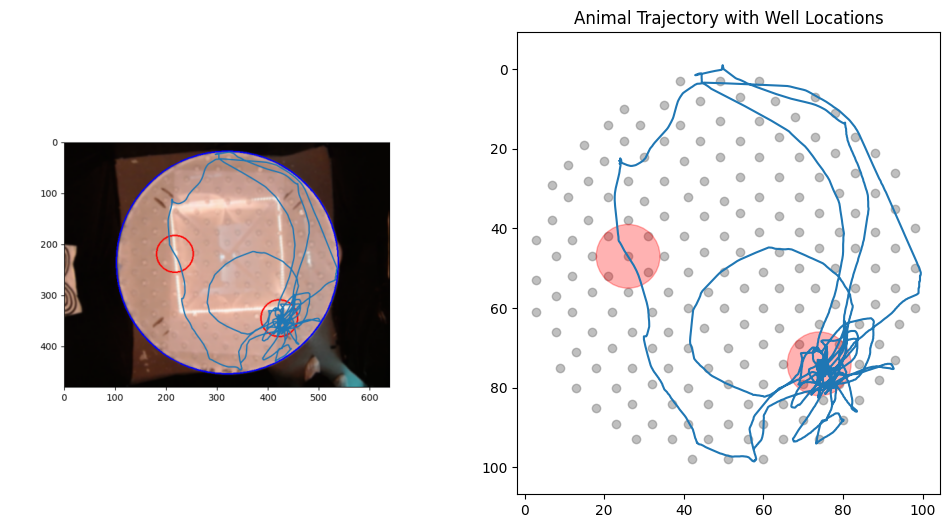

In [5]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))

axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)
# Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')

In [6]:
triggerLoc

,well_row,well_col,x,y
0,J,3,26,47
1,Q,8,74,74


In [7]:
position_ = add_dist_to_trigger(position, triggerLoc)
trigger_num = len(triggerLoc)
dfs = []
for i in range(trigger_num):
    df_trigger_interaction = get_interaction_with_trigger_df(position_, 8, ti = i+1)
    df_trigger_interaction["trigger_id"] = i + 1
    dfs.append(df_trigger_interaction)
df_all_triggers = pd.concat(dfs, ignore_index=True)
df_all_triggers

,t_enter,t_exit,duration,trigger_id
0,160470,161746,1276,1
1,2017,7183,5166,2
2,8962,14420,5458,2
3,18488,23541,5053,2
4,23672,25425,1753,2
5,28682,31495,2813,2
6,33670,60280,26610,2
7,63489,80872,17383,2
8,82751,86006,3255,2
9,87337,89477,2140,2


In [8]:
metadata

,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,gender,genotype,test_order,remapping,short_duration,LFP,animal_note
0,1,A,20241205,1,1,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
1,1,A,20241205,1,2,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
2,1,A,20241205,1,3,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
3,1,A,20241205,1,4,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
4,1,A,20241205,1,5,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7251,97,F8,20260503,8,6,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7252,97,F8,20260503,8,7,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7253,97,F8,20260503,8,8,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7254,97,F8,20260504,9,1,T,1,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN


# number of crossings

In [9]:
# COMPUTE NUMBER OF CROSSINGS
#
# Outputs:
#   metadata
#       Adds:
#           n_crossings
#           = number of visits/crossings into any trigger zone in that trial
#
#   df_cross
#       Long-format per-trigger crossing table:
#           trial_id
#           trigger_id
#           n_crossings_trig
#
#   meta_cross
#       df_cross merged back with metadata, so each row is one
#       trial x trigger.
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm


# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------
metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)


# ------------------------------------------------------------
# Options
# ------------------------------------------------------------
R_TRIGGER = 10 / 1.2


# ------------------------------------------------------------
# Output columns
# ------------------------------------------------------------
metadata['n_crossings'] = np.nan

cross_rows = []

# ------------------------------------------------------------
# Main loop
# ------------------------------------------------------------
for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'n_crossings'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    # Build visit episodes for each trigger
    dfs = []

    for i in range(len(triggerLoc)):
        df_trigger_interaction = get_interaction_with_trigger_df(
            position_,
            R_TRIGGER,
            ti=i + 1
        )

        if len(df_trigger_interaction) == 0:
            continue

        df_trigger_interaction = df_trigger_interaction.copy()
        df_trigger_interaction['trigger_id'] = i + 1
        dfs.append(df_trigger_interaction)

    # --------------------------------------------------------
    # Any-trigger crossings
    # Same logic as your original code:
    # number of crossings = number of visits to any trigger.
    # --------------------------------------------------------
    if len(dfs) == 0:
        df_all_triggers = None
        n_crossings = 0
    else:
        df_all_triggers = pd.concat(dfs, ignore_index=True)
        n_crossings = len(df_all_triggers)

    metadata.at[trial_id, 'n_crossings'] = n_crossings

    # --------------------------------------------------------
    # Per-trigger crossings
    # Same crossing logic, split by trigger_id.
    # --------------------------------------------------------
    for trig_id in range(1, len(triggerLoc) + 1):
        if df_all_triggers is None:
            n_trig = 0
        else:
            df_t = df_all_triggers[df_all_triggers['trigger_id'] == trig_id]
            n_trig = len(df_t)

        cross_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,
            'n_crossings_trig': n_trig,
        })


# ------------------------------------------------------------
# Long-format per-trigger table + metadata
# ------------------------------------------------------------
df_cross = pd.DataFrame(
    cross_rows,
    columns=['trial_id', 'trigger_id', 'n_crossings_trig']
)

meta_cross = df_cross.merge(
    metadata,
    left_on='trial_id',
    right_index=True,
    how='left'
)


# ------------------------------------------------------------
# Quick check
# ------------------------------------------------------------
print("\nCrossing computation complete.")
print("metadata rows:", len(metadata))
print("meta_cross rows:", len(meta_cross))

if len(metadata) > 0:
    print("\nmetadata crossing columns:")
    cols_to_show = ['sub']
    if 'id' in metadata.columns:
        cols_to_show.append('id')
    cols_to_show += ['trial_type', 'trial_type_day', 'n_crossings']

    cols_to_show = [c for c in cols_to_show if c in metadata.columns]
    print(metadata[cols_to_show].head())

if len(meta_cross) > 0:
    print("\nper-trigger crossing table:")
    cols_to_show = ['sub']
    if 'id' in meta_cross.columns:
        cols_to_show.append('id')
    cols_to_show += [
        'trial_type',
        'trial_type_day',
        'trigger_id',
        'n_crossings_trig',
    ]

    cols_to_show = [c for c in cols_to_show if c in meta_cross.columns]
    print(meta_cross[cols_to_show].head())


 11%|█         | 707/6611 [00:07<00:53, 110.15it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 18%|█▊        | 1186/6611 [00:11<00:48, 111.96it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 39%|███▉      | 2607/6611 [00:23<00:23, 169.45it/s]

...

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-077_id-C7/ses-01_date-20260326/behav/sub-077_ses-01_trial-06_data-position.csv' does not exist.


 98%|█████████▊| 6482/6611 [00:59<00:01, 113.38it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-095_id-F6/ses-05_date-20260430/behav/sub-095_ses-05_trial-01_data-position.csv' does not exist.


100%|██████████| 6611/6611 [00:59<00:00, 110.18it/s]


Crossing computation complete.
metadata rows: 6611
meta_cross rows: 18641

metadata crossing columns:
   sub id trial_type  trial_type_day  n_crossings
0    1  A          H               1         36.0
1    1  A          H               1         24.0
2    1  A          H               1         28.0
3    1  A          H               1         31.0
4    1  A          H               1         26.0

per-trigger crossing table:
   sub id trial_type  trial_type_day  trigger_id  n_crossings_trig
0    1  A          H               1           1                 3
1    1  A          H               1           2                 3
2    1  A          H               1           3                 2
3    1  A          H               1           4                 1
4    1  A          H               1           5                10



Groups used for plotting/stats: ['ChR2', 'eYFP_ChR2']
Original genotypes loaded: ['ChR2', 'eYFP_ChR2']
Custom IDs loaded: []
Using column: n_crossings

Animals included:
  VTA (ChR2):
    animals in dataset: 13
    animals plotted:    13
    ids plotted:        ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  VTA control (eYFP_ChR2):
    animals in dataset: 5
    animals plotted:    5
    ids plotted:        ['E', 'EE', 'EF', 'F', 'G']
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_line_n_crossings_ChR2_vs_eYFP_ChR2.svg


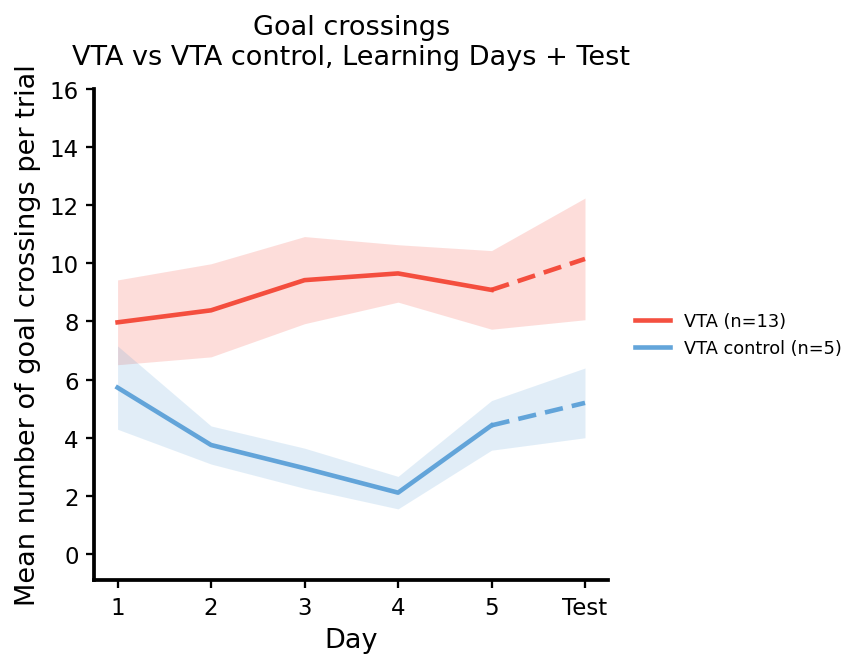


Boxplot: learning days 1-5 average
Metric: n_crossings
Animals included:
  VTA (ChR2): n = 13, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  VTA control (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']

Mann-Whitney U tests:
  VTA vs VTA control: n=13 vs 5, mean=8.904 vs 3.792, median=7.825 vs 3.950, U=59.0, rank-biserial=0.815, p=0.00677
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_boxplot_n_crossings_learning_days_1_to_5_mean_ChR2_vs_eYFP_ChR2.svg


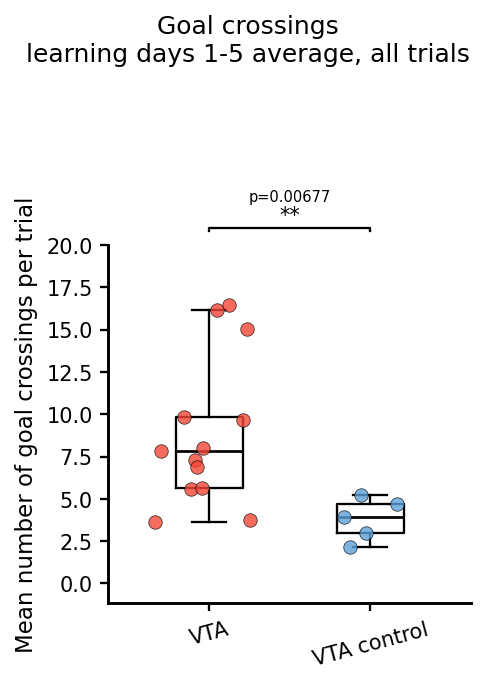


Boxplot: test day
Metric: n_crossings
Animals included:
  VTA (ChR2): n = 13, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  VTA control (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']

Mann-Whitney U tests:
  VTA vs VTA control: n=13 vs 5, mean=10.154 vs 5.200, median=9.000 vs 4.000, U=51.5, rank-biserial=0.585, p=0.06636
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_boxplot_n_crossings_test_day_ChR2_vs_eYFP_ChR2.svg


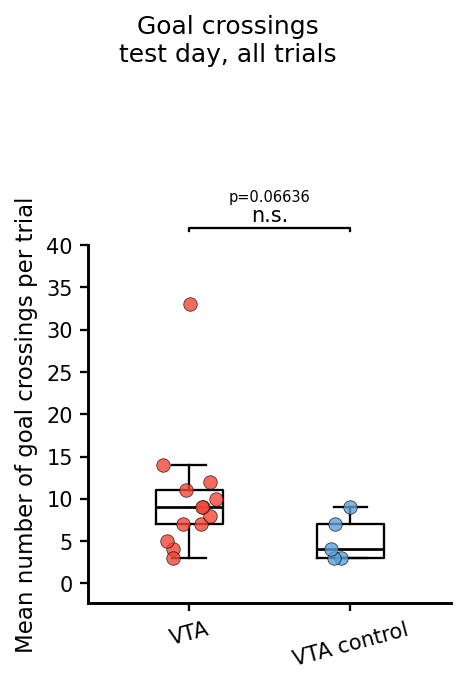


Within-day progress plot
Using column: n_crossings
Trial column used: inferred from sub/ses order
  VTA (ChR2): n = 13, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  VTA control (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_within_day_n_crossings_ChR2_vs_eYFP_ChR2.svg


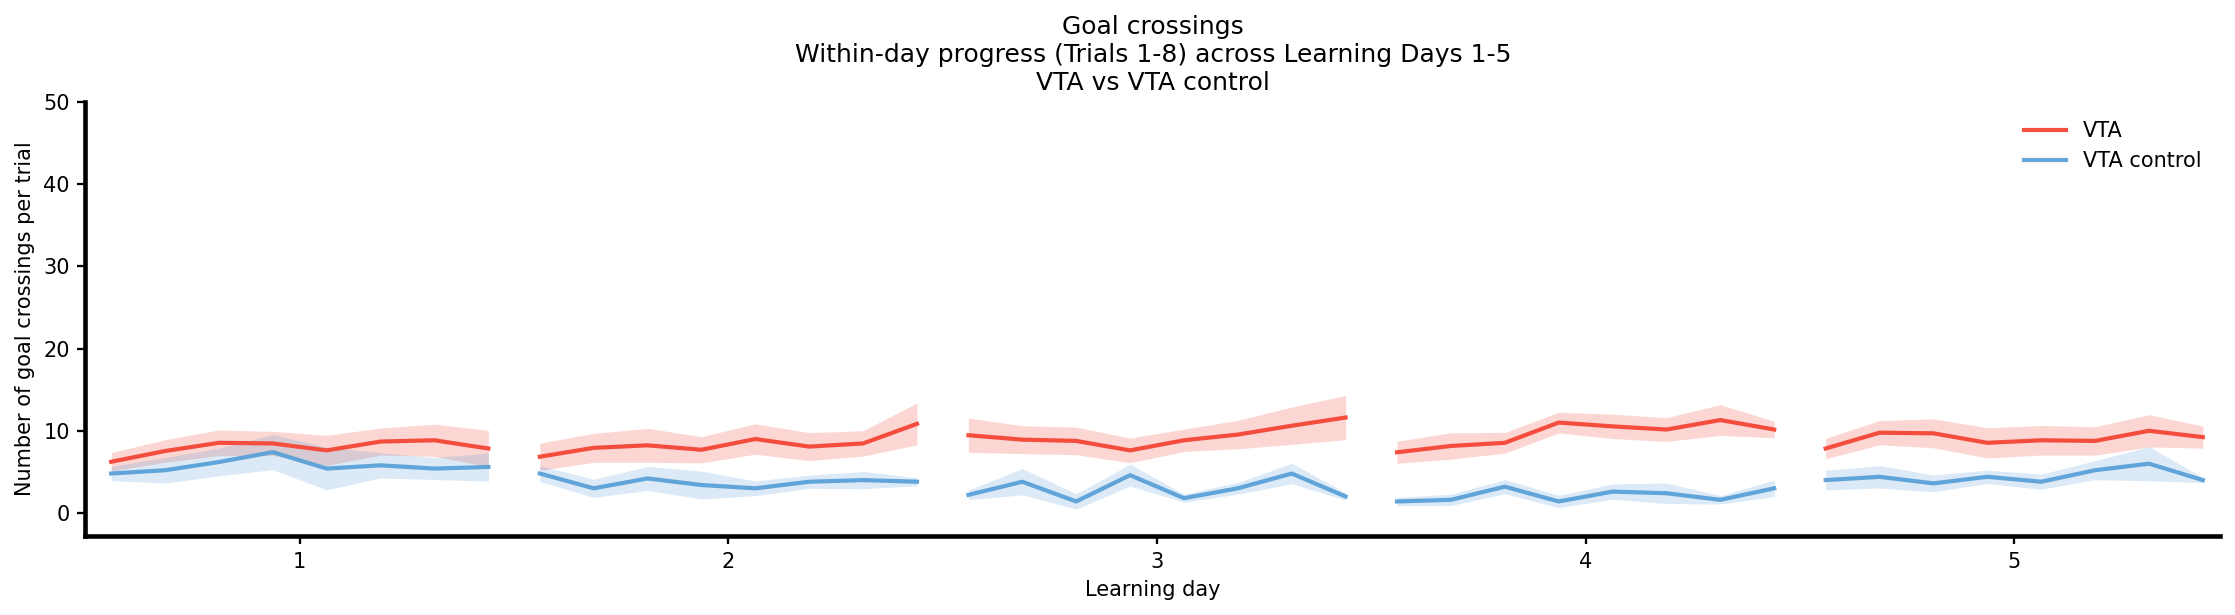


Groups used for plotting/stats: ['ChR2', 'ChR2_short', 'eYFP_ChR2']
Original genotypes loaded: ['ChR2', 'ChR2_short', 'eYFP_ChR2']
Custom IDs loaded: []
Using column: n_crossings

Animals included:
  VTA (ChR2):
    animals in dataset: 13
    animals plotted:    13
    ids plotted:        ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  VTA short (ChR2_short):
    animals in dataset: 8
    animals plotted:    8
    ids plotted:        ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  VTA control (eYFP_ChR2):
    animals in dataset: 5
    animals plotted:    5
    ids plotted:        ['E', 'EE', 'EF', 'F', 'G']
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_line_n_crossings_ChR2_vs_ChR2_short_vs_eYFP_ChR2.svg


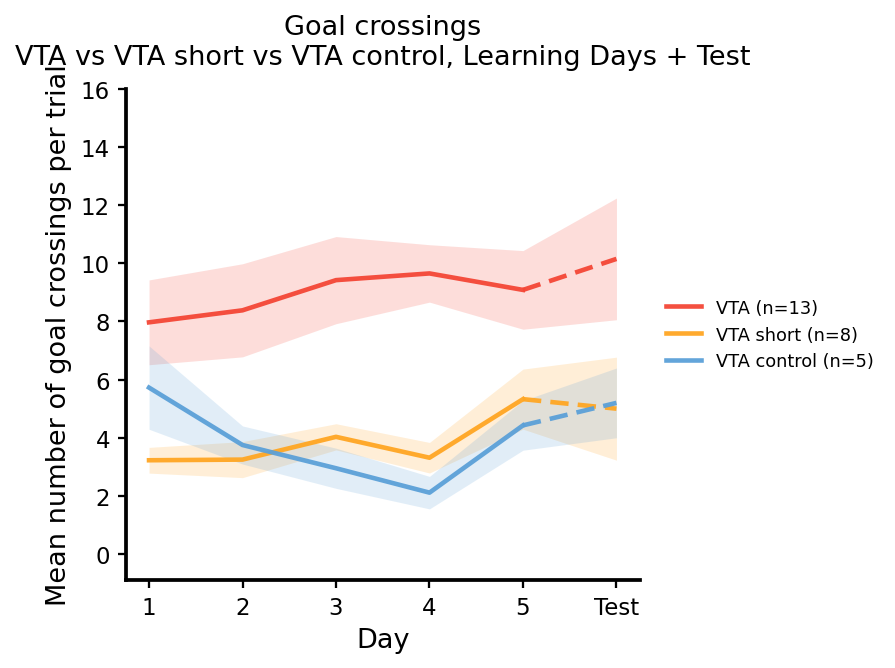


Boxplot: learning days 1-5 average
Metric: n_crossings
Animals included:
  VTA (ChR2): n = 13, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  VTA short (ChR2_short): n = 8, ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  VTA control (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']

Mann-Whitney U tests:
  VTA vs VTA short: n=13 vs 8, mean=8.904 vs 3.829, median=7.825 vs 3.668, U=97.0, rank-biserial=0.865, p=0.00044
  VTA vs VTA control: n=13 vs 5, mean=8.904 vs 3.792, median=7.825 vs 3.950, U=59.0, rank-biserial=0.815, p=0.00677
  VTA short vs VTA control: n=8 vs 5, mean=3.829 vs 3.792, median=3.668 vs 3.950, U=20.0, rank-biserial=0.000, p=1.00000
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_boxplot_n_crossings_learning_days_1_to_5_mean_ChR2_vs_ChR2_short_vs_eYFP_ChR2.svg


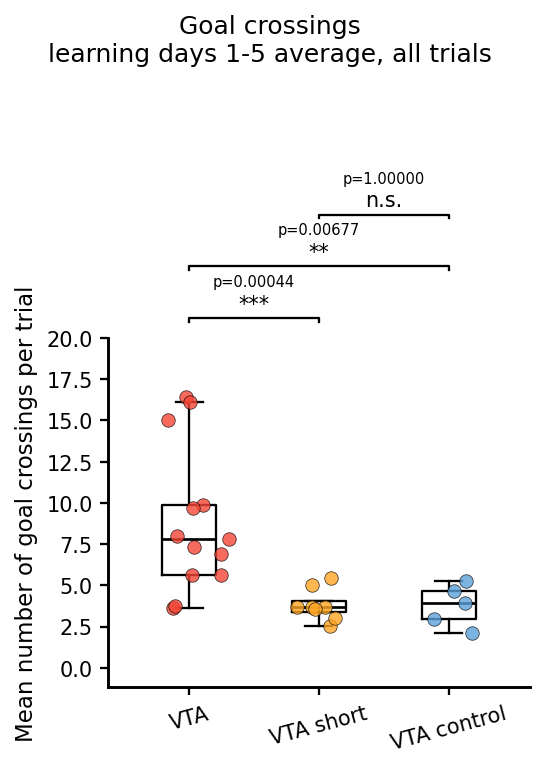


Boxplot: test day
Metric: n_crossings
Animals included:
  VTA (ChR2): n = 13, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  VTA short (ChR2_short): n = 8, ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  VTA control (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']

Mann-Whitney U tests:
  VTA vs VTA short: n=13 vs 8, mean=10.154 vs 5.000, median=9.000 vs 3.500, U=82.0, rank-biserial=0.577, p=0.03225
  VTA vs VTA control: n=13 vs 5, mean=10.154 vs 5.200, median=9.000 vs 4.000, U=51.5, rank-biserial=0.585, p=0.06636
  VTA short vs VTA control: n=8 vs 5, mean=5.000 vs 5.200, median=3.500 vs 4.000, U=15.5, rank-biserial=-0.225, p=0.55490
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_boxplot_n_crossings_test_day_ChR2_vs_ChR2_short_vs_eYFP_ChR2.svg


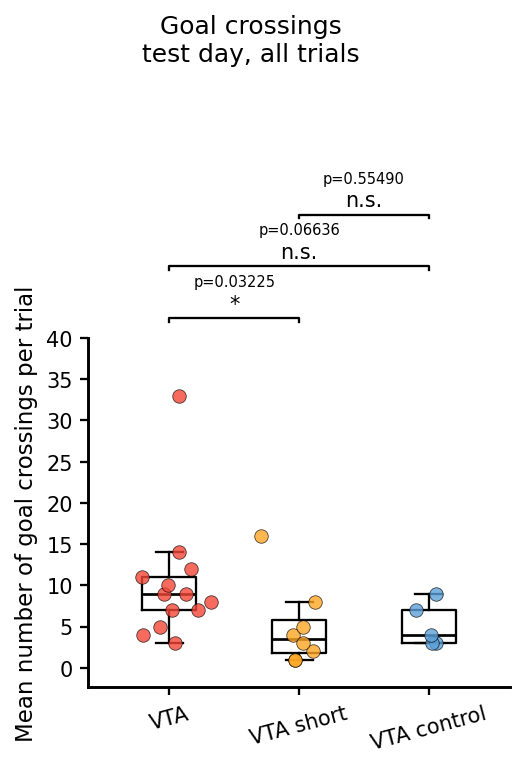


Within-day progress plot
Using column: n_crossings
Trial column used: inferred from sub/ses order
  VTA (ChR2): n = 13, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  VTA short (ChR2_short): n = 8, ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  VTA control (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_within_day_n_crossings_ChR2_vs_ChR2_short_vs_eYFP_ChR2.svg


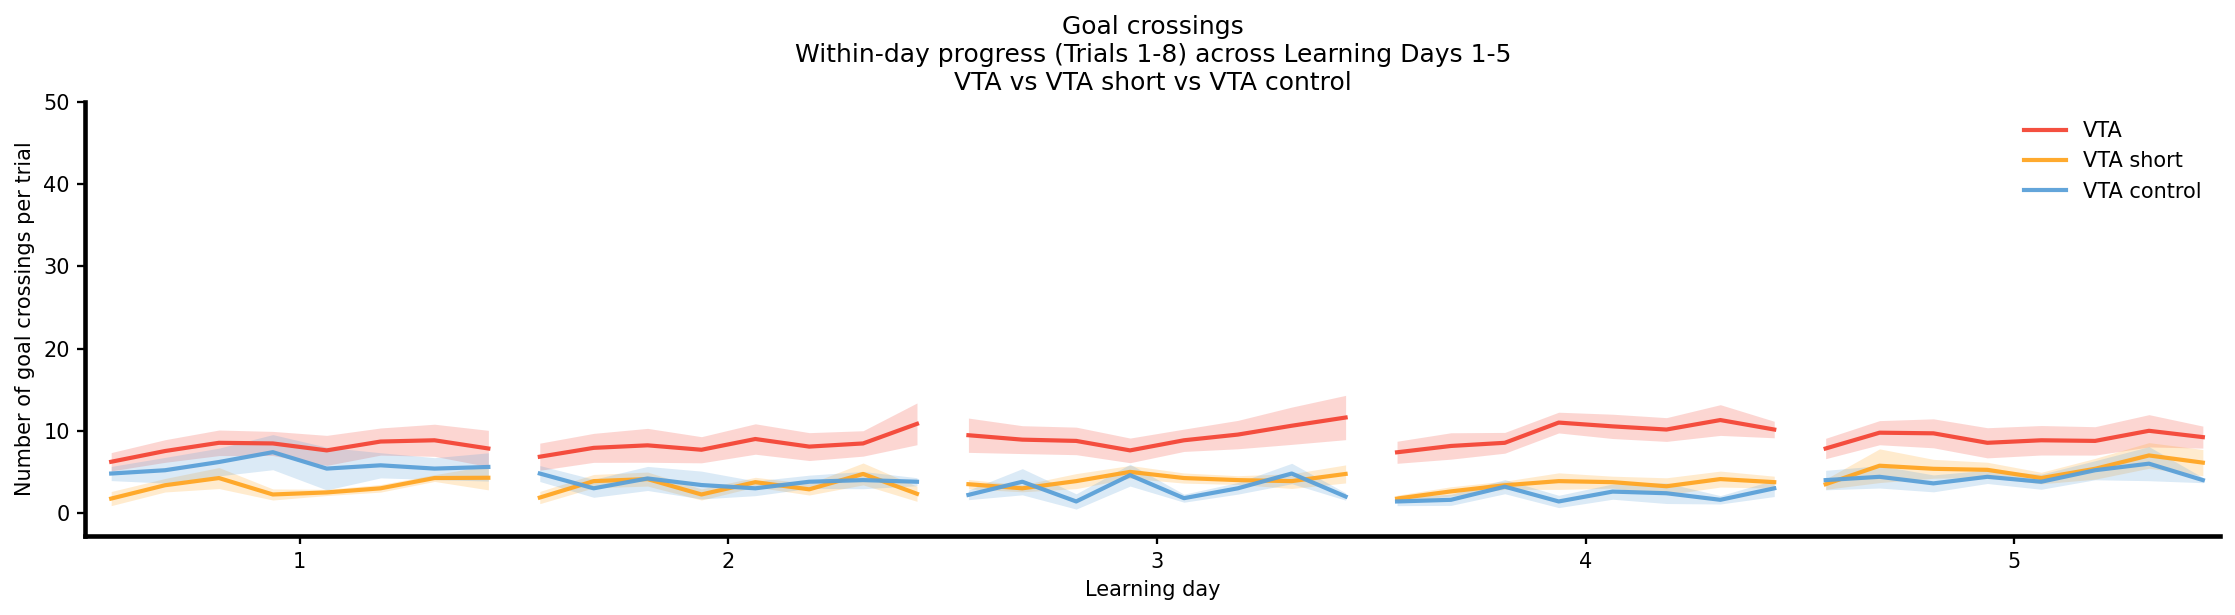


Groups used for plotting/stats: ['ChR2', 'NAc', 'Control']
Original genotypes loaded: ['CA1_control', 'ChR2', 'NAc', 'NAc_control']
Custom IDs loaded: []
Using column: n_crossings
Control pooled from: ['CA1_control', 'NAc_control']

Animals included:
  VTA (ChR2):
    animals in dataset: 13
    animals plotted:    13
    ids plotted:        ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  NAc (NAc):
    animals in dataset: 7
    animals plotted:    7
    ids plotted:        ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Control (Control):
    animals in dataset: 6
    animals plotted:    6
    ids plotted:        ['C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_line_n_crossings_ChR2_vs_NAc_vs_Control.svg


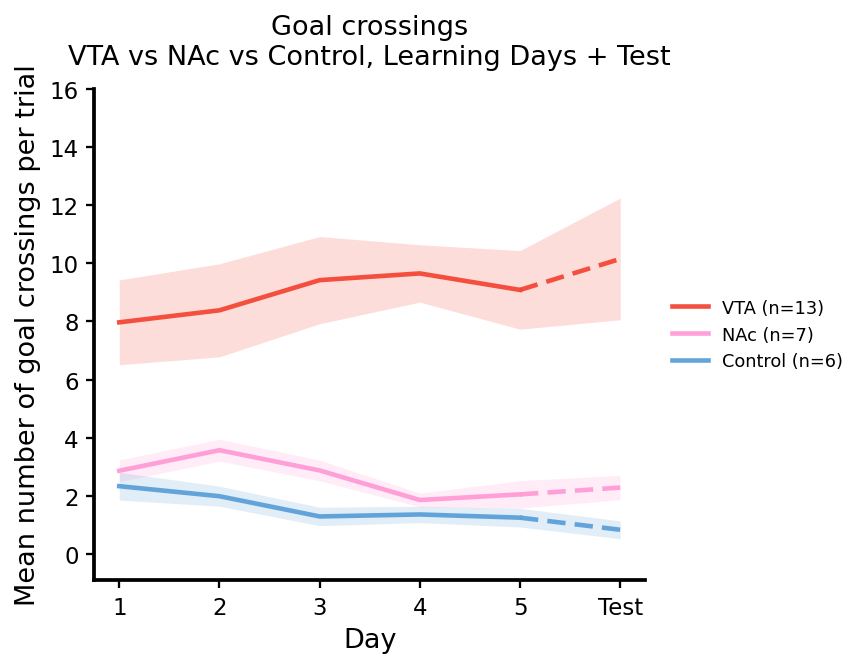


Boxplot: learning days 1-5 average
Metric: n_crossings
Animals included:
  VTA (ChR2): n = 13, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  NAc (NAc): n = 7, ids = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Control (Control): n = 6, ids = ['C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']

Mann-Whitney U tests:
  VTA vs NAc: n=13 vs 7, mean=8.904 vs 2.644, median=7.825 vs 2.300, U=89.0, rank-biserial=0.956, p=0.00010
  VTA vs Control: n=13 vs 6, mean=8.904 vs 1.645, median=7.825 vs 1.579, U=78.0, rank-biserial=1.000, p=0.00007
  NAc vs Control: n=7 vs 6, mean=2.644 vs 1.645, median=2.300 vs 1.579, U=37.5, rank-biserial=0.786, p=0.02209
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_boxplot_n_crossings_learning_days_1_to_5_mean_ChR2_vs_NAc_vs_Control.svg


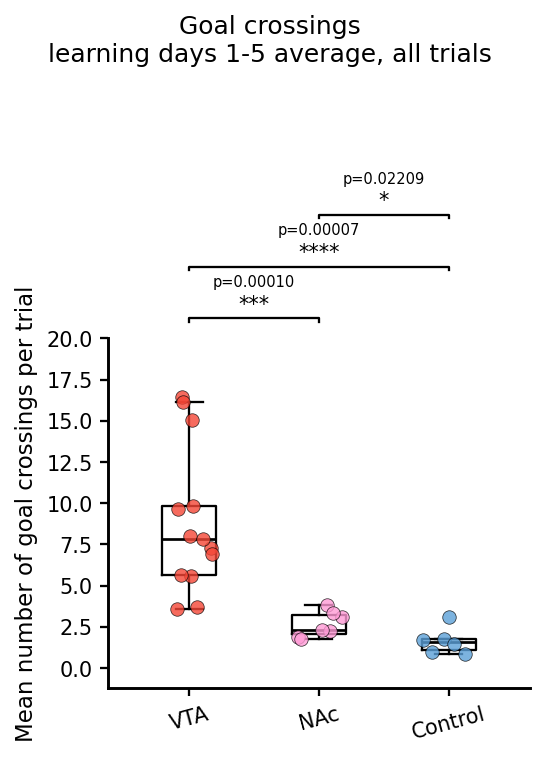


Boxplot: test day
Metric: n_crossings
Animals included:
  VTA (ChR2): n = 13, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  NAc (NAc): n = 7, ids = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Control (Control): n = 6, ids = ['C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']

Mann-Whitney U tests:
  VTA vs NAc: n=13 vs 7, mean=10.154 vs 2.286, median=9.000 vs 2.000, U=88.5, rank-biserial=0.945, p=0.00073
  VTA vs Control: n=13 vs 6, mean=10.154 vs 0.833, median=9.000 vs 1.000, U=78.0, rank-biserial=1.000, p=0.00071
  NAc vs Control: n=7 vs 6, mean=2.286 vs 0.833, median=2.000 vs 1.000, U=36.0, rank-biserial=0.714, p=0.03159
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_boxplot_n_crossings_test_day_ChR2_vs_NAc_vs_Control.svg


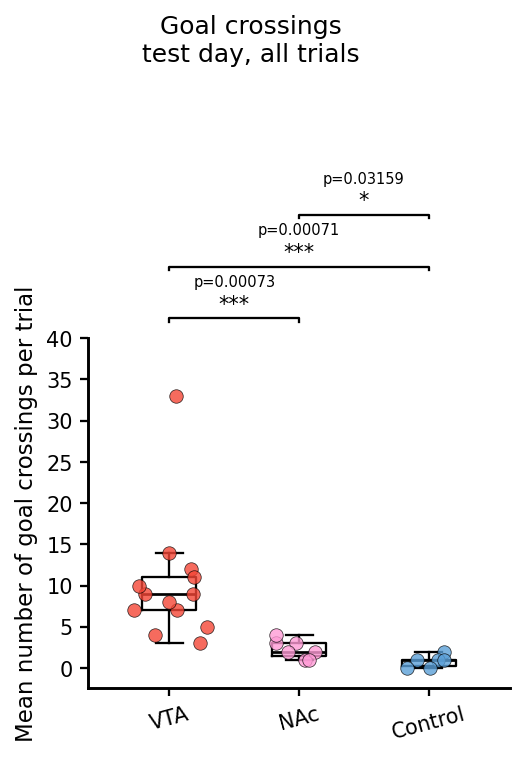


Within-day progress plot
Using column: n_crossings
Trial column used: inferred from sub/ses order
  VTA (ChR2): n = 13, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  NAc (NAc): n = 7, ids = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Control (Control): n = 6, ids = ['C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_within_day_n_crossings_ChR2_vs_NAc_vs_Control.svg


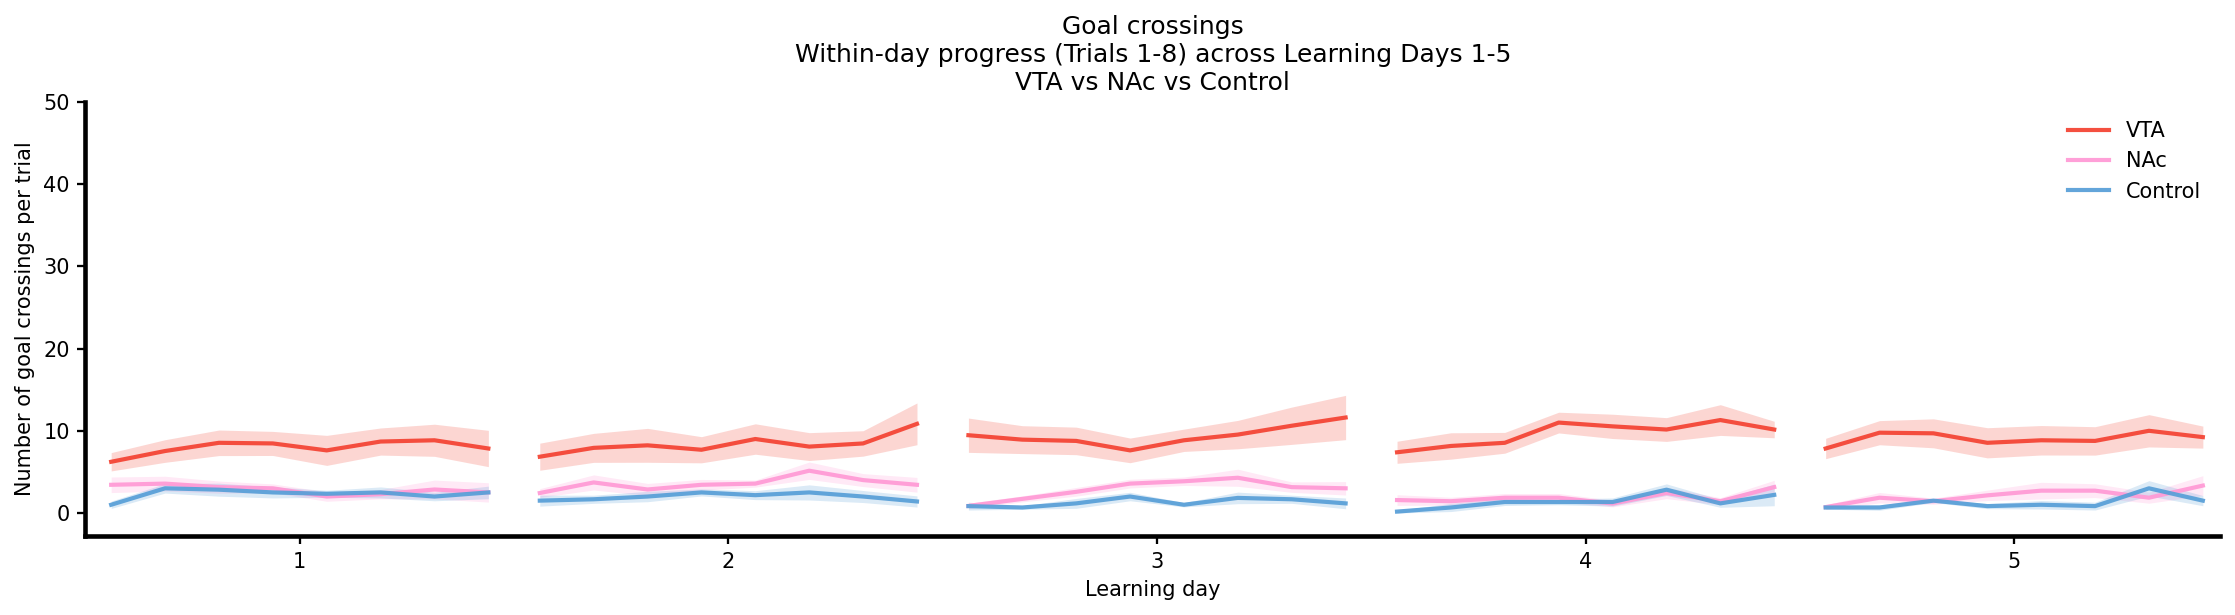


Groups used for plotting/stats: ['ChR2', 'CA1', 'CA3', 'Control']
Original genotypes loaded: ['CA1', 'CA1_control', 'CA3', 'ChR2', 'NAc_control']
Custom IDs loaded: []
Using column: n_crossings
Control pooled from: ['CA1_control', 'NAc_control']

Animals included:
  VTA (ChR2):
    animals in dataset: 13
    animals plotted:    13
    ids plotted:        ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  CA1 (CA1):
    animals in dataset: 7
    animals plotted:    7
    ids plotted:        ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3):
    animals in dataset: 7
    animals plotted:    7
    ids plotted:        ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
  Control (Control):
    animals in dataset: 6
    animals plotted:    6
    ids plotted:        ['C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossing

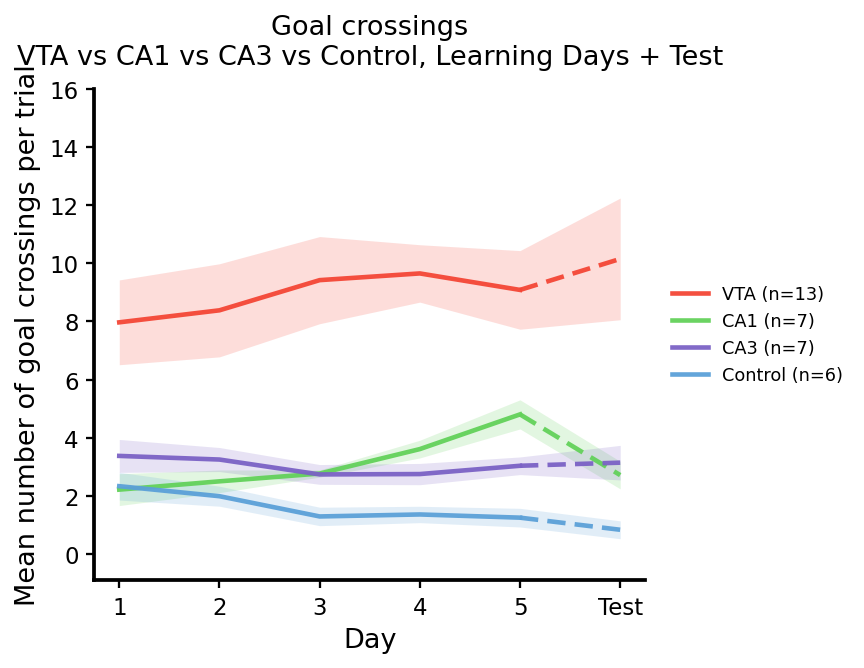


Boxplot: learning days 1-5 average
Metric: n_crossings
Animals included:
  VTA (ChR2): n = 13, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  CA1 (CA1): n = 7, ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3): n = 7, ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
  Control (Control): n = 6, ids = ['C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']

Mann-Whitney U tests:
  VTA vs CA1: n=13 vs 7, mean=8.904 vs 3.179, median=7.825 vs 3.075, U=87.0, rank-biserial=0.912, p=0.00031
  VTA vs CA3: n=13 vs 7, mean=8.904 vs 3.030, median=7.825 vs 2.850, U=87.0, rank-biserial=0.912, p=0.00115
  VTA vs Control: n=13 vs 6, mean=8.904 vs 1.645, median=7.825 vs 1.579, U=78.0, rank-biserial=1.000, p=0.00007
  CA1 vs CA3: n=7 vs 7, mean=3.179 vs 3.030, median=3.075 vs 2.850, U=29.0, rank-biserial=0.184, p=0.60889
  CA1 vs Control: n=7 vs 6, mean=3.179 vs 1.645, median=3.075 vs 1.5

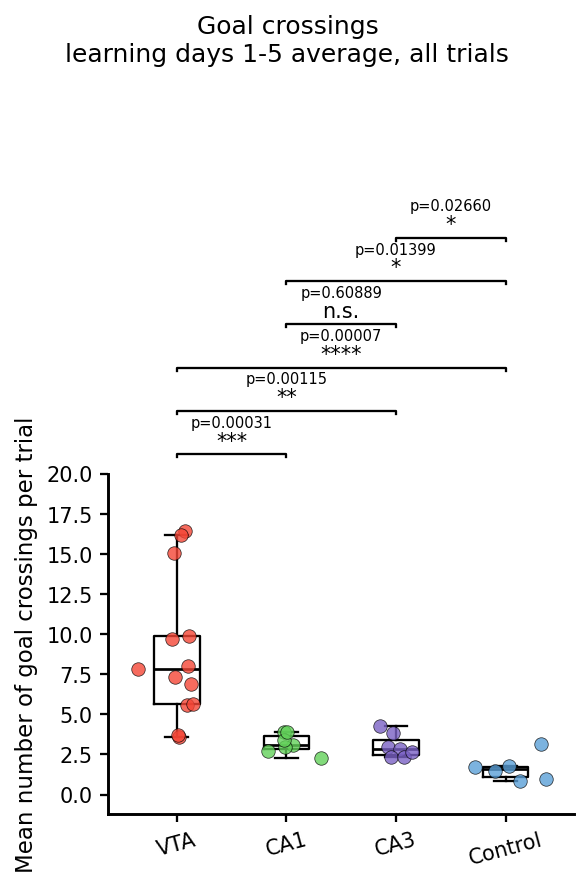


Boxplot: test day
Metric: n_crossings
Animals included:
  VTA (ChR2): n = 13, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  CA1 (CA1): n = 7, ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3): n = 7, ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
  Control (Control): n = 6, ids = ['C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']

Mann-Whitney U tests:
  VTA vs CA1: n=13 vs 7, mean=10.154 vs 2.714, median=9.000 vs 3.000, U=87.0, rank-biserial=0.912, p=0.00109
  VTA vs CA3: n=13 vs 7, mean=10.154 vs 3.143, median=9.000 vs 3.000, U=84.0, rank-biserial=0.846, p=0.00252
  VTA vs Control: n=13 vs 6, mean=10.154 vs 0.833, median=9.000 vs 1.000, U=78.0, rank-biserial=1.000, p=0.00071
  CA1 vs CA3: n=7 vs 7, mean=2.714 vs 3.143, median=3.000 vs 3.000, U=21.0, rank-biserial=-0.143, p=0.69335
  CA1 vs Control: n=7 vs 6, mean=2.714 vs 0.833, median=3.000 vs 1.000, U=38.5, r

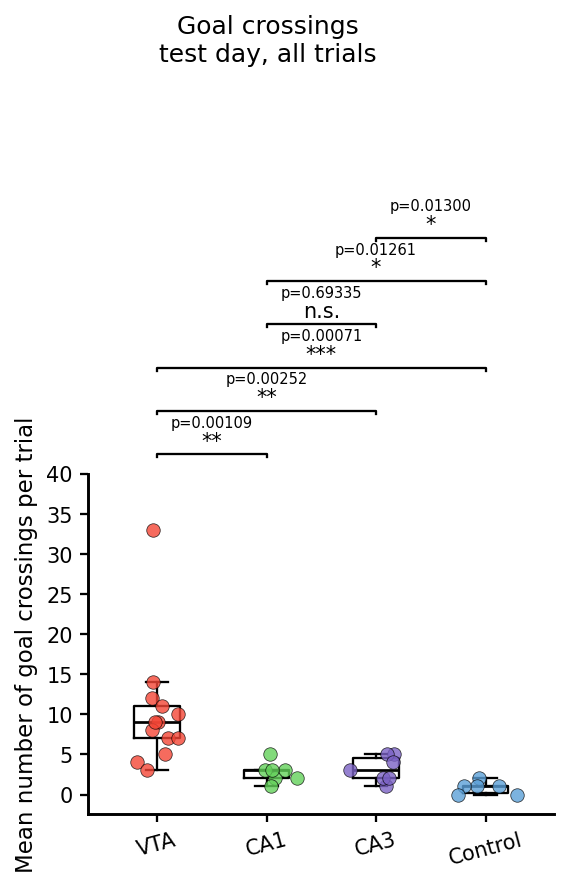


Within-day progress plot
Using column: n_crossings
Trial column used: inferred from sub/ses order
  VTA (ChR2): n = 13, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  CA1 (CA1): n = 7, ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3): n = 7, ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
  Control (Control): n = 6, ids = ['C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_within_day_n_crossings_ChR2_vs_CA1_vs_CA3_vs_Control.svg


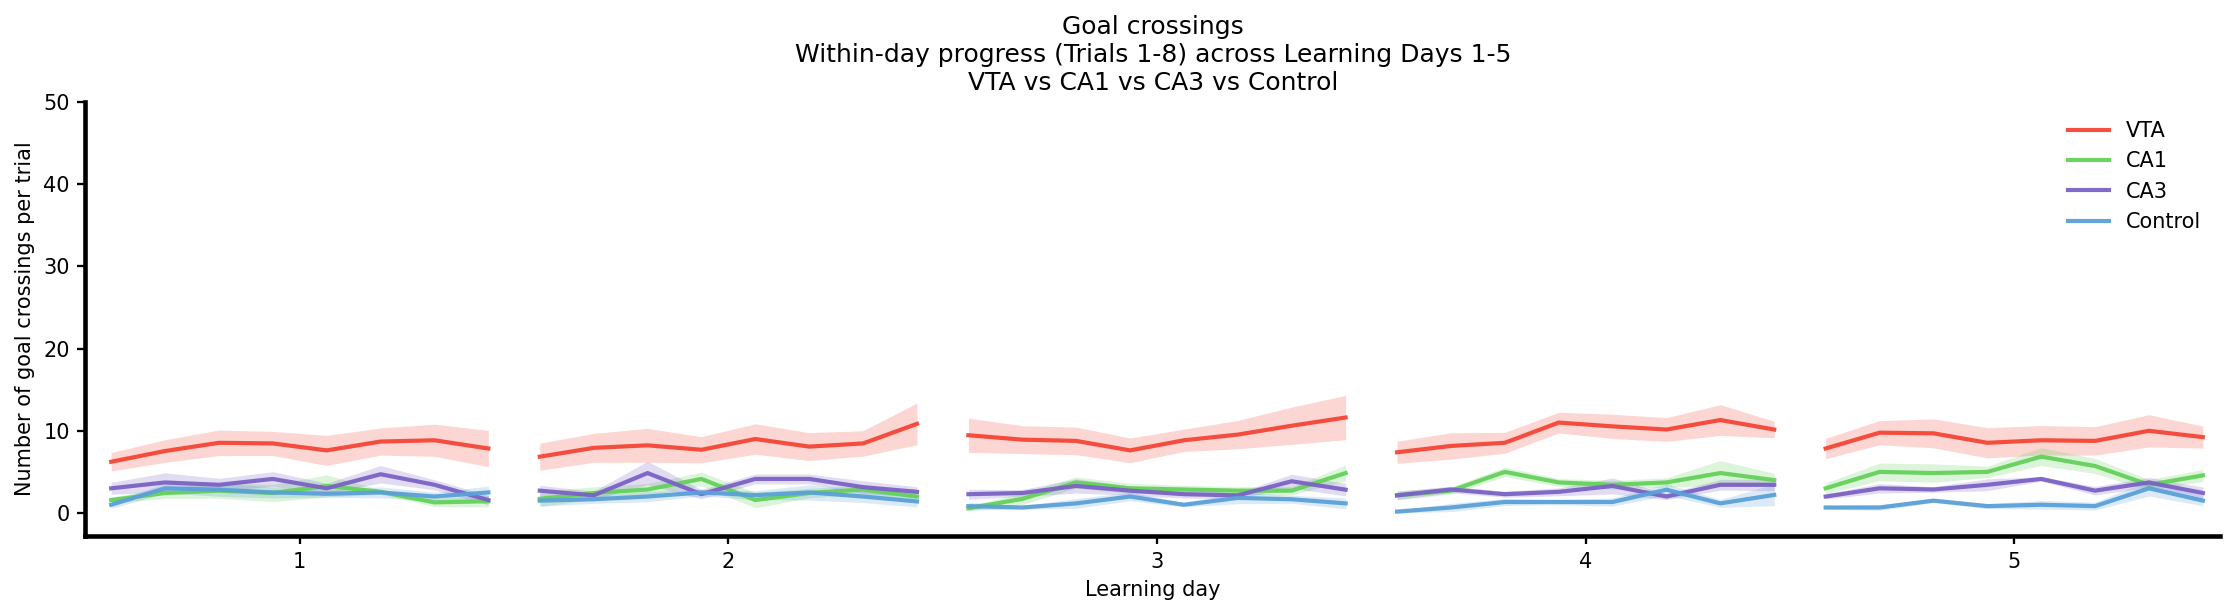


Groups used for plotting/stats: ['ChR2_short', 'CA1', 'CA3', 'Control']
Original genotypes loaded: ['CA1', 'CA1_control', 'CA3', 'ChR2_short', 'NAc_control']
Custom IDs loaded: []
Using column: n_crossings
Control pooled from: ['CA1_control', 'NAc_control']

Animals included:
  VTA short (ChR2_short):
    animals in dataset: 8
    animals plotted:    8
    ids plotted:        ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  CA1 (CA1):
    animals in dataset: 7
    animals plotted:    7
    ids plotted:        ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3):
    animals in dataset: 7
    animals plotted:    7
    ids plotted:        ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
  Control (Control):
    animals in dataset: 6
    animals plotted:    6
    ids plotted:        ['C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_lin

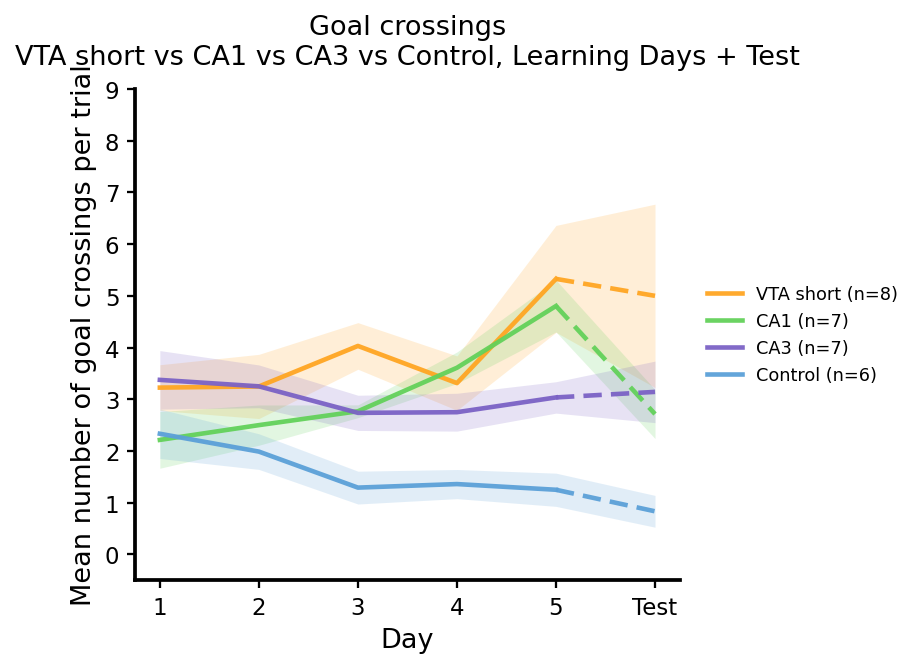


Boxplot: learning days 1-5 average
Metric: n_crossings
Animals included:
  VTA short (ChR2_short): n = 8, ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  CA1 (CA1): n = 7, ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3): n = 7, ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
  Control (Control): n = 6, ids = ['C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']

Mann-Whitney U tests:
  VTA short vs CA1: n=8 vs 7, mean=3.829 vs 3.179, median=3.668 vs 3.075, U=38.0, rank-biserial=0.357, p=0.28096
  VTA short vs CA3: n=8 vs 7, mean=3.829 vs 3.030, median=3.668 vs 2.850, U=41.0, rank-biserial=0.464, p=0.14765
  VTA short vs Control: n=8 vs 6, mean=3.829 vs 1.645, median=3.668 vs 1.579, U=46.0, rank-biserial=0.917, p=0.00266
  CA1 vs CA3: n=7 vs 7, mean=3.179 vs 3.030, median=3.075 vs 2.850, U=29.0, rank-biserial=0.184, p=0.60889
  CA1 vs Control: n=7 vs 6, mean=3.179 vs 1.645, median=3.075 vs 1.57

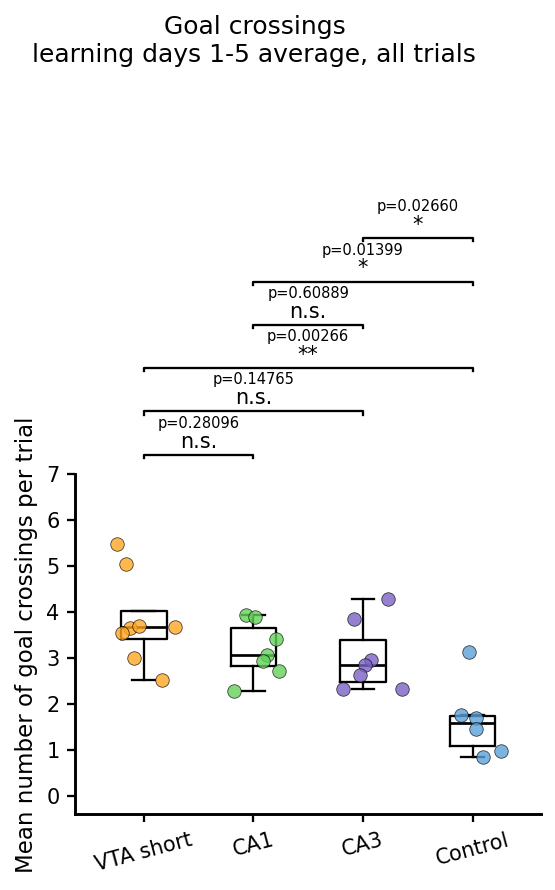


Boxplot: test day
Metric: n_crossings
Animals included:
  VTA short (ChR2_short): n = 8, ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  CA1 (CA1): n = 7, ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3): n = 7, ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
  Control (Control): n = 6, ids = ['C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']

Mann-Whitney U tests:
  VTA short vs CA1: n=8 vs 7, mean=5.000 vs 2.714, median=3.500 vs 3.000, U=34.0, rank-biserial=0.214, p=0.51726
  VTA short vs CA3: n=8 vs 7, mean=5.000 vs 3.143, median=3.500 vs 3.000, U=31.0, rank-biserial=0.107, p=0.76952
  VTA short vs Control: n=8 vs 6, mean=5.000 vs 0.833, median=3.500 vs 1.000, U=42.5, rank-biserial=0.771, p=0.01721
  CA1 vs CA3: n=7 vs 7, mean=2.714 vs 3.143, median=3.000 vs 3.000, U=21.0, rank-biserial=-0.143, p=0.69335
  CA1 vs Control: n=7 vs 6, mean=2.714 vs 0.833, median=3.000 vs 1.000, U=38.5, rank-

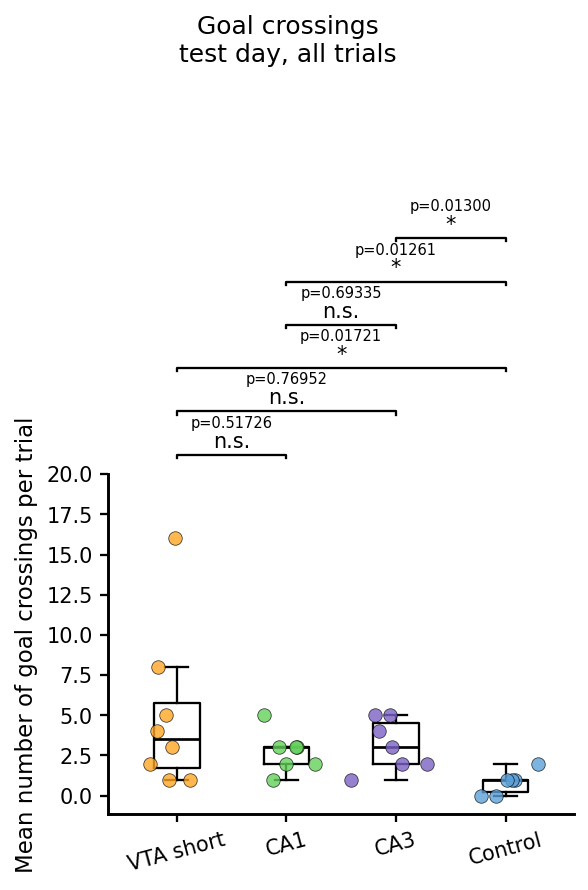


Within-day progress plot
Using column: n_crossings
Trial column used: inferred from sub/ses order
  VTA short (ChR2_short): n = 8, ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  CA1 (CA1): n = 7, ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3): n = 7, ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
  Control (Control): n = 6, ids = ['C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_within_day_n_crossings_ChR2_short_vs_CA1_vs_CA3_vs_Control.svg


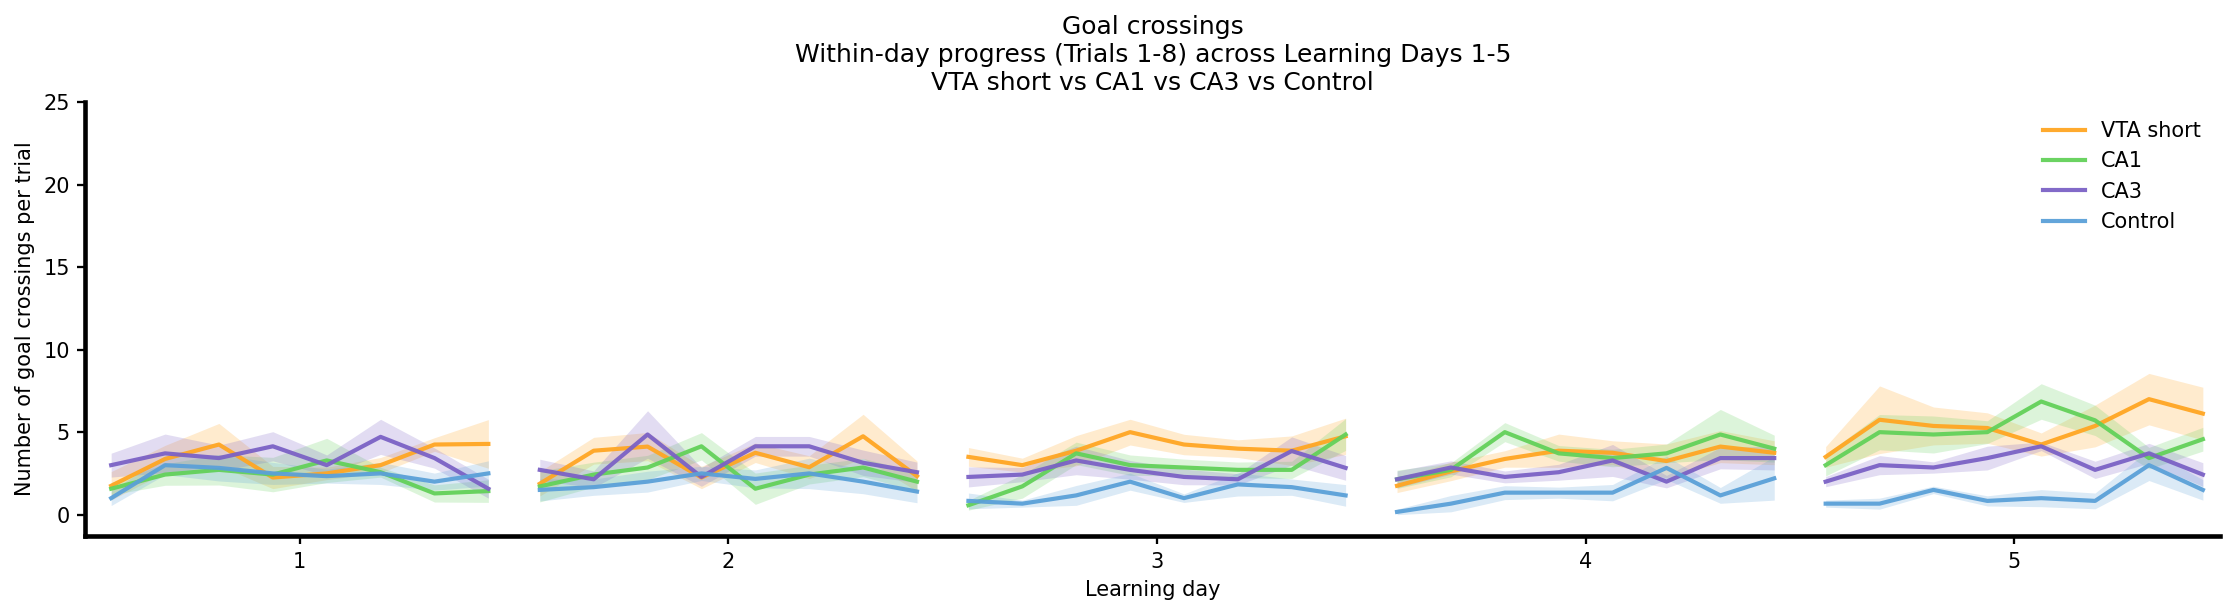


Groups used for plotting/stats: ['short_1', 'short_2']
Original genotypes loaded: ['ChR2_short']
Custom IDs loaded: ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
Using column: n_crossings

Animals included:
  Short 1 (short_1):
    animals in dataset: 3
    animals plotted:    3
    ids plotted:        ['AI (Short 1)', 'AJ (Short 1)', 'AL (Short 1)']
  Short 2 (short_2):
    animals in dataset: 5
    animals plotted:    5
    ids plotted:        ['V1 (Short 2)', 'V2 (Short 2)', 'V3 (Short 2)', 'V4 (Short 2)', 'V5 (Short 2)']
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_line_n_crossings_short_1_vs_short_2.svg


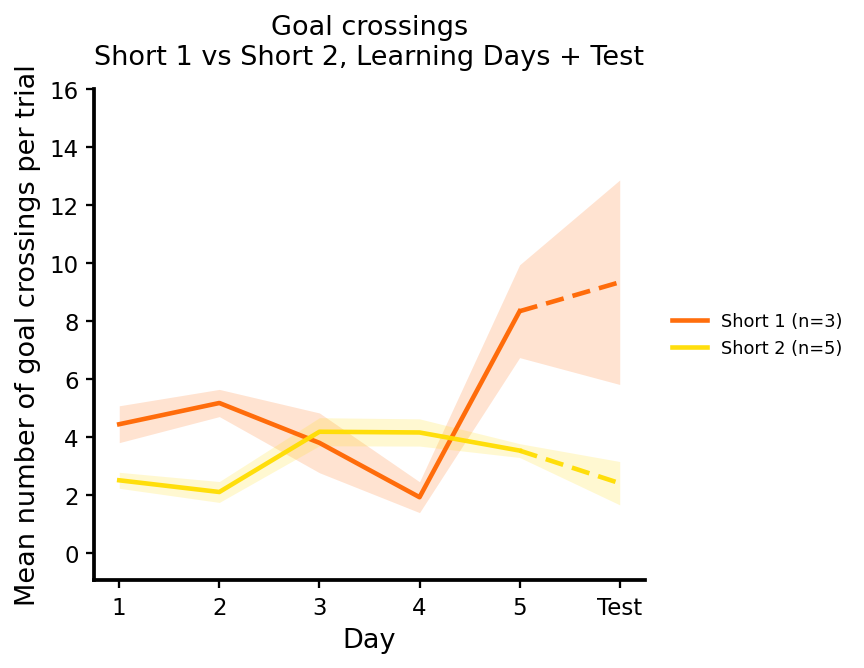


Boxplot: learning days 1-5 average
Metric: n_crossings
Animals included:
  Short 1 (short_1): n = 3, ids = ['AI (Short 1)', 'AJ (Short 1)', 'AL (Short 1)']
  Short 2 (short_2): n = 5, ids = ['V1 (Short 2)', 'V2 (Short 2)', 'V3 (Short 2)', 'V4 (Short 2)', 'V5 (Short 2)']

Mann-Whitney U tests:
  Short 1 vs Short 2: n=3 vs 5, mean=4.729 vs 3.289, median=5.050 vs 3.554, U=13.0, rank-biserial=0.733, p=0.14286
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_boxplot_n_crossings_learning_days_1_to_5_mean_short_1_vs_short_2.svg


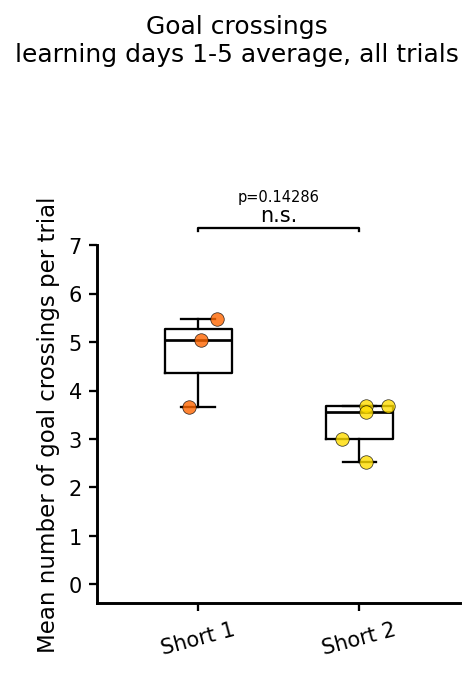


Boxplot: test day
Metric: n_crossings
Animals included:
  Short 1 (short_1): n = 3, ids = ['AI (Short 1)', 'AJ (Short 1)', 'AL (Short 1)']
  Short 2 (short_2): n = 5, ids = ['V1 (Short 2)', 'V2 (Short 2)', 'V3 (Short 2)', 'V4 (Short 2)', 'V5 (Short 2)']

Mann-Whitney U tests:
  Short 1 vs Short 2: n=3 vs 5, mean=9.333 vs 2.400, median=8.000 vs 2.000, U=14.0, rank-biserial=0.867, p=0.07192
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_boxplot_n_crossings_test_day_short_1_vs_short_2.svg


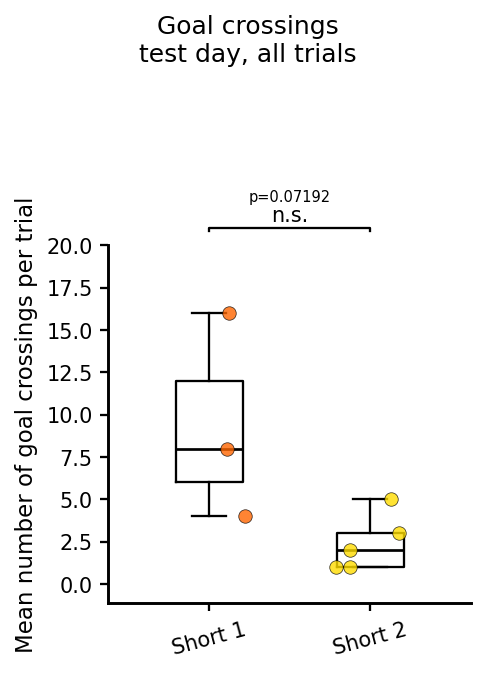


Within-day progress plot
Using column: n_crossings
Trial column used: inferred from sub/ses order
  Short 1 (short_1): n = 3, ids = ['AI (Short 1)', 'AJ (Short 1)', 'AL (Short 1)']
  Short 2 (short_2): n = 5, ids = ['V1 (Short 2)', 'V2 (Short 2)', 'V3 (Short 2)', 'V4 (Short 2)', 'V5 (Short 2)']
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_within_day_n_crossings_short_1_vs_short_2.svg


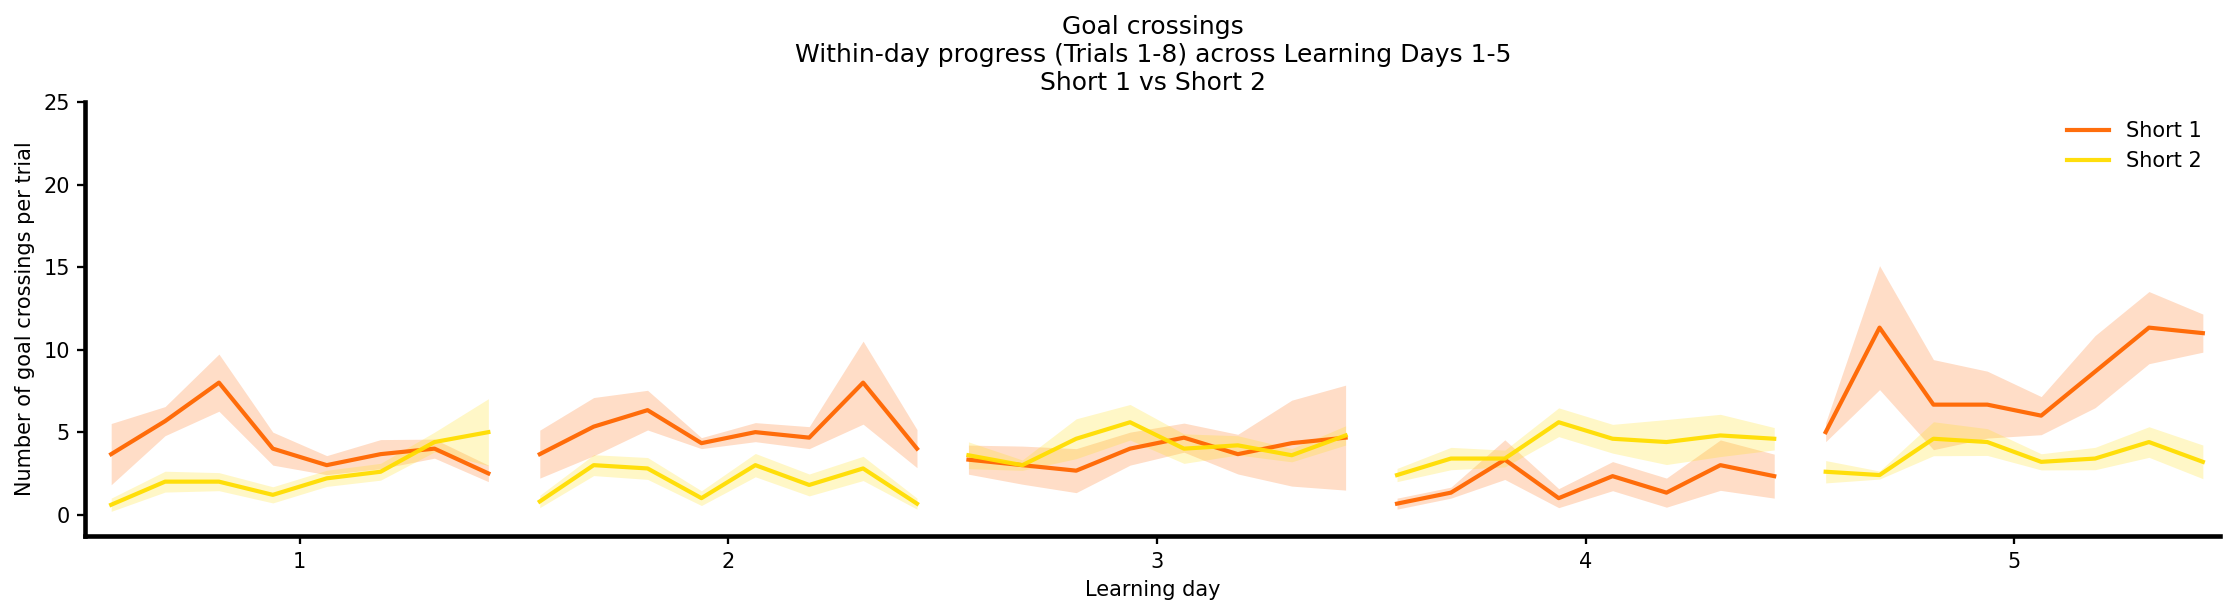


Groups used for plotting/stats: ['CA1_control', 'NAc_control']
Original genotypes loaded: ['CA1_control', 'NAc_control']
Custom IDs loaded: []
Using column: n_crossings

Animals included:
  CA1 control (CA1_control):
    animals in dataset: 3
    animals plotted:    3
    ids plotted:        ['C9', 'C10', 'C11']
  NAc control (NAc_control):
    animals in dataset: 3
    animals plotted:    3
    ids plotted:        ['N8', 'N9', 'N10']
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_line_n_crossings_CA1_control_vs_NAc_control.svg


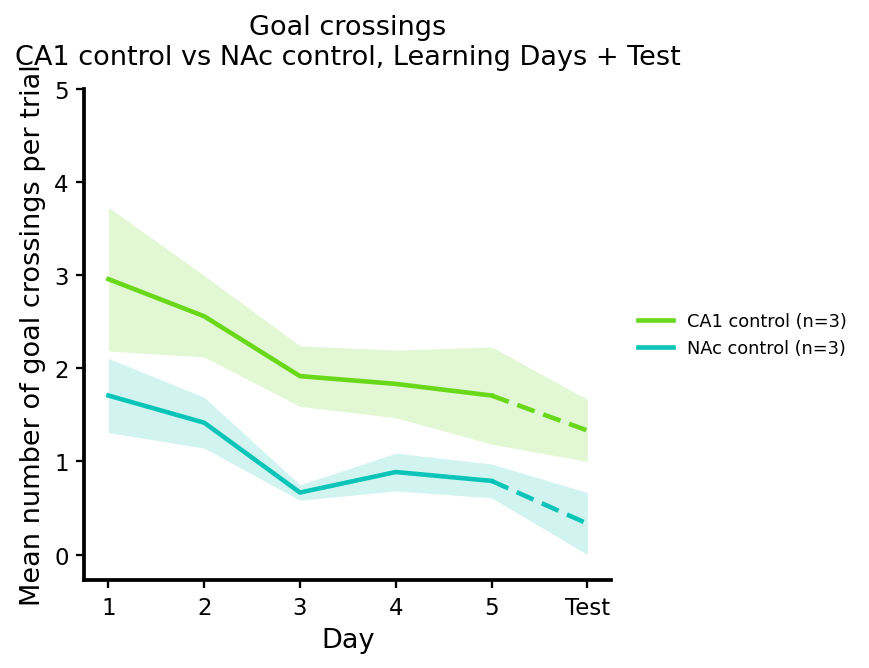


Boxplot: learning days 1-5 average
Metric: n_crossings
Animals included:
  CA1 control (CA1_control): n = 3, ids = ['C9', 'C10', 'C11']
  NAc control (NAc_control): n = 3, ids = ['N8', 'N9', 'N10']

Mann-Whitney U tests:
  CA1 control vs NAc control: n=3 vs 3, mean=2.195 vs 1.094, median=1.761 vs 0.975, U=9.0, rank-biserial=1.000, p=0.10000
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_boxplot_n_crossings_learning_days_1_to_5_mean_CA1_control_vs_NAc_control.svg


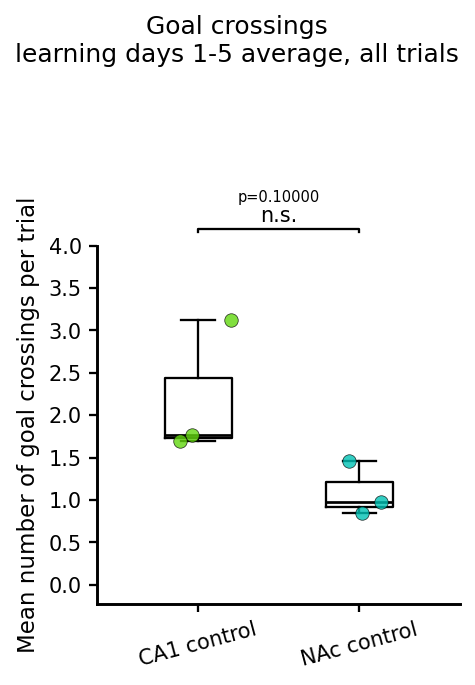


Boxplot: test day
Metric: n_crossings
Animals included:
  CA1 control (CA1_control): n = 3, ids = ['C9', 'C10', 'C11']
  NAc control (NAc_control): n = 3, ids = ['N8', 'N9', 'N10']

Mann-Whitney U tests:
  CA1 control vs NAc control: n=3 vs 3, mean=1.333 vs 0.333, median=1.000 vs 0.000, U=8.0, rank-biserial=0.778, p=0.15730
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_boxplot_n_crossings_test_day_CA1_control_vs_NAc_control.svg


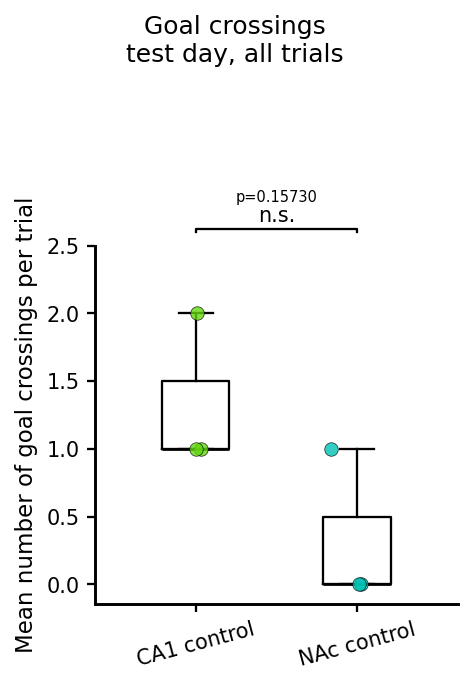


Within-day progress plot
Using column: n_crossings
Trial column used: inferred from sub/ses order
  CA1 control (CA1_control): n = 3, ids = ['C9', 'C10', 'C11']
  NAc control (NAc_control): n = 3, ids = ['N8', 'N9', 'N10']
Saved editable vector SVG: /Users/stella/Desktop/PhD/thesis/figures/goal_crossings_within_day_n_crossings_CA1_control_vs_NAc_control.svg


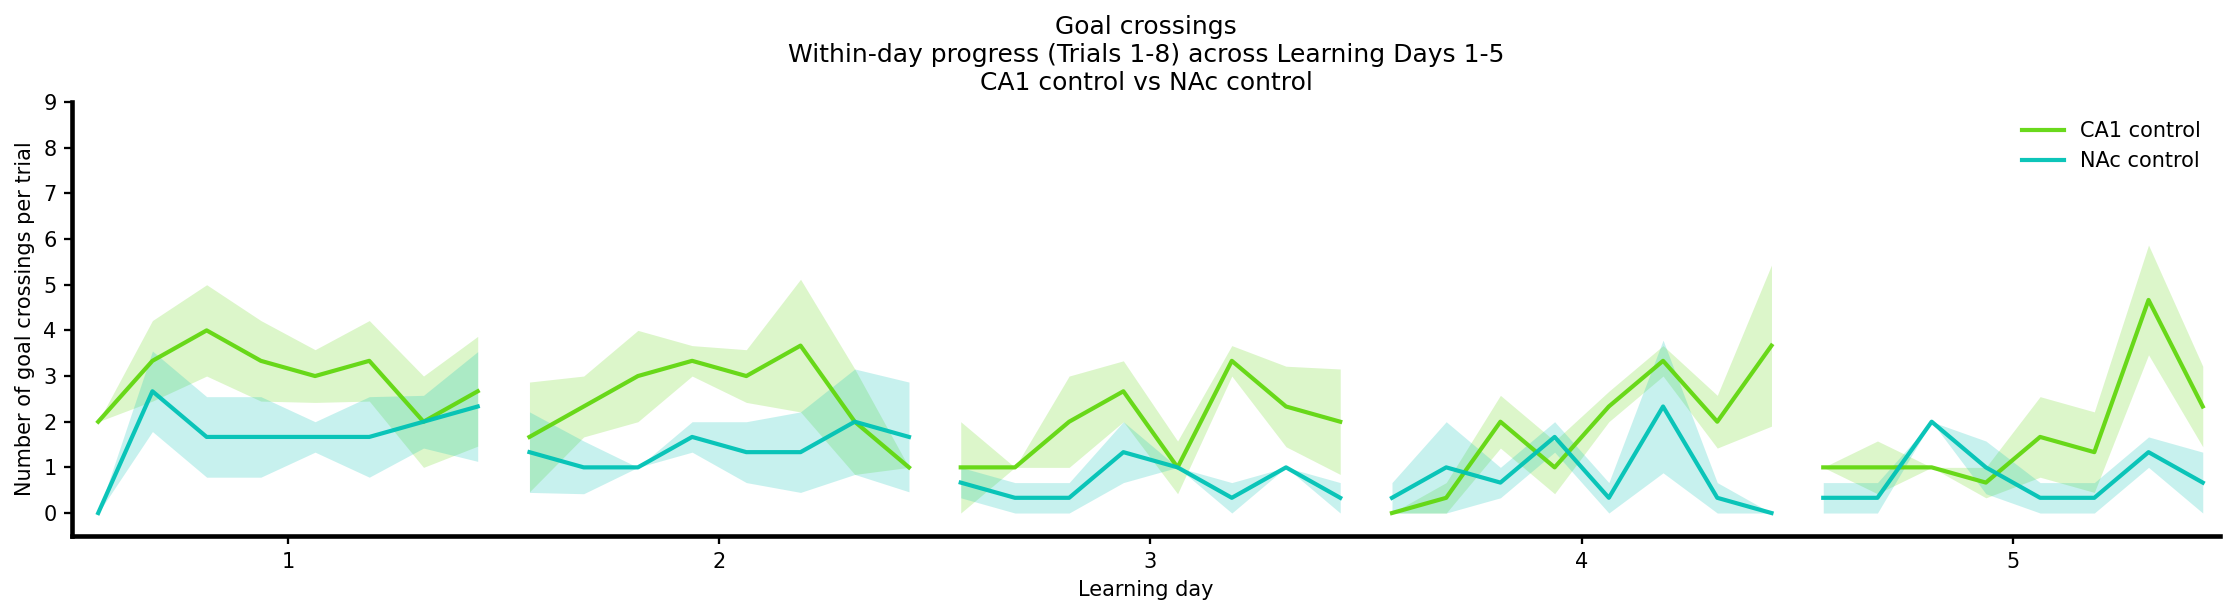

In [11]:
# Plot number of goal crossings across L1-L5 + Test
#
# Produces, for every group-set in GROUP_SETS:
#   1) Line plot across L1-L5 + Test
#   2) Boxplot: learning days 1-5 average
#   3) Boxplot: test day
#   4) Within-day progress plot across Learning Days 1-5
#      Trials 1-8, mean with optional shaded SEM
#
# Features:
#   - pooled Control = CA1_control + NAc_control
#   - custom ID groups:
#       short_1 = AI, AJ, AL
#       short_2 = V1, V2, V3, V4, V5
#   - line plot is solid from Day 1-Day 5 and dashed from Day 5-Test
#   - "reward zone" display name changed to "goal"
#   - y-axis lower limit padded by percentage
#   - boxplot p-values are drawn outside the data y-axis
#   - compact Nature-style boxplots
#   - editable vector SVG export for Inkscape/publication
# ============================================================

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ============================================================
# OPTIONS
# ============================================================

GROUP_SETS = [
    ['ChR2', 'eYFP_ChR2'],
    ['ChR2', 'ChR2_short', 'eYFP_ChR2'],
    ['ChR2', 'NAc', 'Control'],
    ['ChR2', 'CA1', 'CA3', 'Control'],
    ['ChR2_short', 'CA1', 'CA3', 'Control'],
    ['short_1', 'short_2'],
    ['CA1_control', 'NAc_control'],
]

CUSTOM_GROUP_ID_MAP = {
    'short_1': ['AI', 'AJ', 'AL'],
    'short_2': ['V1', 'V2', 'V3', 'V4', 'V5'],
}

CUSTOM_GROUP_GENOTYPE_SOURCE = {
    'short_1': 'ChR2_short',
    'short_2': 'ChR2_short',
}

POOLED_CONTROL_ORIGINAL_GROUPS = ['CA1_control', 'NAc_control']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'short_1': 'Short 1',
    'short_2': 'Short 2',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
    'WT': 'WT',
    'ArchT': 'VTA ArchT',
    'eYFP_ArchT': 'VTA control',
}

EXCLUDE_ID = []
EXCLUDE_SUBS = []

REQUIRE_COMPLETE = False
PLOT_INDIVIDUAL = False
PLOT_SEM_BARS = False
SHOW_SEM_SHADE = True
IGNORE_ZERO_CROSSINGS = False

SHOW_ANIMAL_IDS = False
COMPARISONS = 'all'
SHOW_P_VALUES = True

P_DECIMALS = 5

# Compact boxplot appearance
BOX_GROUP_SPACING = 0.72
BOX_WIDTH = 0.3
JITTER = 0.105
DOT_SIZE = 42
DOT_ALPHA = 0.8
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.35

# P-value annotation band above boxplot
P_ANNOT_Y_START = 0.12
P_ANNOT_Y_STEP = 0.5
P_ANNOT_CAP_HEIGHT = 0.035
P_ANNOT_STAR_OFFSET = 0.04
P_ANNOT_P_OFFSET = 0.28
P_ANNOT_LINEWIDTH = 1.1
P_ANNOT_STAR_FONTSIZE = 10
P_ANNOT_P_FONTSIZE = 7

# Y-axis padding as fraction of y-axis upper limit.
Y_BOTTOM_PAD_FRAC = 0.06

LINE_YMAX = None
LINE_Y_TICK_STEP = None

BOX_YMAX = None
BOX_Y_TICK_STEP = None

WITHIN_DAY_YMAX = None
WITHIN_DAY_Y_TICK_STEP = None
WITHIN_DAY_FIGSIZE = (15, 4.2)

SAVE_FIGURES = True
SAVE_DIR = Path('/Users/stella/Desktop/PhD/thesis/figures')
SAVE_SVG = True
SAVE_HIGH_DPI_PNG = False
FIG_DPI = 600
SHOW_FIGURES = True

np.random.seed(1)

plot_days = np.arange(1, 7)
x_vals = plot_days - 1
learning_days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['path.simplify'] = False
plt.rcParams['savefig.dpi'] = FIG_DPI
plt.rcParams['figure.dpi'] = 150

if SAVE_FIGURES:
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

VALUE_COL = 'n_crossings'
VALUE_LABEL = 'Mean number of goal crossings per trial'
LINE_TITLE = 'Goal crossings'
BOXPLOT_TITLE = 'Goal crossings'
WITHIN_DAY_YLABEL = 'Number of goal crossings per trial'
WITHIN_DAY_TITLE = 'Goal crossings'
MODE_TAG = 'n_crossings'


def safe_filename(text):
    text = re.sub(r'[^A-Za-z0-9._-]+', '_', str(text))
    return text.strip('_')


def save_figure(fig, stem):
    if not SAVE_FIGURES:
        return

    stem = safe_filename(stem)

    if SAVE_SVG:
        svg_path = SAVE_DIR / f'{stem}.svg'
        fig.savefig(svg_path, format='svg', bbox_inches='tight')
        print(f"Saved editable vector SVG: {svg_path}")

    if SAVE_HIGH_DPI_PNG:
        png_path = SAVE_DIR / f'{stem}.png'
        fig.savefig(png_path, format='png', dpi=FIG_DPI, bbox_inches='tight')
        print(f"Saved high-DPI PNG: {png_path}")


def get_plot_color(g):
    try:
        return get_genotype_color(g)
    except Exception:
        if g in ['short_1', 'short_2']:
            try:
                return get_genotype_color('ChR2_short')
            except Exception:
                return '#4E79A7'

        fallback = {
            'ChR2': '#4E79A7',
            'eYFP_ChR2': '#BAB0AC',
            'ChR2_short': '#E15759',
            'CA1': '#59A14F',
            'CA3': '#F28E2B',
            'NAc': '#B07AA1',
            'Control': '#7F7F7F',
            'CA1_control': '#86BCB6',
            'NAc_control': '#9C755F',
        }
        return fallback.get(g, '#333333')


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def get_comparisons(groups, comparisons):
    if comparisons == 'all':
        pairs = []
        for i in range(len(groups)):
            for j in range(i + 1, len(groups)):
                pairs.append((groups[i], groups[j]))
        return pairs
    return comparisons


def style_nature(ax, linewidth=1.6):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.1)
    ax.grid(False)


def add_analysis_group(meta_df, groups):
    meta_df = meta_df.copy()
    meta_df['analysis_group'] = meta_df['genotype']

    if 'id' not in meta_df.columns:
        return meta_df

    id_as_str = meta_df['id'].astype(str)

    for group_name, ids in CUSTOM_GROUP_ID_MAP.items():
        if group_name not in groups:
            continue

        ids_str = [str(x) for x in ids]
        mask = id_as_str.isin(ids_str)

        genotype_source = CUSTOM_GROUP_GENOTYPE_SOURCE.get(group_name, None)
        if genotype_source is not None and 'genotype_original' in meta_df.columns:
            mask = mask & (meta_df['genotype_original'] == genotype_source)

        meta_df.loc[mask, 'analysis_group'] = group_name

    return meta_df


def get_animal_label(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        animal_id = str(ms['id'].dropna().iloc[0])
    else:
        animal_id = str(sub)

    if 'analysis_group' in ms.columns and ms['analysis_group'].notna().any():
        analysis_group = str(ms['analysis_group'].dropna().iloc[0])
        if analysis_group in CUSTOM_GROUP_ID_MAP:
            return f'{animal_id} ({DISPLAY_NAME.get(analysis_group, analysis_group)})'

    if 'genotype_original' in ms.columns and ms['genotype'].iloc[0] == 'Control':
        original = str(ms['genotype_original'].dropna().iloc[0])
        return f'{animal_id} ({original})'

    return animal_id


def assign_learning_and_test_days(meta_df):
    meta_df = meta_df.copy()
    meta_df['plot_day'] = np.nan

    mask_L = meta_df['trial_type'] == 'L'
    meta_df.loc[mask_L, 'plot_day'] = meta_df.loc[mask_L, 'trial_type_day']

    meta_df = meta_df[
        (~mask_L) | (meta_df['trial_type_day'].isin([1, 2, 3, 4, 5]))
    ].copy()

    for sub in meta_df['sub'].unique():
        ms = meta_df[meta_df['sub'] == sub]

        L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
        if len(L_ses) == 0:
            continue

        last_L_ses = L_ses.max()
        T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]

        if len(T_after) == 0:
            continue

        first_T_ses = T_after['ses'].min()

        idx = meta_df.index[
            (meta_df['sub'] == sub) &
            (meta_df['trial_type'] == 'T') &
            (meta_df['ses'] == first_T_ses)
        ]

        meta_df.loc[idx, 'plot_day'] = 6

    meta_df = meta_df[meta_df['plot_day'].isin([1, 2, 3, 4, 5, 6])].copy()

    return meta_df


def add_trial_in_day(meta_df):
    meta_df = meta_df.copy()

    candidate_cols = [
        'trial_in_day',
        'trial_num',
        'trial_number',
        'trial',
        'trial_idx',
        'trial_index',
        'trial_in_session',
        'trial_id_in_session',
    ]

    trial_col = next((c for c in candidate_cols if c in meta_df.columns), None)

    if trial_col is not None:
        meta_df['trial_in_day'] = meta_df[trial_col].astype(int)
    else:
        meta_df = meta_df.sort_values(['sub', 'ses']).copy()
        meta_df['trial_in_day'] = meta_df.groupby(['sub', 'ses']).cumcount() + 1

    meta_df = meta_df[meta_df['trial_in_day'].between(1, 8)].copy()

    return meta_df, trial_col


def build_genotype_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []
    animal_ids = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()
        mean_by_day = ms.groupby('plot_day')[value_col].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)
        animal_ids.append(get_animal_label(ms, sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids


def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


def set_y_axis_with_fractional_bottom_pad(ax, y_top=None, tick_step=None):
    if y_top is None:
        y_top = ax.get_ylim()[1]

    if not np.isfinite(y_top) or y_top <= 0:
        y_top = 1.0

    y_bottom = -Y_BOTTOM_PAD_FRAC * y_top
    ax.set_ylim(y_bottom, y_top)

    if tick_step is not None:
        ax.set_yticks(np.arange(0, y_top + tick_step, tick_step))
    else:
        ticks = ax.get_yticks()
        ticks = ticks[ticks >= 0]
        if len(ticks) == 0 or ticks[0] != 0:
            ticks = np.insert(ticks, 0, 0)
        ax.set_yticks(ticks)


def get_data_y_top(vals_groups):
    ymax_candidates = []

    for vals in vals_groups:
        vals = np.asarray(vals, dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) > 0:
            ymax_candidates.append(np.nanmax(vals))

    if len(ymax_candidates) == 0:
        return 1.0

    ymax = np.nanmax(ymax_candidates)

    if not np.isfinite(ymax) or ymax <= 0:
        return 1.0

    return ymax * 1.20


def get_line_y_top(group_data, groups):
    if LINE_YMAX is not None:
        return LINE_YMAX

    ymax_candidates = []

    for g in groups:
        mat = group_data[g]['mat']
        if mat is None:
            continue

        mean_ = np.nanmean(mat, axis=0)
        sem_ = sem_by_day(mat)
        ymax_candidates.append(np.nanmax(mean_ + sem_))

        if PLOT_INDIVIDUAL and np.any(np.isfinite(mat)):
            ymax_candidates.append(np.nanmax(mat))

    if len(ymax_candidates) == 0:
        return 1.0

    ymax = np.nanmax(ymax_candidates)

    if not np.isfinite(ymax) or ymax <= 0:
        ymax = 1.0

    return ymax * 1.22


def get_within_day_y_top(mats):
    ymax_candidates = []

    for mat in mats:
        if mat is None:
            continue
        vals = mat[np.isfinite(mat)]
        if len(vals) > 0:
            ymax_candidates.append(np.nanmax(vals))

    if len(ymax_candidates) == 0:
        return 1.0

    ymax = np.nanmax(ymax_candidates)
    if not np.isfinite(ymax) or ymax <= 0:
        ymax = 1.0

    if WITHIN_DAY_YMAX is not None:
        return WITHIN_DAY_YMAX

    return ymax * 1.20


def plot_line_day5_to_test_dashed(
    ax,
    y_vals,
    color,
    linewidth,
    alpha,
    zorder,
    label=None
):
    y_vals = np.asarray(y_vals, dtype=float)

    ax.plot(
        x_vals[:5],
        y_vals[:5],
        '-',
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        label=label,
        zorder=zorder
    )

    ax.plot(
        x_vals[4:6],
        y_vals[4:6],
        '--',
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        dashes=(4, 2),
        dash_capstyle='butt',
        zorder=zorder
    )


def plot_group_shaded(ax, mat, subs, group_key, label):
    if mat is None or len(subs) == 0:
        return

    col = get_plot_color(group_key)

    if PLOT_INDIVIDUAL:
        for row in mat:
            plot_line_day5_to_test_dashed(
                ax,
                row,
                color=col,
                linewidth=1.0,
                alpha=0.14,
                zorder=1
            )

    mean_ = np.nanmean(mat, axis=0)
    sem_ = sem_by_day(mat)

    if SHOW_SEM_SHADE:
        ax.fill_between(
            x_vals,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=0.18,
            linewidth=0,
            zorder=2
        )

    plot_line_day5_to_test_dashed(
        ax,
        mean_,
        color=col,
        linewidth=2.2,
        alpha=0.95,
        label=f'{label} (n={len(subs)})',
        zorder=3
    )

    if PLOT_SEM_BARS:
        ax.errorbar(
            x_vals,
            mean_,
            yerr=sem_,
            fmt='none',
            ecolor=col,
            elinewidth=1.1,
            capsize=3,
            alpha=0.9,
            zorder=4
        )


def draw_p_value_on_annotation_axis(ann_ax, x1, x2, y, p):
    ann_ax.plot(
        [x1, x1, x2, x2],
        [y - P_ANNOT_CAP_HEIGHT, y, y, y - P_ANNOT_CAP_HEIGHT],
        color='black',
        linewidth=P_ANNOT_LINEWIDTH,
        clip_on=False,
        zorder=10
    )

    ann_ax.text(
        (x1 + x2) / 2.0,
        y + P_ANNOT_STAR_OFFSET,
        p_to_stars(p),
        ha='center',
        va='bottom',
        fontsize=P_ANNOT_STAR_FONTSIZE,
        clip_on=False,
        zorder=11
    )

    ann_ax.text(
        (x1 + x2) / 2.0,
        y + P_ANNOT_P_OFFSET,
        f"p={format_p(p, P_DECIMALS)}",
        ha='center',
        va='bottom',
        fontsize=P_ANNOT_P_FONTSIZE,
        clip_on=False,
        zorder=11
    )


def values_from_matrix(group_data, group, mode):
    mat = group_data[group]['mat']
    subs = group_data[group]['subs']
    ids = group_data[group]['ids']

    if mat is None or len(subs) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'value'])

    rows = []

    for i, sub in enumerate(subs):
        row = mat[i, :]

        if mode == 'learning_mean':
            value = np.nanmean(row[0:5])
        elif mode == 'test':
            value = row[5]
        else:
            raise ValueError("mode must be 'learning_mean' or 'test'")

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'id': ids[i],
            'value': float(value)
        })

    return pd.DataFrame(rows)


def get_groups_to_load(groups):
    groups_to_load = []
    custom_ids_to_load = []

    for g in groups:
        if g == 'Control':
            groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)

        elif g in CUSTOM_GROUP_ID_MAP:
            custom_ids_to_load.extend(CUSTOM_GROUP_ID_MAP[g])

            genotype_source = CUSTOM_GROUP_GENOTYPE_SOURCE.get(g, None)
            if genotype_source is not None:
                groups_to_load.append(genotype_source)

        else:
            groups_to_load.append(g)

    groups_to_load = sorted(set(groups_to_load))
    custom_ids_to_load = sorted(set([str(x) for x in custom_ids_to_load]))

    return groups_to_load, custom_ids_to_load


def prepare_meta_for_groups(groups):
    needed_cols = [
        'usable',
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'sub',
        VALUE_COL,
    ]

    missing_cols = [c for c in needed_cols if c not in metadata.columns]
    if len(missing_cols) > 0:
        raise KeyError(f"Missing columns in metadata: {missing_cols}")

    groups_to_load, custom_ids_to_load = get_groups_to_load(groups)

    base_mask = (
        (metadata['usable'] == 1) &
        (metadata['trial_type'].isin(['L', 'T']))
    )

    if len(groups_to_load) > 0:
        genotype_mask = metadata['genotype'].isin(groups_to_load)
    else:
        genotype_mask = False

    if len(custom_ids_to_load) > 0 and 'id' in metadata.columns:
        custom_id_mask = metadata['id'].astype(str).isin(custom_ids_to_load)
    else:
        custom_id_mask = False

    meta_LT = metadata[
        base_mask &
        (genotype_mask | custom_id_mask)
    ].copy()

    meta_LT['genotype_original'] = meta_LT['genotype']

    if 'Control' in groups:
        meta_LT.loc[
            meta_LT['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
            'genotype'
        ] = 'Control'

    meta_LT = add_analysis_group(meta_LT, groups)
    meta_LT = meta_LT[meta_LT['analysis_group'].isin(groups)].copy()
    meta_LT['genotype'] = meta_LT['analysis_group']

    if IGNORE_ZERO_CROSSINGS:
        meta_LT = meta_LT[
            meta_LT[VALUE_COL].notna() &
            np.isfinite(meta_LT[VALUE_COL]) &
            (meta_LT[VALUE_COL] > 0)
        ].copy()
    else:
        meta_LT = meta_LT[
            meta_LT[VALUE_COL].notna() &
            np.isfinite(meta_LT[VALUE_COL])
        ].copy()

    exclude_ids_effective = [
        x for x in EXCLUDE_ID
        if str(x) not in custom_ids_to_load
    ]

    if len(exclude_ids_effective) > 0 and 'id' in meta_LT.columns:
        meta_LT = meta_LT[
            ~meta_LT['id'].astype(str).isin([str(x) for x in exclude_ids_effective])
        ].copy()

    if len(EXCLUDE_SUBS) > 0:
        meta_LT = meta_LT[
            ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
        ].copy()

    meta_LT = assign_learning_and_test_days(meta_LT)

    print("\n============================================================")
    print("Groups used for plotting/stats:", groups)
    print("Original genotypes loaded:", groups_to_load)
    print("Custom IDs loaded:", custom_ids_to_load)
    print("Using column:", VALUE_COL)

    if 'Control' in groups:
        print("Control pooled from:", POOLED_CONTROL_ORIGINAL_GROUPS)

    return meta_LT


def build_group_data(meta_LT, groups):
    group_data = {}

    print("\nAnimals included:")
    for g in groups:
        meta_g = meta_LT[meta_LT['genotype'] == g].copy()
        mat_g, subs_g, ids_g = build_genotype_matrix(meta_g, VALUE_COL)

        group_data[g] = {
            'meta': meta_g,
            'mat': mat_g,
            'subs': subs_g,
            'ids': ids_g,
        }

        print(f"  {DISPLAY_NAME.get(g, g)} ({g}):")
        print(f"    animals in dataset: {meta_g['sub'].nunique()}")
        print(f"    animals plotted:    {len(subs_g)}")
        print(f"    ids plotted:        {ids_g}")

    return group_data


def subject_trial_matrix_for_day(meta_g, day, value_col):
    md = meta_g[meta_g['trial_type_day'] == day].copy()

    if len(md) == 0:
        return None

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        mean_by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        vals = np.array(
            [mean_by_trial.get(t, np.nan) for t in trials],
            dtype=float
        )

        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)


def plot_within_day_curves(
    ax,
    meta_g,
    genotype_key,
    value_col,
    label=None,
    alpha_fill=0.22,
    alpha_line=0.9
):
    offsets = np.linspace(0.06, 0.94, len(trials))
    col = get_plot_color(genotype_key)

    first_day = True

    for day in learning_days:
        mat = subject_trial_matrix_for_day(meta_g, day, value_col)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0)

        sem_ = np.zeros(len(trials), dtype=float)
        for i in range(len(trials)):
            vals = mat[:, i]
            vals = vals[np.isfinite(vals)]
            if len(vals) <= 1:
                sem_[i] = 0.0
            else:
                sem_[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

        if SHOW_SEM_SHADE:
            ax.fill_between(
                x,
                mean_ - sem_,
                mean_ + sem_,
                color=col,
                alpha=alpha_fill,
                linewidth=0
            )

        ax.plot(
            x,
            mean_,
            '-',
            color=col,
            alpha=alpha_line,
            linewidth=2.0,
            label=label if first_day and (label is not None) else None,
            zorder=3
        )

        if PLOT_SEM_BARS:
            ax.errorbar(
                x,
                mean_,
                yerr=sem_,
                fmt='none',
                ecolor=col,
                elinewidth=1.1,
                capsize=3,
                alpha=0.9,
                zorder=4
            )

        first_day = False


def plot_line_for_groups(group_data, groups):
    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    for g in groups:
        plot_group_shaded(
            ax,
            group_data[g]['mat'],
            group_data[g]['subs'],
            group_key=g,
            label=DISPLAY_NAME.get(g, g)
        )

    ax.set_xlabel('Day', fontsize=13)
    ax.set_ylabel(VALUE_LABEL, fontsize=13)

    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    display_groups = ' vs '.join([DISPLAY_NAME.get(g, g) for g in groups])

    ax.set_title(
        f'{LINE_TITLE}\n{display_groups}, Learning Days + Test',
        fontsize=13,
        pad=12
    )

    style_nature(ax, linewidth=1.8)

    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 0:
        ax.legend(
            frameon=False,
            fontsize=8.5,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5)
        )

    y_top = get_line_y_top(group_data, groups)
    set_y_axis_with_fractional_bottom_pad(
        ax,
        y_top=y_top,
        tick_step=LINE_Y_TICK_STEP
    )

    plt.tight_layout(rect=[0, 0, 0.82, 0.95])

    group_tag = '_vs_'.join(groups)
    stem = f'goal_crossings_line_{MODE_TAG}_{group_tag}'
    save_figure(fig, stem)

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def plot_boxplot_from_matrix(group_data, groups, mode, title_suffix):
    group_dfs = {}
    vals_groups = []

    for g in groups:
        df_g = values_from_matrix(group_data, g, mode)
        group_dfs[g] = df_g
        vals_groups.append(df_g['value'].values.astype(float))

    print("\n============================================================")
    print(f"Boxplot: {title_suffix}")
    print(f"Metric: {VALUE_COL}")
    print("Animals included:")

    for g in groups:
        print(
            f"  {DISPLAY_NAME.get(g, g)} ({g}): "
            f"n = {len(group_dfs[g])}, ids = {list(group_dfs[g]['id'])}"
        )

    pairs = get_comparisons(groups, COMPARISONS)

    if len(groups) <= 2:
        fig_width = 3.1
    else:
        fig_width = max(3.6, 0.72 * len(groups) + 1.1)

    n_possible_pairs = len(pairs) if SHOW_P_VALUES else 0
    annot_ymax = (
        P_ANNOT_Y_START +
        max(n_possible_pairs - 1, 0) * P_ANNOT_Y_STEP +
        P_ANNOT_P_OFFSET +
        0.12
    )
    annot_ymax = max(1.0, annot_ymax)

    annot_height = 0.42 + 0.34 * max(n_possible_pairs, 1) if SHOW_P_VALUES else 0.05
    annot_height = min(2.8, annot_height)
    fig_height = 4.0 + annot_height

    if SHOW_P_VALUES:
        fig, (ann_ax, ax) = plt.subplots(
            2,
            1,
            figsize=(fig_width, fig_height),
            gridspec_kw={'height_ratios': [annot_height, 3.2]},
            sharex=True
        )
        ann_ax.set_axis_off()
    else:
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        ann_ax = None

    positions = np.arange(len(groups)) * BOX_GROUP_SPACING

    ax.boxplot(
        vals_groups,
        positions=positions,
        widths=BOX_WIDTH,
        patch_artist=False,
        showfliers=False,
        medianprops={'linewidth': 1.3, 'color': 'black'},
        boxprops={'linewidth': 1.1, 'color': 'black'},
        whiskerprops={'linewidth': 1.1, 'color': 'black'},
        capprops={'linewidth': 1.1, 'color': 'black'}
    )

    for i, g in enumerate(groups):
        df_g = group_dfs[g]
        vals = df_g['value'].values.astype(float)

        if len(vals) == 0:
            continue

        x_center = positions[i]
        x = np.random.normal(x_center, JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_plot_color(g),
            alpha=DOT_ALPHA,
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, df_g['id'].values):
                ax.text(
                    xi + 0.025,
                    yi,
                    str(animal_id),
                    fontsize=6.5,
                    color=get_plot_color(g),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    if BOX_YMAX is not None:
        y_top_for_axis = BOX_YMAX
    else:
        y_top_for_axis = get_data_y_top(vals_groups)

    print("\nMann-Whitney U tests:")
    p_line_index = 0

    if SHOW_P_VALUES and ann_ax is not None:
        ann_ax.set_xlim(positions[0] - 0.45, positions[-1] + 0.45)
        ann_ax.set_ylim(0, annot_ymax)

    for g1, g2 in pairs:
        if g1 not in groups or g2 not in groups:
            print(f"Skipping {g1} vs {g2}: group not in GROUPS")
            continue

        i = groups.index(g1)
        j = groups.index(g2)

        vals_i = vals_groups[i]
        vals_j = vals_groups[j]

        if len(vals_i) == 0 or len(vals_j) == 0:
            print(f"Skipping {g1} vs {g2}: one group has no data")
            continue

        stat, p = mannwhitneyu(vals_i, vals_j, alternative='two-sided')

        n1 = len(vals_i)
        n2 = len(vals_j)
        rank_biserial = (2 * stat) / (n1 * n2) - 1

        print(
            f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
            f"n={n1} vs {n2}, "
            f"mean={np.nanmean(vals_i):.3f} vs {np.nanmean(vals_j):.3f}, "
            f"median={np.nanmedian(vals_i):.3f} vs {np.nanmedian(vals_j):.3f}, "
            f"U={stat:.1f}, "
            f"rank-biserial={rank_biserial:.3f}, "
            f"p={format_p(p, P_DECIMALS)}"
        )

        if SHOW_P_VALUES and ann_ax is not None:
            y = P_ANNOT_Y_START + p_line_index * P_ANNOT_Y_STEP
            draw_p_value_on_annotation_axis(
                ann_ax,
                positions[i],
                positions[j],
                y,
                p
            )
            p_line_index += 1

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [DISPLAY_NAME.get(g, g) for g in groups],
        fontsize=10,
        rotation=15
    )

    ax.set_xlim(positions[0] - 0.45, positions[-1] + 0.45)
    ax.set_ylabel(VALUE_LABEL, fontsize=11)
    ax.set_xlabel('')

    trial_tag = 'crossing trials only' if IGNORE_ZERO_CROSSINGS else 'all trials'

    fig.suptitle(
        f'{BOXPLOT_TITLE}\n{title_suffix}, {trial_tag}',
        fontsize=12,
        y=0.995
    )

    set_y_axis_with_fractional_bottom_pad(
        ax,
        y_top=y_top_for_axis,
        tick_step=BOX_Y_TICK_STEP
    )
    style_nature(ax, linewidth=1.4)

    if SHOW_P_VALUES:
        fig.subplots_adjust(
            left=0.20,
            right=0.98,
            bottom=0.17,
            top=0.80,
            hspace=0.03
        )
    else:
        fig.subplots_adjust(
            left=0.20,
            right=0.98,
            bottom=0.17,
            top=0.88
        )

    group_tag = '_vs_'.join(groups)
    mode_tag = 'learning_days_1_to_5_mean' if mode == 'learning_mean' else 'test_day'
    stem = f'goal_crossings_boxplot_{MODE_TAG}_{mode_tag}_{group_tag}'
    save_figure(fig, stem)

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def plot_within_day_for_groups(meta_LT, groups):
    meta_L = meta_LT[
        (meta_LT['trial_type'] == 'L') &
        (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5])) &
        (meta_LT[VALUE_COL].notna()) &
        (np.isfinite(meta_LT[VALUE_COL]))
    ].copy()

    meta_L, trial_col = add_trial_in_day(meta_L)

    print("\n============================================================")
    print("Within-day progress plot")
    print("Using column:", VALUE_COL)
    print("Trial column used:", trial_col if trial_col is not None else "inferred from sub/ses order")

    within_day_mats = []

    fig, ax = plt.subplots(1, 1, figsize=WITHIN_DAY_FIGSIZE)

    for g in groups:
        meta_g = meta_L[meta_L['genotype'] == g].copy()

        ids_g = []
        for sub in meta_g['sub'].unique():
            ms = meta_g[meta_g['sub'] == sub]
            ids_g.append(get_animal_label(ms, sub))

        print(
            f"  {DISPLAY_NAME.get(g, g)} ({g}): "
            f"n = {meta_g['sub'].nunique()}, ids = {ids_g}"
        )

        for day in learning_days:
            mat_tmp = subject_trial_matrix_for_day(meta_g, day, VALUE_COL)
            if mat_tmp is not None:
                within_day_mats.append(mat_tmp)

        plot_within_day_curves(
            ax,
            meta_g,
            genotype_key=g,
            value_col=VALUE_COL,
            label=DISPLAY_NAME.get(g, g),
            alpha_fill=0.22,
            alpha_line=0.95
        )

    ax.set_xlabel('Learning day')
    ax.set_ylabel(WITHIN_DAY_YLABEL)

    ax.set_xticks(learning_days + 0.5)
    ax.set_xticklabels([str(d) for d in learning_days])

    ax.set_xlim(1.0, 5.98)

    display_groups = ' vs '.join([DISPLAY_NAME.get(g, g) for g in groups])

    ax.set_title(
        f'{WITHIN_DAY_TITLE}\n'
        f'Within-day progress (Trials 1-8) across Learning Days 1-5\n'
        f'{display_groups}',
        fontsize=12
    )

    style_nature(ax, linewidth=2.2)

    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 0:
        ax.legend(frameon=False)

    y_top = get_within_day_y_top(within_day_mats)
    set_y_axis_with_fractional_bottom_pad(
        ax,
        y_top=y_top,
        tick_step=WITHIN_DAY_Y_TICK_STEP
    )

    plt.tight_layout()

    group_tag = '_vs_'.join(groups)
    stem = f'goal_crossings_within_day_{MODE_TAG}_{group_tag}'
    save_figure(fig, stem)

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


# ============================================================
# Run all requested group sets
# ============================================================

for GROUPS in GROUP_SETS:
    meta_LT = prepare_meta_for_groups(GROUPS)
    group_data = build_group_data(meta_LT, GROUPS)

    plot_line_for_groups(group_data, GROUPS)

    plot_boxplot_from_matrix(
        group_data,
        GROUPS,
        mode='learning_mean',
        title_suffix='learning days 1-5 average'
    )

    plot_boxplot_from_matrix(
        group_data,
        GROUPS,
        mode='test',
        title_suffix='test day'
    )

    plot_within_day_for_groups(meta_LT, GROUPS)


# forgetting extinction


STRUCTURAL ROUND ASSIGNMENT TABLE BEFORE EXCLUSION
    sub  id genotype test_order test_type_norm  test_round  ses  \
0     1   A     ChR2          e     extinction        <NA>    9   
1     1   A     ChR2          e     extinction        <NA>   10   
2     1   A     ChR2          e     extinction        <NA>   11   
3     6  AB     ChR2         ef     extinction           1    9   
4     6  AB     ChR2         ef     extinction           1   10   
..  ...  ..      ...        ...            ...         ...  ...   
67   18  AO     ChR2         fe     extinction           2   37   
68   18  AO     ChR2         fe     extinction           2   38   
69   18  AO     ChR2         fe     extinction           2   39   
70   18  AO     ChR2         fe     extinction           2   40   
71   18  AO     ChR2         fe     extinction           2   41   

    trial_type_day expected_test_type  test_order_match  
0                1               <NA>             False  
1                2         

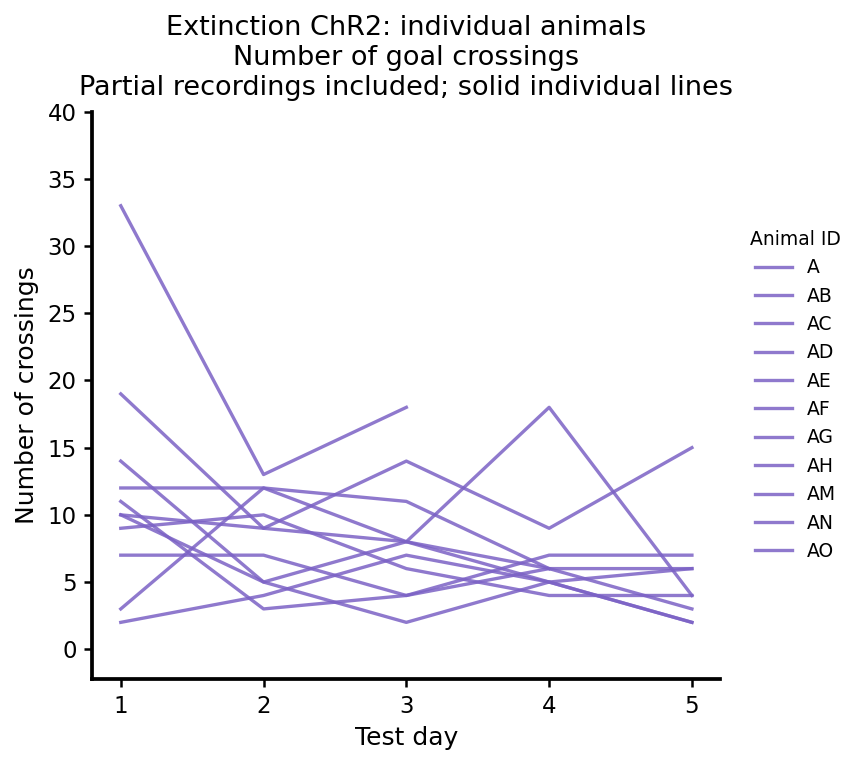


Individual ChR2 lines: Forgetting
Metric: n_crossings
Animals with any remaining test day are included.
Saved editable SVG: /Users/stella/Desktop/PhD/thesis/figures/forgetting_extinction_individual_crossings_n_crossings_forgetting_chr2.svg


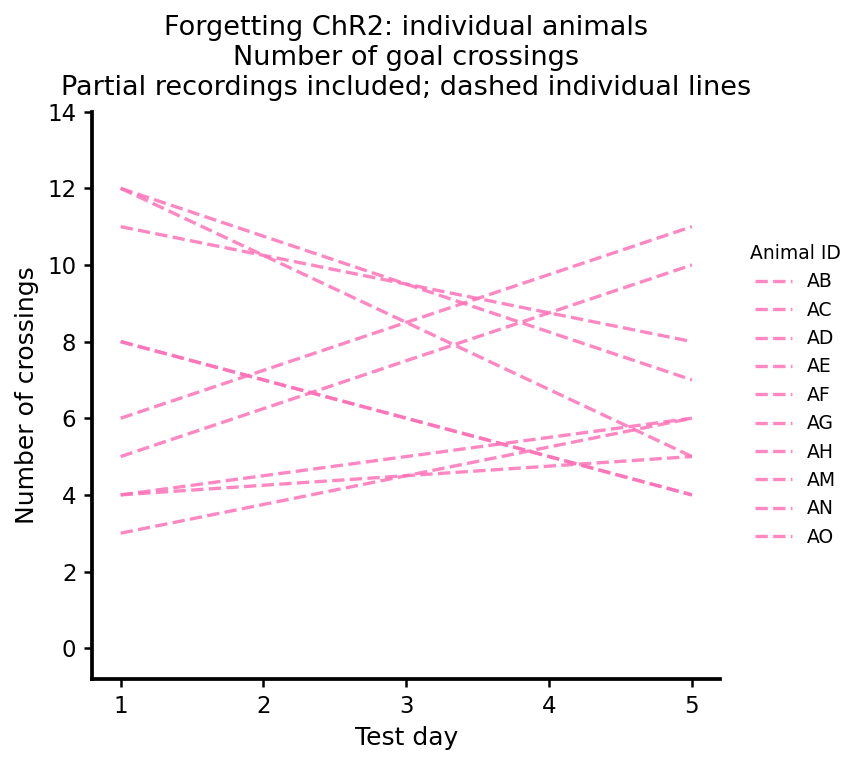


Animals included in aggregate line plot:
  Forgetting - ChR2: n = 10, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Extinction - ChR2: n = 9, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AM', 'AN', 'AO']
Saved editable SVG: /Users/stella/Desktop/PhD/thesis/figures/forgetting_extinction_line_chr2_only_crossings_n_crossings.svg


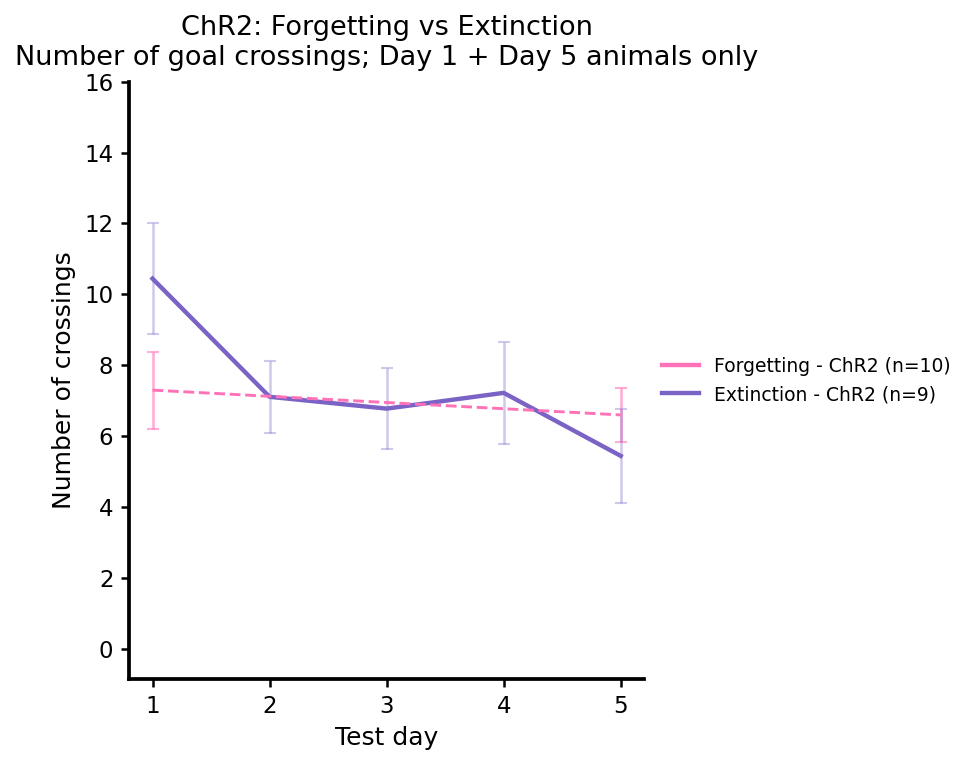


Test day 1: paired ChR2 Extinction vs Forgetting
Number of goal crossings; Day 1 + Day 5 animals only
Metric: n_crossings
Y-axis label: Number of crossings
Round-specific exclusion applied: {}
Aggregate cohort description: Day 1 + Day 5 animals only
  Ext ChR2: n = 9, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AM', 'AN', 'AO'], values = [10. 19.  7.  2. 14. 11. 12.  9. 10.]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AM', 'AN', 'AO'], values = [12. 12.  4.  8.  4.  6. 11.  8.  3.]

Statistical tests:
  Wilcoxon Ext ChR2 vs Forg ChR2: n=9, mean=10.444 vs 7.556, median=10.000 vs 8.000, W=9.000, p=0.12891
Saved editable SVG: /Users/stella/Desktop/PhD/thesis/figures/forgetting_extinction_paired_ext_vs_forg_day1_crossings_n_crossings.svg


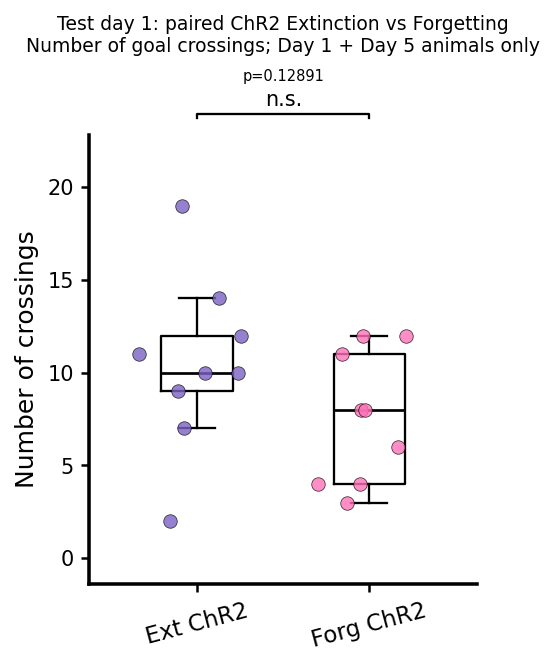


Test day 5: paired ChR2 Extinction vs Forgetting
Number of goal crossings; Day 1 + Day 5 animals only
Metric: n_crossings
Y-axis label: Number of crossings
Round-specific exclusion applied: {}
Aggregate cohort description: Day 1 + Day 5 animals only
  Ext ChR2: n = 9, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AM', 'AN', 'AO'], values = [ 4. 15.  7.  2.  2.  6.  6.  4.  3.]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AM', 'AN', 'AO'], values = [ 7.  5.  6.  4.  5. 11.  8.  4.  6.]

Statistical tests:
  Wilcoxon Ext ChR2 vs Forg ChR2: n=9, mean=5.444 vs 6.222, median=4.000 vs 6.000, W=9.000, p=0.20478
Saved editable SVG: /Users/stella/Desktop/PhD/thesis/figures/forgetting_extinction_paired_ext_vs_forg_day5_crossings_n_crossings.svg


/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


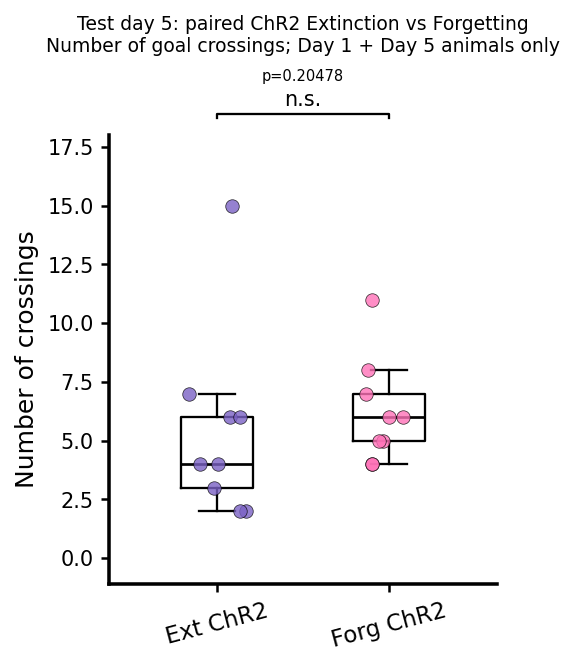


Extinction ChR2: Day 1 vs Day 5
Number of goal crossings
Metric: n_crossings
Y-axis label: Number of crossings
Round-specific exclusion applied: {}
Aggregate cohort description: Day 1 + Day 5 animals only
  Day 1: n = 9, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AM', 'AN', 'AO'], values = [10. 19.  7.  2. 14. 11. 12.  9. 10.]
  Day 5: n = 9, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AM', 'AN', 'AO'], values = [ 4. 15.  7.  2.  2.  6.  6.  4.  3.]

Statistical tests:
  Wilcoxon Day 1 vs Day 5: n=9, mean=10.444 vs 5.444, median=10.000 vs 4.000, W=0.000, p=0.01755


/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


Saved editable SVG: /Users/stella/Desktop/PhD/thesis/figures/forgetting_extinction_paired_day1_vs_day5_extinction_crossings_n_crossings.svg


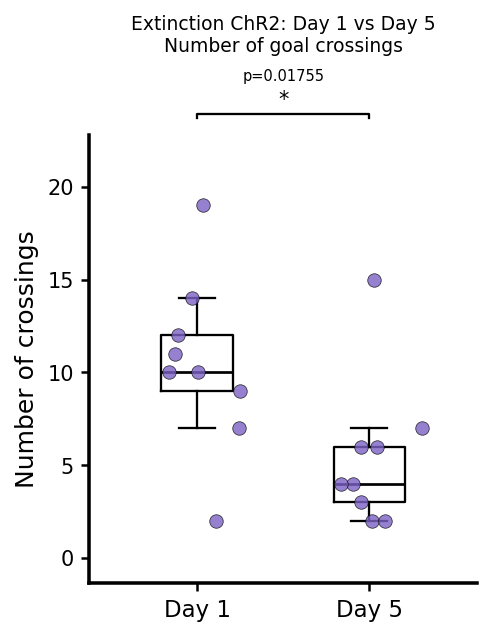


Forgetting ChR2: Day 1 vs Day 5
Number of goal crossings
Metric: n_crossings
Y-axis label: Number of crossings
Round-specific exclusion applied: {}
Aggregate cohort description: Day 1 + Day 5 animals only
  Day 1: n = 10, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values = [12. 12.  4.  8.  4.  6.  5. 11.  8.  3.]
  Day 5: n = 10, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values = [ 7.  5.  6.  4.  5. 11. 10.  8.  4.  6.]

Statistical tests:
  Wilcoxon Day 1 vs Day 5: n=10, mean=7.300 vs 6.600, median=7.000 vs 6.000, W=22.500, p=0.69531
Saved editable SVG: /Users/stella/Desktop/PhD/thesis/figures/forgetting_extinction_paired_day1_vs_day5_forgetting_crossings_n_crossings.svg


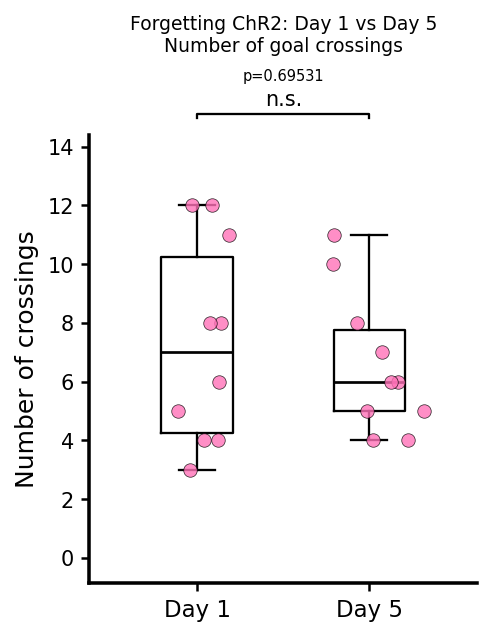

In [19]:
# Forgetting / Extinction TEST trials across test days 1-5
#
# Produces:
#   1) Aggregate mean +/- SEM line plot
#      - ChR2 by default
#      - optional eYFP_ChR2 controls
#   2) Individual ChR2 extinction / forgetting lines
#   3) Optional ordinary day boxplots
#   4) Paired ChR2 Extinction vs Forgetting boxplots, Days 1 and 5
#   5) Paired Day 1 vs Day 5 boxplots within ChR2 Extinction/Forgotten groups
#
# Notes:
#   - plots metadata['n_crossings']
#   - p-value brackets are drawn on a separate annotation axis for boxplots,
#     so they do not stretch the data y-axis
#   - SVG text remains editable in Inkscape
# ============================================================

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, wilcoxon

# ============================================================
# OPTIONS
# ============================================================

# Set True to include eYFP_ChR2 extinction and forgetting in the aggregate line plot.
INCLUDE_EYFP_CHR2_IN_LINE_PLOT = False

ENDPOINT_CONTROL_GENOTYPE = 'eYFP_ChR2'
INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS = False

EXCLUDE_ID = []
EXCLUDE_SUBS = []

EXCLUDE_TEST_ID_BY_ROUND = {
    # 'AH': [2],
}

EXCLUDE_TEST_SUB_BY_ROUND = {
    # 25: [1],
}

PRINT_ROUND_ASSIGNMENT_TABLE = True
PRINT_SELECTIVE_TEST_ROUND_EXCLUSIONS = True

VALID_TEST_TYPES = ['extinction', 'forgetting']
VALID_TEST_ORDERS = ['ef', 'fe', 'ee', 'ff']
ORDER_CODE_TO_TEST_TYPE = {'e': 'extinction', 'f': 'forgetting'}

max_day = 5
day_values = np.arange(1, max_day + 1)

GROUP_PLOT_COHORT_MODE = 'day1_day5'
# GROUP_PLOT_COHORT_MODE = 'all'
# GROUP_PLOT_COHORT_MODE = 'all_five'

VALID_COHORT_MODES = ['all', 'day1_day5', 'all_five']

SEM_STYLE = 'bar'
# SEM_STYLE = 'shaded' or 'bar'

RUN_INDIVIDUAL_CHR2_LINE_PLOTS = True
INDIVIDUAL_CHR2_TEST_TYPES = ['extinction', 'forgetting']

RUN_ORDINARY_DAY_BOXPLOTS = False
BOXPLOT_DAYS = [1, 2, 3, 4, 5]
MATCH_DAY1_DAY5_BOXPLOT_YAXIS = True

RUN_PAIRED_CHR2_EXT_VS_FORG_BOXPLOTS = True
PAIRED_CHR2_DAYS = [1, 5]

RUN_DAY1_VS_DAY5_WITHIN_TEST_TYPE_BOXPLOTS = True
DAY1_VS_DAY5_GENOTYPE = 'ChR2'
DAY1_VS_DAY5_TEST_TYPES = ['extinction', 'forgetting']

SHOW_PAIRED_LINES = False
SHOW_ANIMAL_IDS = False

BOX_GROUP_SPACING = 0.72
BOX_WIDTH = 0.3
JITTER = 0.105
DOT_SIZE = 42
DOT_ALPHA = 0.8
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.35

P_ANNOT_Y_START = 0.12
P_ANNOT_Y_STEP = 0.5
P_ANNOT_CAP_HEIGHT = 0.035
P_ANNOT_STAR_OFFSET = 0.04
P_ANNOT_P_OFFSET = 0.28
P_ANNOT_LINEWIDTH = 1.1
P_ANNOT_STAR_FONTSIZE = 10
P_ANNOT_P_FONTSIZE = 7

Y_BOTTOM_PAD_FRAC = 0.06
P_DECIMALS = 5

LINE_FIGSIZE = (8.0, 5.2)
INDIVIDUAL_FIGSIZE = (7.0, 5.2)
BOX_FIG_HEIGHT = 5.2

INDIVIDUAL_LINEWIDTH = 1.6
INDIVIDUAL_ALPHA = 0.85
INDIVIDUAL_SHOW_LEGEND = True

YMAX_BY_METRIC = {}
Y_TICK_STEP_BY_METRIC = {}

SAVE_FIGURES = True
SAVE_DIR = Path('/Users/stella/Desktop/PhD/thesis/figures')
SAVE_SVG = True
SAVE_HIGH_DPI_PNG = False
FIG_DPI = 600
SHOW_FIGURES = True

np.random.seed(1)

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['path.simplify'] = False
plt.rcParams['savefig.dpi'] = FIG_DPI
plt.rcParams['figure.dpi'] = 150

if SAVE_FIGURES:
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

if GROUP_PLOT_COHORT_MODE not in VALID_COHORT_MODES:
    raise ValueError(f"GROUP_PLOT_COHORT_MODE must be one of {VALID_COHORT_MODES}")

METRICS_TO_PLOT = ['n_crossings']
METRIC_LABEL = {
    'n_crossings': 'Number of crossings',
}
METRIC_TITLE = {
    'n_crossings': 'Number of goal crossings',
}

METRIC_SCALE = {metric: 1.0 for metric in METRICS_TO_PLOT}

LINE_GENOTYPES = ['ChR2']
if INCLUDE_EYFP_CHR2_IN_LINE_PLOT:
    LINE_GENOTYPES.append('eYFP_ChR2')
LINE_GENOTYPES = sorted(set(LINE_GENOTYPES))

GENOTYPES_TO_LOAD = list(LINE_GENOTYPES)
if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS:
    GENOTYPES_TO_LOAD.append(ENDPOINT_CONTROL_GENOTYPE)
GENOTYPES_TO_LOAD = sorted(set(GENOTYPES_TO_LOAD))

COL_FORG_CHR2 = '#FF72B8'
COL_EXT_CHR2 = '#7b62c5ff'
COL_FORG_YFP = '#65a8deff'
COL_EXT_YFP = '#76787EC1'

DISPLAY_NAME = {
    'ChR2': 'ChR2',
    'eYFP_ChR2': 'eYFP',
}

GROUP_STYLE = {
    ('ChR2', 'forgetting'): {
        'label': 'Forg ChR2',
        'long_label': 'Forgetting - ChR2',
        'color': COL_FORG_CHR2,
    },
    ('ChR2', 'extinction'): {
        'label': 'Ext ChR2',
        'long_label': 'Extinction - ChR2',
        'color': COL_EXT_CHR2,
    },
    ('eYFP_ChR2', 'forgetting'): {
        'label': 'Forg eYFP',
        'long_label': 'Forgetting - eYFP',
        'color': COL_FORG_YFP,
    },
    ('eYFP_ChR2', 'extinction'): {
        'label': 'Ext eYFP',
        'long_label': 'Extinction - eYFP',
        'color': COL_EXT_YFP,
    },
}

# ============================================================
# Helpers
# ============================================================

def safe_filename(text):
    text = re.sub(r'[^A-Za-z0-9._-]+', '_', str(text))
    return text.strip('_')


def save_figure(fig, stem):
    if not SAVE_FIGURES:
        return

    stem = safe_filename(stem)

    if SAVE_SVG:
        svg_path = SAVE_DIR / f'{stem}.svg'
        fig.savefig(svg_path, format='svg', bbox_inches='tight')
        print(f"Saved editable SVG: {svg_path}")

    if SAVE_HIGH_DPI_PNG:
        png_path = SAVE_DIR / f'{stem}.png'
        fig.savefig(png_path, format='png', dpi=FIG_DPI, bbox_inches='tight')
        print(f"Saved high-DPI PNG: {png_path}")


def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return 'NaN'
    return f'{p:.{decimals}f}'


def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def style_nature(ax, linewidth=1.8):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)


def get_animal_id(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def test_type_display_name(test_type):
    if test_type == 'extinction':
        return 'Extinction'
    if test_type == 'forgetting':
        return 'Forgetting'
    return str(test_type)


def cohort_description():
    if GROUP_PLOT_COHORT_MODE == 'all':
        return 'All available animals'
    if GROUP_PLOT_COHORT_MODE == 'day1_day5':
        return 'Day 1 + Day 5 animals only'
    if GROUP_PLOT_COHORT_MODE == 'all_five':
        return 'Animals with all Days 1-5 only'
    return GROUP_PLOT_COHORT_MODE


def empty_day_value_dataframe():
    return pd.DataFrame(columns=['sub', 'id', 'genotype', 'test_type', 'day', 'value'])


def mean_and_sem(mat):
    if mat is None or mat.size == 0:
        return None, None

    mean = np.full(mat.shape[1], np.nan)
    sem = np.full(mat.shape[1], np.nan)

    for j in range(mat.shape[1]):
        col = mat[:, j]
        valid = np.isfinite(col)
        n = valid.sum()

        if n == 0:
            continue

        mean[j] = col[valid].mean()
        sem[j] = col[valid].std(ddof=1) / np.sqrt(n) if n > 1 else 0.0

    return mean, sem


def run_wilcoxon(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    ok = np.isfinite(a) & np.isfinite(b)
    a = a[ok]
    b = b[ok]

    if len(a) == 0:
        return np.nan, np.nan

    if np.allclose(a, b, equal_nan=False):
        return np.nan, 1.0

    try:
        stat, p = wilcoxon(a, b, alternative='two-sided')
    except ValueError:
        stat, p = np.nan, 1.0

    return stat, p


def apply_y_axis(ax, all_vals, value_col, top_pad=0.18):
    vals = np.asarray(all_vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        y_top = 1.0
    else:
        y_top = np.nanmax(vals)
        if not np.isfinite(y_top) or y_top <= 0:
            y_top = 1.0
        y_top *= 1.0 + top_pad

    manual_ymax = YMAX_BY_METRIC.get(value_col, None)
    if manual_ymax is not None:
        y_top = float(manual_ymax)

    y_bottom = -Y_BOTTOM_PAD_FRAC * y_top
    ax.set_ylim(y_bottom, y_top)

    tick_step = Y_TICK_STEP_BY_METRIC.get(value_col, None)
    if tick_step is not None:
        ax.set_yticks(np.arange(0, y_top + tick_step, tick_step))
    else:
        ticks = ax.get_yticks()
        ticks = ticks[ticks >= 0]
        if len(ticks) == 0 or ticks[0] != 0:
            ticks = np.insert(ticks, 0, 0)
        ax.set_yticks(ticks)


def get_box_y_top(vals_groups, value_col):
    vals = []
    for group_vals in vals_groups:
        group_vals = np.asarray(group_vals, dtype=float)
        vals.extend(group_vals[np.isfinite(group_vals)])

    vals = np.asarray(vals, dtype=float)
    if len(vals) == 0:
        y_top = 1.0
    else:
        y_top = np.nanmax(vals)
        if not np.isfinite(y_top) or y_top <= 0:
            y_top = 1.0
        y_top *= 1.20

    manual_ymax = YMAX_BY_METRIC.get(value_col, None)
    if manual_ymax is not None:
        y_top = float(manual_ymax)

    return y_top


def draw_p_value_on_annotation_axis(ann_ax, x1, x2, y, p):
    ann_ax.plot(
        [x1, x1, x2, x2],
        [y - P_ANNOT_CAP_HEIGHT, y, y, y - P_ANNOT_CAP_HEIGHT],
        color='black',
        linewidth=P_ANNOT_LINEWIDTH,
        clip_on=False,
        zorder=10
    )

    ann_ax.text(
        (x1 + x2) / 2.0,
        y + P_ANNOT_STAR_OFFSET,
        p_to_stars(p),
        ha='center',
        va='bottom',
        fontsize=P_ANNOT_STAR_FONTSIZE,
        clip_on=False,
        zorder=11
    )

    ann_ax.text(
        (x1 + x2) / 2.0,
        y + P_ANNOT_P_OFFSET,
        f'p={format_p(p)}',
        ha='center',
        va='bottom',
        fontsize=P_ANNOT_P_FONTSIZE,
        clip_on=False,
        zorder=11
    )


def make_boxplot_figure(n_groups, n_comparisons, fig_width=None):
    if fig_width is None:
        fig_width = max(3.4, 0.72 * n_groups + 1.5)

    if n_comparisons > 0:
        annot_ymax = (
            P_ANNOT_Y_START +
            max(n_comparisons - 1, 0) * P_ANNOT_Y_STEP +
            P_ANNOT_P_OFFSET +
            0.12
        )
        annot_ymax = max(1.0, annot_ymax)

        annot_height = 0.42 + 0.34 * max(n_comparisons, 1)
        annot_height = min(2.8, annot_height)

        fig, (ann_ax, ax) = plt.subplots(
            2,
            1,
            figsize=(fig_width, BOX_FIG_HEIGHT + annot_height),
            gridspec_kw={'height_ratios': [annot_height, 3.2]},
            sharex=True
        )
        ann_ax.set_axis_off()
    else:
        fig, ax = plt.subplots(figsize=(fig_width, BOX_FIG_HEIGHT))
        ann_ax = None
        annot_ymax = None

    return fig, ann_ax, ax, annot_ymax


def render_boxplot(
    box_groups,
    comparisons,
    title,
    ylabel,
    value_col,
    stem,
    paired_lines=None,
    x_tick_rotation=15
):
    vals_groups = [g['df']['value'].values.astype(float) for g in box_groups]
    positions = np.arange(len(box_groups)) * BOX_GROUP_SPACING

    stats_to_draw = []
    stats_print_rows = []

    for g1, g2, test_kind in comparisons:
        lookup = {g['key']: g for g in box_groups}
        vals1 = lookup[g1]['df']['value'].values.astype(float)
        vals2 = lookup[g2]['df']['value'].values.astype(float)
        vals1 = vals1[np.isfinite(vals1)]
        vals2 = vals2[np.isfinite(vals2)]

        if len(vals1) > 0 and len(vals2) > 0:
            if test_kind == 'wilcoxon':
                stat, p = run_wilcoxon(vals1, vals2)
                extra = np.nan
            else:
                stat, p = mannwhitneyu(vals1, vals2, alternative='two-sided')
                extra = (2 * stat) / (len(vals1) * len(vals2)) - 1
        else:
            stat, p, extra = np.nan, np.nan, np.nan

        stats_print_rows.append((lookup[g1]['label'], lookup[g2]['label'], vals1, vals2, stat, p, extra, test_kind))

        if np.isfinite(p):
            stats_to_draw.append((list(lookup).index(g1), list(lookup).index(g2), p))

    print("\n============================================================")
    print(title)
    print("Metric:", value_col)
    print("Y-axis label:", ylabel)
    print("Round-specific exclusion applied:", EXCLUDE_TEST_ID_BY_ROUND)
    print("Aggregate cohort description:", cohort_description())

    for g in box_groups:
        vals = g['df']['value'].values.astype(float) if len(g['df']) > 0 else np.array([])
        print(f"  {g['label']}: n = {len(g['df'])}, ids = {list(g['df']['id'])}, values = {np.round(vals, 4)}")

    print("\nStatistical tests:")
    if len(stats_print_rows) == 0:
        print("  No comparison specified.")

    for label1, label2, vals1, vals2, stat, p, extra, test_kind in stats_print_rows:
        if not np.isfinite(p):
            print(f"  {label1} vs {label2}: p = NaN")
            continue

        if test_kind == 'wilcoxon':
            print(
                f"  Wilcoxon {label1} vs {label2}: "
                f"n={len(vals1)}, mean={np.nanmean(vals1):.3f} vs {np.nanmean(vals2):.3f}, "
                f"median={np.nanmedian(vals1):.3f} vs {np.nanmedian(vals2):.3f}, "
                f"W={stat:.3f}, p={format_p(p)}"
            )
        else:
            print(
                f"  Mann-Whitney {label1} vs {label2}: "
                f"n={len(vals1)} vs {len(vals2)}, "
                f"mean={np.nanmean(vals1):.3f} vs {np.nanmean(vals2):.3f}, "
                f"median={np.nanmedian(vals1):.3f} vs {np.nanmedian(vals2):.3f}, "
                f"U={stat:.1f}, rank-biserial={extra:.3f}, p={format_p(p)}"
            )

    fig, ann_ax, ax, annot_ymax = make_boxplot_figure(
        n_groups=len(box_groups),
        n_comparisons=len(stats_to_draw)
    )

    ax.boxplot(
        vals_groups,
        positions=positions,
        widths=BOX_WIDTH,
        patch_artist=False,
        showfliers=False,
        medianprops={'linewidth': 1.3, 'color': 'black'},
        boxprops={'linewidth': 1.1, 'color': 'black'},
        whiskerprops={'linewidth': 1.1, 'color': 'black'},
        capprops={'linewidth': 1.1, 'color': 'black'}
    )

    if paired_lines is not None and SHOW_PAIRED_LINES:
        for left_key, right_key, pair_df, left_col, right_col in paired_lines:
            key_to_pos = {g['key']: positions[i] for i, g in enumerate(box_groups)}
            x1 = key_to_pos[left_key]
            x2 = key_to_pos[right_key]
            for _, row in pair_df.iterrows():
                ax.plot(
                    [x1, x2],
                    [row[left_col], row[right_col]],
                    '-',
                    color='0.65',
                    linewidth=0.8,
                    alpha=0.55,
                    zorder=1
                )

    for i, g in enumerate(box_groups):
        df_g = g['df'].copy()
        if len(df_g) == 0:
            continue

        vals = df_g['value'].values.astype(float)
        finite = np.isfinite(vals)
        vals = vals[finite]
        animal_ids = df_g.loc[finite, 'id'].values

        if len(vals) == 0:
            continue

        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=g['color'],
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            alpha=DOT_ALPHA,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, animal_ids):
                ax.text(
                    xi + 0.025,
                    yi,
                    str(animal_id),
                    fontsize=6.5,
                    color=g['color'],
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    if ann_ax is not None:
        ann_ax.set_xlim(positions[0] - 0.45, positions[-1] + 0.45)
        ann_ax.set_ylim(0, annot_ymax)

        for i, (x1_idx, x2_idx, p) in enumerate(stats_to_draw):
            y = P_ANNOT_Y_START + i * P_ANNOT_Y_STEP
            draw_p_value_on_annotation_axis(
                ann_ax,
                positions[x1_idx],
                positions[x2_idx],
                y,
                p
            )

    ax.set_xticks(positions)
    ax.set_xticklabels([g['label'] for g in box_groups], fontsize=11, rotation=x_tick_rotation)
    ax.set_xlim(positions[0] - 0.45, positions[-1] + 0.45)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=9, pad=40)

    y_top = get_box_y_top(vals_groups, value_col)
    apply_y_axis(ax, np.r_[tuple(vals_groups)] if len(vals_groups) > 0 else [], value_col, top_pad=0.20)
    ax.set_ylim(-Y_BOTTOM_PAD_FRAC * y_top, y_top)

    style_nature(ax, linewidth=1.7)

    if ann_ax is not None:
        fig.subplots_adjust(left=0.22, right=0.98, bottom=0.17, top=0.80, hspace=0.03)
    else:
        fig.subplots_adjust(left=0.22, right=0.98, bottom=0.17, top=0.88)

    save_figure(fig, stem)

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


# ============================================================
# Round Assignment
# ============================================================

def expected_test_type_from_order(test_order, test_round):
    if not isinstance(test_order, str):
        return pd.NA

    order = test_order.lower().strip()

    if order not in VALID_TEST_ORDERS or test_round not in [1, 2]:
        return pd.NA

    return ORDER_CODE_TO_TEST_TYPE.get(order[test_round - 1], pd.NA)


def add_test_round(meta_test_df):
    meta_test_df = meta_test_df.copy()

    meta_test_df['test_type_norm'] = meta_test_df['test_type'].astype(str).str.lower().str.strip()
    meta_test_df['test_order_norm'] = meta_test_df['test_order'].astype(str).str.lower().str.strip()
    meta_test_df['test_round'] = pd.Series(pd.NA, index=meta_test_df.index, dtype='Int64')
    meta_test_df['expected_test_type'] = pd.Series(pd.NA, index=meta_test_df.index, dtype='object')
    meta_test_df['test_order_match'] = False

    grouping_cols = ['genotype', 'sub'] if 'genotype' in meta_test_df.columns else ['sub']

    for group_key, ms in meta_test_df.groupby(grouping_cols, dropna=False, sort=True):
        ms = ms.copy()

        orders = [o for o in ms['test_order_norm'].dropna().unique() if o in VALID_TEST_ORDERS]

        if len(orders) == 0:
            print(f"WARNING: group {group_key} has no valid test_order.")
            continue

        if len(orders) > 1:
            print(f"WARNING: group {group_key} has multiple valid test_order values: {orders}. Using {orders[0]}.")

        order = str(orders[0])

        if order[0] != order[1]:
            round1_type = expected_test_type_from_order(order, 1)
            round2_type = expected_test_type_from_order(order, 2)

            idx_round1 = ms.index[ms['test_type_norm'] == round1_type]
            idx_round2 = ms.index[ms['test_type_norm'] == round2_type]

            meta_test_df.loc[idx_round1, 'test_round'] = 1
            meta_test_df.loc[idx_round2, 'test_round'] = 2

        else:
            session_table = (
                ms[['ses', 'trial_type_day', 'test_type_norm']]
                .drop_duplicates()
                .sort_values(['ses', 'trial_type_day'])
                .reset_index(drop=True)
            )

            current_round = 1
            previous_day = None
            round_by_session = {}

            for _, row in session_table.iterrows():
                this_ses = row['ses']
                this_day = int(row['trial_type_day'])

                if previous_day is not None and current_round == 1 and this_day < previous_day:
                    current_round = 2

                round_by_session[this_ses] = current_round
                previous_day = this_day

            for idx in ms.index:
                this_ses = meta_test_df.at[idx, 'ses']
                if this_ses in round_by_session:
                    meta_test_df.at[idx, 'test_round'] = round_by_session[this_ses]

            assigned_rounds = meta_test_df.loc[ms.index, 'test_round'].dropna().astype(int).unique()
            if 2 not in assigned_rounds:
                print(f"WARNING: group {group_key}, test_order='{order}': no Round 2 day reset was detected.")

        for idx in ms.index:
            assigned_round = meta_test_df.at[idx, 'test_round']

            if pd.isna(assigned_round):
                continue

            assigned_round = int(assigned_round)
            expected_type = expected_test_type_from_order(order, assigned_round)

            meta_test_df.at[idx, 'expected_test_type'] = expected_type
            meta_test_df.at[idx, 'test_order_match'] = bool(
                meta_test_df.at[idx, 'test_type_norm'] == expected_type
            )

    return meta_test_df


def apply_selective_test_round_exclusions(meta_test_df):
    meta_test_df = meta_test_df.copy()
    exclusion_mask = pd.Series(False, index=meta_test_df.index)

    if len(EXCLUDE_TEST_ID_BY_ROUND) > 0:
        if 'id' not in meta_test_df.columns:
            raise KeyError("EXCLUDE_TEST_ID_BY_ROUND was specified, but metadata has no 'id' column.")

        normalised_ids = meta_test_df['id'].astype(str).str.strip().str.upper()

        for animal_id, rounds_to_remove in EXCLUDE_TEST_ID_BY_ROUND.items():
            target = str(animal_id).strip().upper()
            exclusion_mask = exclusion_mask | (
                (normalised_ids == target) &
                (meta_test_df['test_round'].isin(rounds_to_remove))
            )

    if len(EXCLUDE_TEST_SUB_BY_ROUND) > 0:
        normalised_subs = meta_test_df['sub'].astype(str).str.strip()

        for sub, rounds_to_remove in EXCLUDE_TEST_SUB_BY_ROUND.items():
            exclusion_mask = exclusion_mask | (
                (normalised_subs == str(sub).strip()) &
                (meta_test_df['test_round'].isin(rounds_to_remove))
            )

    removed_rows = meta_test_df[exclusion_mask].copy()
    retained_rows = meta_test_df[~exclusion_mask].copy()

    if PRINT_SELECTIVE_TEST_ROUND_EXCLUSIONS:
        print("\n============================================================")
        print("SELECTIVE TEST-ROUND EXCLUSIONS")
        print("============================================================")
        print("ID-based exclusions:", EXCLUDE_TEST_ID_BY_ROUND)
        print("Subject-based exclusions:", EXCLUDE_TEST_SUB_BY_ROUND)
        print("Number of structural TEST rows removed:", len(removed_rows))

    return retained_rows, removed_rows


# ============================================================
# Prepare Structural TEST Dataset
# ============================================================

required_structure_cols = [
    'trial_type',
    'genotype',
    'trial_type_day',
    'sub',
    'test_type',
    'test_order',
    'ses',
]

if len(EXCLUDE_TEST_ID_BY_ROUND) > 0:
    required_structure_cols.append('id')

missing_structure_cols = [c for c in required_structure_cols if c not in metadata.columns]

if len(missing_structure_cols) > 0:
    raise KeyError(f"Missing columns required for round-specific exclusion: {missing_structure_cols}")

meta_T_structure = metadata[
    (metadata['trial_type'] == 'T') &
    (metadata['genotype'].isin(GENOTYPES_TO_LOAD)) &
    (
        metadata['test_type']
        .astype(str)
        .str.lower()
        .str.strip()
        .isin(VALID_TEST_TYPES)
    ) &
    (metadata['trial_type_day'].isin(day_values))
].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_T_structure.columns:
    meta_T_structure = meta_T_structure[
        ~meta_T_structure['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_T_structure = meta_T_structure[
        ~meta_T_structure['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

if len(meta_T_structure) == 0:
    raise ValueError("No TEST rows remain before round assignment.")

meta_T_structure = add_test_round(meta_T_structure)

if PRINT_ROUND_ASSIGNMENT_TABLE:
    print_cols = [
        c for c in [
            'sub',
            'id',
            'genotype',
            'test_order',
            'test_type_norm',
            'test_round',
            'ses',
            'trial_type_day',
            'expected_test_type',
            'test_order_match',
        ]
        if c in meta_T_structure.columns
    ]

    print("\n============================================================")
    print("STRUCTURAL ROUND ASSIGNMENT TABLE BEFORE EXCLUSION")
    print("============================================================")
    print(
        meta_T_structure[print_cols]
        .drop_duplicates()
        .sort_values([c for c in ['genotype', 'sub', 'ses', 'trial_type_day'] if c in print_cols])
        .reset_index(drop=True)
    )

meta_T_structure, removed_round_specific_rows = apply_selective_test_round_exclusions(meta_T_structure)

if len(meta_T_structure) == 0:
    raise ValueError("No TEST rows remain after selective round-specific exclusion.")


# ============================================================
# Data Selection Helpers
# ============================================================

def get_group_subject_summary(meta_df, genotype, test_type, value_col):
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df['test_type_norm'] == test_type) &
        (meta_df['trial_type_day'].isin(day_values)) &
        (meta_df[value_col].notna()) &
        (np.isfinite(meta_df[value_col]))
    ].copy()

    summary_rows = []

    for sub in sorted(m['sub'].unique()):
        ms = m[m['sub'] == sub].copy()

        per_day = (
            ms.groupby('trial_type_day', as_index=True)[value_col]
            .mean()
            .sort_index()
        )

        finite_by_day = {
            d: bool(d in per_day.index and np.isfinite(per_day.loc[d]))
            for d in day_values
        }

        has_any_day = any(finite_by_day.values())
        has_day1_day5 = finite_by_day[1] and finite_by_day[5]
        has_all_five = all(finite_by_day[d] for d in day_values)

        if GROUP_PLOT_COHORT_MODE == 'all':
            included = has_any_day
        elif GROUP_PLOT_COHORT_MODE == 'day1_day5':
            included = has_day1_day5
        elif GROUP_PLOT_COHORT_MODE == 'all_five':
            included = has_all_five
        else:
            raise ValueError(f"Unknown GROUP_PLOT_COHORT_MODE: {GROUP_PLOT_COHORT_MODE}")

        summary_rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'genotype': genotype,
            'test_type': test_type,
            'has_day1': finite_by_day[1],
            'has_day2': finite_by_day[2],
            'has_day3': finite_by_day[3],
            'has_day4': finite_by_day[4],
            'has_day5': finite_by_day[5],
            'has_day1_day5': has_day1_day5,
            'has_all_five': has_all_five,
            'included_group_plots': included,
        })

    return pd.DataFrame(summary_rows)


def select_group_plot_data(meta_df, value_col):
    kept_parts = []
    summary_parts = []

    for genotype in GENOTYPES_TO_LOAD:
        for test_type in ['forgetting', 'extinction']:
            summary = get_group_subject_summary(meta_df, genotype, test_type, value_col)

            if len(summary) == 0:
                continue

            summary_parts.append(summary)
            included_subs = summary.loc[summary['included_group_plots'], 'sub'].tolist()

            part = meta_df[
                (meta_df['genotype'] == genotype) &
                (meta_df['test_type_norm'] == test_type) &
                (meta_df['sub'].isin(included_subs))
            ].copy()

            if len(part) > 0:
                kept_parts.append(part)

    selected_df = pd.concat(kept_parts, ignore_index=False).copy() if kept_parts else meta_df.iloc[0:0].copy()
    inclusion_summary = pd.concat(summary_parts, ignore_index=True) if summary_parts else pd.DataFrame()

    return selected_df, inclusion_summary


def print_day_sample_sizes(meta_df, value_col, heading):
    print(f"\n{heading}")

    for genotype in GENOTYPES_TO_LOAD:
        for test_type in ['forgetting', 'extinction']:
            m = meta_df[
                (meta_df['genotype'] == genotype) &
                (meta_df['test_type_norm'] == test_type)
            ].copy()

            n_by_day = {}

            for d in day_values:
                md = m[
                    (m['trial_type_day'] == d) &
                    (m[value_col].notna()) &
                    (np.isfinite(m[value_col]))
                ].copy()

                n_by_day[d] = int(md['sub'].nunique())

            print(
                f"  {test_type_display_name(test_type)} "
                f"{DISPLAY_NAME.get(genotype, genotype)}: {n_by_day}"
            )


def build_subject_matrix(meta_group, value_col):
    performance_mat = []
    subjects = []
    animal_ids = []
    scale = METRIC_SCALE.get(value_col, 1.0)

    for sub in sorted(meta_group['sub'].unique()):
        ms = meta_group[meta_group['sub'] == sub].copy()

        mean_d = (
            ms.groupby('trial_type_day', as_index=True)[value_col]
            .mean()
            .sort_index()
        )

        vec = np.full(max_day, np.nan)

        for i, d in enumerate(day_values):
            if d in mean_d.index and np.isfinite(mean_d.loc[d]):
                vec[i] = mean_d.loc[d] * scale

        if np.isnan(vec).all():
            continue

        performance_mat.append(vec)
        subjects.append(sub)
        animal_ids.append(get_animal_id(ms, sub))

    if len(performance_mat) == 0:
        return None, [], []

    return np.vstack(performance_mat), subjects, animal_ids


def day_values_from_metadata(meta_df, genotype, test_type, day, value_col):
    output_cols = ['sub', 'id', 'genotype', 'test_type', 'day', 'value']
    scale = METRIC_SCALE.get(value_col, 1.0)

    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df['test_type_norm'] == test_type) &
        (meta_df['trial_type_day'] == day) &
        (meta_df[value_col].notna()) &
        (np.isfinite(meta_df[value_col]))
    ].copy()

    rows = []

    for sub in sorted(m['sub'].unique()):
        ms = m[m['sub'] == sub].copy()
        value = ms[value_col].mean() * scale

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'genotype': genotype,
            'test_type': test_type,
            'day': day,
            'value': float(value),
        })

    return pd.DataFrame(rows, columns=output_cols)


def paired_ext_vs_forg_chr2_df(meta_df, test_day, value_col):
    df_ext = day_values_from_metadata(
        meta_df=meta_df,
        genotype='ChR2',
        test_type='extinction',
        day=test_day,
        value_col=value_col
    ).rename(columns={'value': 'ext_value', 'id': 'ext_id'})

    df_forg = day_values_from_metadata(
        meta_df=meta_df,
        genotype='ChR2',
        test_type='forgetting',
        day=test_day,
        value_col=value_col
    ).rename(columns={'value': 'forg_value', 'id': 'forg_id'})

    if len(df_ext) == 0 or len(df_forg) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'ext_value', 'forg_value'])

    paired = df_ext[['sub', 'ext_id', 'ext_value']].merge(
        df_forg[['sub', 'forg_id', 'forg_value']],
        on='sub',
        how='inner'
    )

    paired['id'] = paired['ext_id'].fillna(paired['forg_id'])
    paired = paired[
        paired['ext_value'].notna() &
        paired['forg_value'].notna() &
        np.isfinite(paired['ext_value']) &
        np.isfinite(paired['forg_value'])
    ].copy()

    return paired[['sub', 'id', 'ext_value', 'forg_value']]


def paired_day1_vs_day5_df(meta_df, genotype, test_type, value_col):
    df_day1 = day_values_from_metadata(
        meta_df=meta_df,
        genotype=genotype,
        test_type=test_type,
        day=1,
        value_col=value_col
    ).rename(columns={'value': 'day1_value', 'id': 'day1_id'})

    df_day5 = day_values_from_metadata(
        meta_df=meta_df,
        genotype=genotype,
        test_type=test_type,
        day=5,
        value_col=value_col
    ).rename(columns={'value': 'day5_value', 'id': 'day5_id'})

    if len(df_day1) == 0 or len(df_day5) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'day1_value', 'day5_value'])

    paired = df_day1[['sub', 'day1_id', 'day1_value']].merge(
        df_day5[['sub', 'day5_id', 'day5_value']],
        on='sub',
        how='inner'
    )

    paired['id'] = paired['day1_id'].fillna(paired['day5_id'])
    paired = paired[
        paired['day1_value'].notna() &
        paired['day5_value'].notna() &
        np.isfinite(paired['day1_value']) &
        np.isfinite(paired['day5_value'])
    ].copy()

    return paired[['sub', 'id', 'day1_value', 'day5_value']]


# ============================================================
# Plot Helpers
# ============================================================

def plot_group(ax, mat, color, label):
    if mat is None or mat.size == 0:
        return []

    mean_, sem_ = mean_and_sem(mat)

    if mean_ is None:
        return []

    ax.plot(day_values, mean_, '-', color=color, linewidth=2.1, label=label, zorder=3)

    if SEM_STYLE == 'bar':
        ax.errorbar(
            day_values,
            mean_,
            yerr=sem_,
            fmt='none',
            ecolor=color,
            alpha=0.35,
            elinewidth=1.2,
            capsize=3,
            zorder=2
        )
    elif SEM_STYLE == 'shaded':
        ax.fill_between(
            day_values,
            mean_ - sem_,
            mean_ + sem_,
            color=color,
            alpha=0.18,
            linewidth=0,
            zorder=1
        )
    else:
        raise ValueError("SEM_STYLE must be 'bar' or 'shaded'.")

    valid = np.isfinite(mean_) & np.isfinite(sem_)
    plotted_vals = []

    if np.any(valid):
        plotted_vals.extend((mean_ - sem_)[valid])
        plotted_vals.extend((mean_ + sem_)[valid])

    return plotted_vals


def plot_forgetting_trend(ax, mat, color):
    """
    Draw dashed endpoint trend from Day 1 to Day 5 for forgetting.

    If SEM_STYLE == 'shaded', also draw a shaded SEM band connecting
    the Day 1 SEM range to the Day 5 SEM range.
    """
    if mat is None or mat.size == 0:
        return []

    mean_, sem_ = mean_and_sem(mat)

    if mean_ is None or sem_ is None:
        return []

    if (
        not np.isfinite(mean_[0]) or
        not np.isfinite(mean_[-1]) or
        not np.isfinite(sem_[0]) or
        not np.isfinite(sem_[-1])
    ):
        return []

    x = np.array([1, 5])
    y = np.array([mean_[0], mean_[-1]])
    sem = np.array([sem_[0], sem_[-1]])

    if SEM_STYLE == 'shaded':
        ax.fill_between(
            x,
            y - sem,
            y + sem,
            color=color,
            alpha=0.18,
            linewidth=0,
            zorder=1
        )

    elif SEM_STYLE == 'bar':
        ax.errorbar(
            x,
            y,
            yerr=sem,
            fmt='none',
            ecolor=color,
            alpha=0.35,
            elinewidth=1.2,
            capsize=3,
            zorder=2
        )

    ax.plot(
        x,
        y,
        '--',
        color=color,
        alpha=1,
        linewidth=1.4,
        zorder=4
    )

    plotted_vals = []
    plotted_vals.extend(y - sem)
    plotted_vals.extend(y + sem)
    return plotted_vals


def plot_individual_chr2_lines(meta_T_raw, test_type, value_col, value_label, value_title, color):
    m = meta_T_raw[
        (meta_T_raw['genotype'] == 'ChR2') &
        (meta_T_raw['test_type_norm'] == test_type)
    ].copy()

    mat, subs, ids = build_subject_matrix(meta_group=m, value_col=value_col)

    print("\n============================================================")
    print(f"Individual ChR2 lines: {test_type_display_name(test_type)}")
    print("Metric:", value_col)
    print("Animals with any remaining test day are included.")

    if mat is None or len(subs) == 0:
        print("No ChR2 animal data available.")
        return

    fig, ax = plt.subplots(figsize=INDIVIDUAL_FIGSIZE)

    linestyle = '--' if test_type == 'forgetting' else '-'
    all_vals = []

    for i, animal_id in enumerate(ids):
        vals = mat[i, :]
        finite = np.isfinite(vals)

        if not np.any(finite):
            continue

        x_this_animal = day_values[finite]
        y_this_animal = vals[finite]
        all_vals.extend(y_this_animal)

        ax.plot(
            x_this_animal,
            y_this_animal,
            linestyle=linestyle,
            color=color,
            linewidth=INDIVIDUAL_LINEWIDTH,
            alpha=INDIVIDUAL_ALPHA,
            label=str(animal_id),
            zorder=2
        )

    ax.set_xlabel('Test day', fontsize=12)
    ax.set_ylabel(value_label, fontsize=12)
    ax.set_xticks(day_values)
    ax.set_xticklabels([str(d) for d in day_values], fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    line_description = (
        'Partial recordings included; dashed individual lines'
        if test_type == 'forgetting'
        else 'Partial recordings included; solid individual lines'
    )

    ax.set_title(
        f'{test_type_display_name(test_type)} ChR2: individual animals\n'
        f'{value_title}\n'
        f'{line_description}',
        fontsize=13,
        pad=8
    )

    style_nature(ax, linewidth=1.8)
    apply_y_axis(ax, all_vals, value_col, top_pad=0.12)

    if INDIVIDUAL_SHOW_LEGEND:
        ax.legend(
            frameon=False,
            fontsize=9,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            title='Animal ID',
            title_fontsize=9
        )
        plt.tight_layout(rect=[0, 0, 0.84, 1])
    else:
        plt.tight_layout()

    save_figure(fig, f'forgetting_extinction_individual_crossings_{value_col}_{test_type}_chr2')

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


# ============================================================
# Main Plot Function
# ============================================================

def run_plots_for_metric(VALUE_COL):
    VALUE_LABEL = METRIC_LABEL.get(VALUE_COL, VALUE_COL)
    VALUE_TITLE = METRIC_TITLE.get(VALUE_COL, VALUE_COL)

    if VALUE_COL not in meta_T_structure.columns:
        raise KeyError(f"Missing metric column in metadata: {VALUE_COL}")

    meta_T_raw = meta_T_structure[
        meta_T_structure[VALUE_COL].notna() &
        np.isfinite(meta_T_structure[VALUE_COL])
    ].copy()

    print("\n\n############################################################")
    print(f"RUNNING METRIC: {VALUE_COL}")
    print("Mode: crossings")
    print("Metric label:", VALUE_LABEL)
    print("Line plot genotypes:", LINE_GENOTYPES)
    print("Selective round-specific exclusion:", EXCLUDE_TEST_ID_BY_ROUND)
    print("Aggregate cohort mode:", GROUP_PLOT_COHORT_MODE)
    print("Run ordinary day boxplots:", RUN_ORDINARY_DAY_BOXPLOTS)
    print("############################################################")

    if len(meta_T_raw) == 0:
        print("No rows left after metric filtering.")
        return

    print_day_sample_sizes(
        meta_df=meta_T_raw,
        value_col=VALUE_COL,
        heading="Animals with available data by day BEFORE aggregate-cohort restriction:"
    )

    meta_T_group, inclusion_summary = select_group_plot_data(
        meta_df=meta_T_raw,
        value_col=VALUE_COL
    )

    print("\n============================================================")
    print("Aggregate/statistical cohort inclusion")
    print("Metric:", VALUE_COL)
    print("Cohort mode:", GROUP_PLOT_COHORT_MODE)

    if len(inclusion_summary) > 0:
        print(
            inclusion_summary
            .sort_values(['genotype', 'test_type', 'sub'])
            .reset_index(drop=True)
        )

    if len(meta_T_group) == 0:
        print("No rows remain for aggregate/statistical plots.")
        return

    print_day_sample_sizes(
        meta_df=meta_T_group,
        value_col=VALUE_COL,
        heading="Animals contributing by day AFTER aggregate-cohort restriction:"
    )

    if RUN_INDIVIDUAL_CHR2_LINE_PLOTS:
        for test_type in INDIVIDUAL_CHR2_TEST_TYPES:
            color = COL_EXT_CHR2 if test_type == 'extinction' else COL_FORG_CHR2

            plot_individual_chr2_lines(
                meta_T_raw=meta_T_raw,
                test_type=test_type,
                value_col=VALUE_COL,
                value_label=VALUE_LABEL,
                value_title=VALUE_TITLE,
                color=color
            )

    aggregate_group_data = {}

    for genotype in LINE_GENOTYPES:
        for test_type in ['forgetting', 'extinction']:
            m = meta_T_group[
                (meta_T_group['genotype'] == genotype) &
                (meta_T_group['test_type_norm'] == test_type)
            ].copy()

            mat, subs, ids = build_subject_matrix(meta_group=m, value_col=VALUE_COL)

            aggregate_group_data[(genotype, test_type)] = {
                'mat': mat,
                'subs': subs,
                'ids': ids,
            }

    print("\nAnimals included in aggregate line plot:")
    for genotype in LINE_GENOTYPES:
        for test_type in ['forgetting', 'extinction']:
            dat = aggregate_group_data[(genotype, test_type)]
            style = GROUP_STYLE[(genotype, test_type)]
            print(f"  {style['long_label']}: n = {len(dat['subs'])}, ids = {dat['ids']}")

    fig, ax = plt.subplots(figsize=LINE_FIGSIZE)
    all_y = []

    for genotype in LINE_GENOTYPES:
        for test_type in ['forgetting', 'extinction']:
            dat = aggregate_group_data[(genotype, test_type)]
            style = GROUP_STYLE[(genotype, test_type)]

            all_y += plot_group(
                ax=ax,
                mat=dat['mat'],
                color=style['color'],
                label=f"{style['long_label']} (n={len(dat['subs'])})"
            )

            if test_type == 'forgetting':
                all_y += plot_forgetting_trend(
                    ax=ax,
                    mat=dat['mat'],
                    color=style['color']
                )

    style_nature(ax, linewidth=1.8)
    ax.set_xlabel('Test day', fontsize=12)
    ax.set_ylabel(VALUE_LABEL, fontsize=12)
    ax.set_xticks(day_values)
    ax.set_xticklabels([str(d) for d in day_values], fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    line_title_group = 'ChR2 + eYFP' if INCLUDE_EYFP_CHR2_IN_LINE_PLOT else 'ChR2'

    ax.set_title(
        f'{line_title_group}: Forgetting vs Extinction\n'
        f'{VALUE_TITLE}; {cohort_description()}',
        fontsize=13,
        pad=8
    )

    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 0:
        ax.legend(
            frameon=False,
            fontsize=9,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.
        )

    apply_y_axis(ax, all_y, VALUE_COL, top_pad=0.18)
    plt.tight_layout(rect=[0, 0, 0.80, 1])

    eyfp_tag = 'with_eyfp' if INCLUDE_EYFP_CHR2_IN_LINE_PLOT else 'chr2_only'
    save_figure(fig, f'forgetting_extinction_line_{eyfp_tag}_crossings_{VALUE_COL}')

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)

    if RUN_ORDINARY_DAY_BOXPLOTS:
        for test_day in BOXPLOT_DAYS:
            df_e_ChR2 = day_values_from_metadata(meta_T_group, 'ChR2', 'extinction', test_day, VALUE_COL)
            df_f_ChR2 = day_values_from_metadata(meta_T_group, 'ChR2', 'forgetting', test_day, VALUE_COL)

            if test_day in [1, 5]:
                df_e_YFP = (
                    day_values_from_metadata(meta_T_group, ENDPOINT_CONTROL_GENOTYPE, 'extinction', test_day, VALUE_COL)
                    if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS
                    else empty_day_value_dataframe()
                )
                df_f_YFP = (
                    day_values_from_metadata(meta_T_group, ENDPOINT_CONTROL_GENOTYPE, 'forgetting', test_day, VALUE_COL)
                    if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS
                    else empty_day_value_dataframe()
                )

                box_groups = [
                    {'key': 'e_ChR2', 'label': 'Ext ChR2', 'df': df_e_ChR2, 'color': COL_EXT_CHR2},
                    {'key': 'e_YFP', 'label': 'Ext eYFP', 'df': df_e_YFP, 'color': COL_EXT_YFP},
                    {'key': 'f_ChR2', 'label': 'Forg ChR2', 'df': df_f_ChR2, 'color': COL_FORG_CHR2},
                    {'key': 'f_YFP', 'label': 'Forg eYFP', 'df': df_f_YFP, 'color': COL_FORG_YFP},
                ]

                comparisons = []
                if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS:
                    comparisons = [
                        ('e_ChR2', 'e_YFP', 'mannwhitney'),
                        ('f_ChR2', 'f_YFP', 'mannwhitney'),
                    ]
            else:
                box_groups = [
                    {'key': 'e_ChR2', 'label': 'Ext ChR2', 'df': df_e_ChR2, 'color': COL_EXT_CHR2},
                ]
                comparisons = []

            render_boxplot(
                box_groups=box_groups,
                comparisons=comparisons,
                title=f'Test day {test_day}: {VALUE_TITLE}\n{cohort_description()}',
                ylabel=VALUE_LABEL,
                value_col=VALUE_COL,
                stem=f'forgetting_extinction_ordinary_day{test_day}_crossings_{VALUE_COL}',
                paired_lines=None,
                x_tick_rotation=15
            )

    if RUN_PAIRED_CHR2_EXT_VS_FORG_BOXPLOTS:
        for test_day in PAIRED_CHR2_DAYS:
            paired_df = paired_ext_vs_forg_chr2_df(meta_T_group, test_day, VALUE_COL)

            if len(paired_df) == 0:
                print(f"No paired ChR2 animals for Extinction vs Forgetting on Day {test_day}.")
                continue

            box_groups = [
                {
                    'key': 'ext',
                    'label': 'Ext ChR2',
                    'df': paired_df[['sub', 'id', 'ext_value']].rename(columns={'ext_value': 'value'}),
                    'color': COL_EXT_CHR2,
                },
                {
                    'key': 'forg',
                    'label': 'Forg ChR2',
                    'df': paired_df[['sub', 'id', 'forg_value']].rename(columns={'forg_value': 'value'}),
                    'color': COL_FORG_CHR2,
                },
            ]

            paired_lines = [('ext', 'forg', paired_df, 'ext_value', 'forg_value')]

            render_boxplot(
                box_groups=box_groups,
                comparisons=[('ext', 'forg', 'wilcoxon')],
                title=(
                    f'Test day {test_day}: paired ChR2 Extinction vs Forgetting\n'
                    f'{VALUE_TITLE}; {cohort_description()}'
                ),
                ylabel=VALUE_LABEL,
                value_col=VALUE_COL,
                stem=f'forgetting_extinction_paired_ext_vs_forg_day{test_day}_crossings_{VALUE_COL}',
                paired_lines=paired_lines,
                x_tick_rotation=15
            )

    if RUN_DAY1_VS_DAY5_WITHIN_TEST_TYPE_BOXPLOTS:
        for test_type in DAY1_VS_DAY5_TEST_TYPES:
            paired_df = paired_day1_vs_day5_df(
                meta_T_group,
                DAY1_VS_DAY5_GENOTYPE,
                test_type,
                VALUE_COL
            )

            if len(paired_df) == 0:
                print(f"No paired Day 1 and Day 5 animals for {test_type}.")
                continue

            if test_type == 'extinction':
                col = COL_EXT_CHR2
                title_test_type = 'Extinction'
            elif test_type == 'forgetting':
                col = COL_FORG_CHR2
                title_test_type = 'Forgetting'
            else:
                col = '0.35'
                title_test_type = str(test_type)

            box_groups = [
                {
                    'key': 'day1',
                    'label': 'Day 1',
                    'df': paired_df[['sub', 'id', 'day1_value']].rename(columns={'day1_value': 'value'}),
                    'color': col,
                },
                {
                    'key': 'day5',
                    'label': 'Day 5',
                    'df': paired_df[['sub', 'id', 'day5_value']].rename(columns={'day5_value': 'value'}),
                    'color': col,
                },
            ]

            paired_lines = [('day1', 'day5', paired_df, 'day1_value', 'day5_value')]

            render_boxplot(
                box_groups=box_groups,
                comparisons=[('day1', 'day5', 'wilcoxon')],
                title=f'{title_test_type} {DAY1_VS_DAY5_GENOTYPE}: Day 1 vs Day 5\n{VALUE_TITLE}',
                ylabel=VALUE_LABEL,
                value_col=VALUE_COL,
                stem=f'forgetting_extinction_paired_day1_vs_day5_{test_type}_crossings_{VALUE_COL}',
                paired_lines=paired_lines,
                x_tick_rotation=0
            )


# ============================================================
# Run all selected metrics
# ============================================================

for metric in METRICS_TO_PLOT:
    run_plots_for_metric(metric)


# favoured vs unfavoured zone

Animals included:
  VTA (ChR2), Unfavoured location:
    n animals plotted = 12
    ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  VTA (ChR2), Favoured location:
    n animals plotted = 12
    ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  VTA short (ChR2_short), Unfavoured location:
    n animals plotted = 8
    ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  VTA short (ChR2_short), Favoured location:
    n animals plotted = 8
    ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  CA1 (CA1), Unfavoured location:
    n animals plotted = 7
    ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA1 (CA1), Favoured location:
    n animals plotted = 7
    ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3), Unfavoured location:
    n animals plotted = 7
    ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
  CA3 (CA3), Favoured location:
    n animals plotted = 7
    ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C

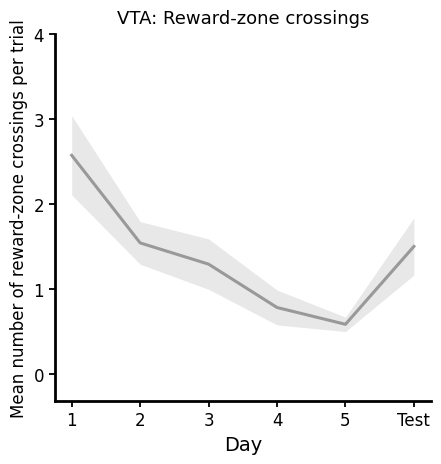

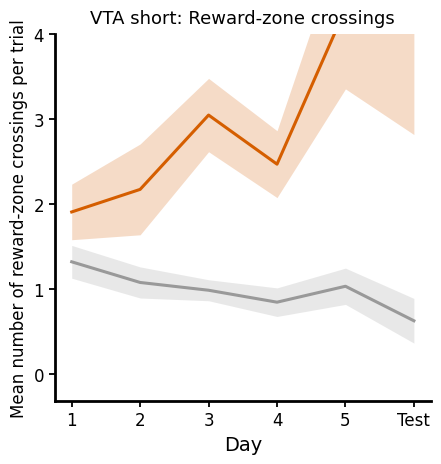

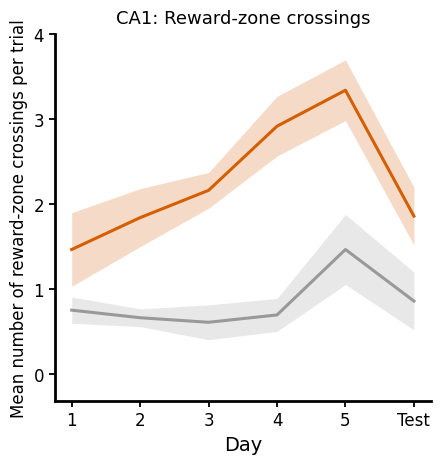

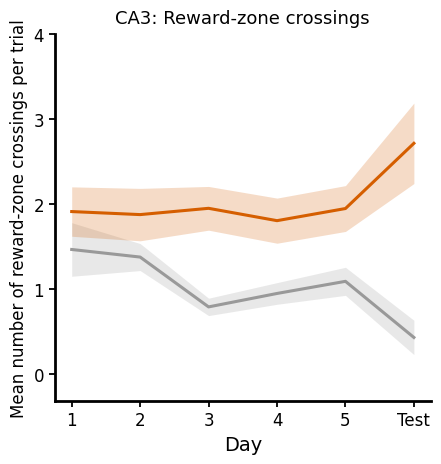

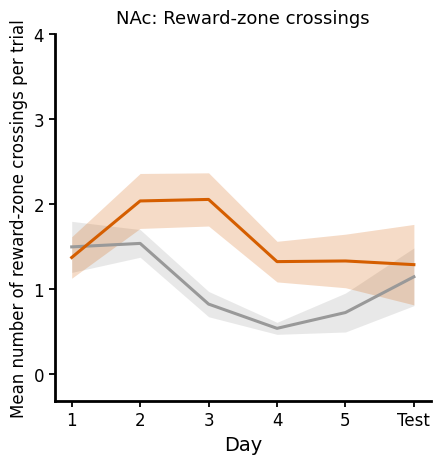

In [ ]:
# plot Number of crossings to goal across L1-L5 + first post-learning Test
# Flexible genotype loop
#
# Zones:
#   trigger_id 1 = Unfavoured location
#   trigger_id 2 = Favoured location
#
# Requires meta_cross with:
#   - trigger_id
#   - n_crossings_trig
#
# Produces line plots for all requested genotypes:
#   ChR2, ChR2_short, ArchT, eYFP_ArchT, WT, CA1, CA3,
#   NAc, eYFP_ChR2, Control
#
# Control = pooled CA1_control + NAc_control.
#
# Solid line: Day 1 to Day 5
# Dashed line: Day 5 to Test
#
# Text is kept editable in SVG for Inkscape.
# ============================================================

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# OPTIONS
# ============================================================

GENOTYPES_TO_PLOT = [
    'ChR2',
    'ChR2_short',
    'ArchT',
    'eYFP_ArchT',
    'WT',
    'CA1',
    'CA3',
    'NAc',
    'eYFP_ChR2',
    'Control',
]

# Control is combined from these original genotype names.
POOLED_CONTROL_ORIGINAL_GROUPS = ['CA1_control', 'NAc_control']

EXCLUDE_ID = []
EXCLUDE_SUBS = []

ZONE_IDS = [1, 2]

ZONE_LABELS = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

ZONE_COLORS = {
    1: '#999999',
    2: '#D55E00',
}

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'short_1': 'Short 1',
    'short_2': 'Short 2',
    'Hp': 'Hp',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A wt',
    'WT': 'WT',
    'ArchT': 'ArchT',
    'eYFP_ArchT': 'VTA control',
}

PLOT_MODE = 'separate_figures'
# PLOT_MODE = 'same_figure'

REQUIRE_COMPLETE = False
PLOT_INDIVIDUAL = False
SHOW_SEM_SHADING = True
SHOW_SEM_ERRORBARS = False

# ------------------------------------------------------------
# Save options
# ------------------------------------------------------------

SAVE_FIGURES = True
SAVE_SVG = True
SAVE_HIGH_DPI_PNG = False
SHOW_FIGURES = True

SAVE_DIR = Path('/Users/stella/Desktop/PhD/thesis/figures')
FIG_DPI = 900

# Keep text editable in SVG/PDF.
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# ------------------------------------------------------------
# Figure options
# ------------------------------------------------------------

SEPARATE_FIGSIZE = (7.5, 5.0)
SAME_FIGURE_FIGSIZE = (8.0, 5.2)

# Y-axis options
YMIN = None
YMAX = None

# Y-axis padding as fraction of y-axis upper limit.
# Example: 0.06 gives bottom = -6% of y_top.
# This pads zero above the bottom axis when YMIN is None.
Y_BOTTOM_PAD_FRAC = 0.06
Y_TOP_PAD_FRAC = 0.08
Y_MAX_TICKS = 7

LINE_WIDTH_MEAN = 2.2
LINE_WIDTH_INDIVIDUAL = 1.0
INDIVIDUAL_ALPHA = 0.12
SEM_ALPHA_SEPARATE = 0.22
SEM_ALPHA_SAME_FIGURE = 0.08

VALUE_COL = 'n_crossings_trig'
VALUE_LABEL = 'Mean number of goal crossings per trial'
TITLE_TEXT = 'Goal crossings'
SAVE_TAG = 'crossings'

plot_days = np.arange(1, 7)
x_vals = plot_days - 1


# ============================================================
# Helper functions
# ============================================================

def get_plot_color(genotype):
    try:
        return get_genotype_color(genotype)
    except Exception:
        fallback = {
            'ChR2': '#F44636ff',
            'eYFP_ChR2': '#5ba0d8ff',
            'ChR2_short': '#FFA623ff',
            'CA1': '#63D15Aff',
            'CA3': '#7b62c5ff',
            'NAc': '#FF9BD6ff',
            'ArchT': '#BF5697',
            'eYFP_ArchT': '#5ba0d8ff',
            'CA1_control': '#62d70fff',
            'Control': '#5ba0d8ff',
            'NAc_control': '#00C2B5',
            'WT': 'grey',
        }
        return fallback.get(genotype, '0.35')


def safe_name(text):
    text = str(text)
    text = text.replace('≥', 'ge')
    text = text.replace('<=', 'le')
    text = text.replace('>=', 'ge')
    text = text.replace('+', 'plus')
    text = re.sub(r'[^A-Za-z0-9_.-]+', '_', text)
    text = re.sub(r'_+', '_', text)
    return text.strip('_')


def finish_figure(fig, save_name):
    if SAVE_FIGURES:
        SAVE_DIR.mkdir(parents=True, exist_ok=True)

        if SAVE_SVG:
            svg_path = SAVE_DIR / f'{safe_name(save_name)}.svg'
            fig.savefig(
                svg_path,
                format='svg',
                bbox_inches='tight'
            )
            print(f"Saved editable SVG: {svg_path}")

        if SAVE_HIGH_DPI_PNG:
            png_path = SAVE_DIR / f'{safe_name(save_name)}.png'
            fig.savefig(
                png_path,
                format='png',
                dpi=FIG_DPI,
                bbox_inches='tight'
            )
            print(f"Saved high-DPI PNG: {png_path}")

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def check_compute_code_compatibility():
    if 'meta_cross' not in globals():
        raise NameError(
            "meta_cross is not defined. Run the crossings compute code first, "
            "then run this plotting code."
        )

    required_cols = [
        'usable',
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'sub',
        'trigger_id',
        VALUE_COL,
    ]

    missing_cols = [c for c in required_cols if c not in meta_cross.columns]

    if len(missing_cols) > 0:
        raise KeyError(
            "meta_cross is missing columns required by this plotting code:\n"
            f"{missing_cols}\n\n"
            "Run the combined crossings compute code first. It should create:\n"
            "  meta_cross['n_crossings_trig']"
        )

    print("\nCompute-code compatibility check passed.")
    print(f"Using meta_cross['{VALUE_COL}'].")


def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)


def nice_tick_step_for_max_ticks(y_top, max_ticks=7):
    if not np.isfinite(y_top) or y_top <= 0:
        return 1.0

    raw_step = y_top / max(max_ticks - 1, 1)
    exponent = np.floor(np.log10(raw_step))
    base = 10 ** exponent

    for multiplier in [1, 2, 5, 10]:
        step = multiplier * base
        n_ticks = int(np.floor(np.ceil(y_top / step))) + 1

        if n_ticks <= max_ticks:
            return float(step)

    return float(10 * base)


def nice_y_top_for_ticks(data_top, max_ticks=7):
    if not np.isfinite(data_top) or data_top <= 0:
        data_top = 1.0

    step = nice_tick_step_for_max_ticks(data_top, max_ticks=max_ticks)
    y_top = np.ceil(data_top / step) * step

    if y_top <= data_top:
        y_top += step

    return float(y_top), float(step)


def apply_y_axis(ax, ymax_candidates=None):
    ymax_candidates = [] if ymax_candidates is None else list(ymax_candidates)
    ymax_candidates = np.asarray(ymax_candidates, dtype=float)
    ymax_candidates = ymax_candidates[np.isfinite(ymax_candidates)]

    if YMAX is not None:
        y_top = float(YMAX)
        step = nice_tick_step_for_max_ticks(y_top, max_ticks=Y_MAX_TICKS)
    else:
        if len(ymax_candidates) == 0:
            data_top = 1.0
        else:
            data_top = np.nanmax(ymax_candidates)
            if not np.isfinite(data_top) or data_top <= 0:
                data_top = 1.0

        data_top = data_top * (1 + Y_TOP_PAD_FRAC)
        y_top, step = nice_y_top_for_ticks(data_top, max_ticks=Y_MAX_TICKS)

    if YMIN is not None:
        y_bottom = float(YMIN)
    else:
        y_bottom = -Y_BOTTOM_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    yticks = np.arange(0, y_top + 0.5 * step, step)
    ax.set_yticks(yticks)


def add_analysis_group(meta_df):
    meta_df = meta_df.copy()
    meta_df['genotype_original'] = meta_df['genotype']
    meta_df['analysis_group'] = meta_df['genotype']

    meta_df.loc[
        meta_df['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
        'analysis_group'
    ] = 'Control'

    return meta_df


def build_base_dataframe():
    needed_cols = [
        'usable',
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'sub',
        'trigger_id',
        VALUE_COL,
    ]

    missing_cols = [c for c in needed_cols if c not in meta_cross.columns]
    if len(missing_cols) > 0:
        raise KeyError(f"Missing columns in meta_cross: {missing_cols}")

    groups_to_load = []

    for g in GENOTYPES_TO_PLOT:
        if g == 'Control':
            groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)
        else:
            groups_to_load.append(g)

    groups_to_load = sorted(set(groups_to_load))

    mt = meta_cross[
        (meta_cross['usable'] == 1) &
        (meta_cross['genotype'].isin(groups_to_load)) &
        (meta_cross['trial_type'].isin(['L', 'T'])) &
        (meta_cross[VALUE_COL].notna()) &
        (np.isfinite(meta_cross[VALUE_COL]))
    ].copy()

    mt = add_analysis_group(mt)
    mt = mt[mt['analysis_group'].isin(GENOTYPES_TO_PLOT)].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in mt.columns:
        mt = mt[
            ~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
        ].copy()

    if len(EXCLUDE_SUBS) > 0:
        mt = mt[
            ~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
        ].copy()

    # Assign plot_day: L1-L5 + first post-learning T = Test day 6.
    mt['plot_day'] = np.nan

    mask_L = mt['trial_type'] == 'L'
    mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

    # Keep only L days 1-5.
    mt = mt[
        (~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))
    ].copy()

    # Assign first T session after last L session as day 6, per animal.
    for sub in mt['sub'].unique():
        ms = mt[mt['sub'] == sub]

        L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
        if len(L_ses) == 0:
            continue

        last_L_ses = L_ses.max()

        T_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_L_ses)
        ]

        if len(T_after) == 0:
            continue

        first_T_ses = T_after['ses'].min()

        idx = mt.index[
            (mt['sub'] == sub) &
            (mt['trial_type'] == 'T') &
            (mt['ses'] == first_T_ses)
        ]

        mt.loc[idx, 'plot_day'] = 6

    mt = mt[mt['plot_day'].isin(plot_days)].copy()

    return mt


def build_zone_matrix(mt_all, genotype, trigger_id):
    perf_mat = []
    subjects = []
    animal_ids = []

    mt_zone = mt_all[
        (mt_all['analysis_group'] == genotype) &
        (mt_all['trigger_id'] == trigger_id)
    ].copy()

    if mt_zone.empty:
        return None, [], []

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub].copy()

        mean_by_day = ms.groupby('plot_day')[VALUE_COL].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_ids.append(str(ms['id'].dropna().iloc[0]))
        else:
            animal_ids.append(str(sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids


def plot_solid_then_dashed(ax, x, y, color, linewidth, alpha, label=None, zorder=3):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Day 1 to Day 5: indices 0..4
    ax.plot(
        x[:5],
        y[:5],
        '-',
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        label=label,
        zorder=zorder
    )

    # Day 5 to Test: indices 4..5
    ax.plot(
        x[4:6],
        y[4:6],
        '--',
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        label='_nolegend_',
        zorder=zorder
    )


def build_all_zone_data(mt):
    zone_data = {}

    print("\nAnimals included:")
    for g in GENOTYPES_TO_PLOT:
        zone_data[g] = {}

        for zid in ZONE_IDS:
            mat, subs, ids = build_zone_matrix(mt, g, zid)

            zone_data[g][zid] = {
                'mat': mat,
                'subs': subs,
                'ids': ids,
            }

            print(f"  {DISPLAY_NAME.get(g, g)} ({g}), {ZONE_LABELS.get(zid, f'Zone {zid}')}:")
            print(f"    n animals plotted = {len(subs)}")
            print(f"    ids = {ids}")

    return zone_data


def plot_separate_figures(zone_data):
    for g in GENOTYPES_TO_PLOT:
        fig, ax = plt.subplots(figsize=SEPARATE_FIGSIZE)

        ymax_candidates = []

        for zid in ZONE_IDS:
            mat = zone_data[g][zid]['mat']
            subs = zone_data[g][zid]['subs']

            if mat is None or len(subs) == 0:
                continue

            mean_vals = np.nanmean(mat, axis=0)
            sem_vals = sem_by_day(mat)

            col = ZONE_COLORS.get(zid, get_plot_color(g))
            label = ZONE_LABELS.get(zid, f'Goal {zid}')

            if PLOT_INDIVIDUAL:
                for row in mat:
                    plot_solid_then_dashed(
                        ax,
                        x_vals,
                        row,
                        color=col,
                        linewidth=LINE_WIDTH_INDIVIDUAL,
                        alpha=INDIVIDUAL_ALPHA,
                        label=None,
                        zorder=1
                    )

                    finite_row = row[np.isfinite(row)]
                    if len(finite_row) > 0:
                        ymax_candidates.append(np.nanmax(finite_row))

            if SHOW_SEM_SHADING:
                ax.fill_between(
                    x_vals,
                    mean_vals - sem_vals,
                    mean_vals + sem_vals,
                    color=col,
                    alpha=SEM_ALPHA_SEPARATE,
                    linewidth=0,
                    zorder=2
                )

            plot_solid_then_dashed(
                ax,
                x_vals,
                mean_vals,
                color=col,
                linewidth=LINE_WIDTH_MEAN,
                alpha=1.0,
                label=f'{label} (n={len(subs)})',
                zorder=3
            )

            if SHOW_SEM_ERRORBARS:
                ax.errorbar(
                    x_vals,
                    mean_vals,
                    yerr=sem_vals,
                    fmt='none',
                    ecolor=col,
                    elinewidth=1.2,
                    capsize=3,
                    alpha=0.9,
                    zorder=4
                )

            if np.isfinite(mean_vals + sem_vals).any():
                ymax_candidates.append(np.nanmax(mean_vals + sem_vals))

        ax.set_xlabel('Day', fontsize=14)
        ax.set_ylabel(VALUE_LABEL, fontsize=14)

        ax.set_xticks(np.arange(6))
        ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
        ax.tick_params(axis='y', labelsize=12)

        style_nature(ax)

        ax.set_title(
            f'{DISPLAY_NAME.get(g, g)}: {TITLE_TEXT}',
            fontsize=15,
            pad=14
        )

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(
                loc='center left',
                bbox_to_anchor=(1.02, 0.5),
                frameon=False,
                fontsize=9
            )

        apply_y_axis(ax, ymax_candidates)

        plt.tight_layout(rect=[0, 0, 0.85, 0.95])

        save_name = safe_name(
            f'number_goal_crossings_l1_l5_test_{g}_{SAVE_TAG}_zones'
        )
        finish_figure(fig, save_name)


def plot_same_figure(zone_data):
    fig, ax = plt.subplots(figsize=SAME_FIGURE_FIGSIZE)

    zone_line_alpha = {
        1: 0.70,
        2: 1.00,
    }

    ymax_candidates = []

    for g in GENOTYPES_TO_PLOT:
        for zid in ZONE_IDS:
            mat = zone_data[g][zid]['mat']
            subs = zone_data[g][zid]['subs']

            if mat is None or len(subs) == 0:
                continue

            mean_vals = np.nanmean(mat, axis=0)
            sem_vals = sem_by_day(mat)

            col = get_plot_color(g)
            label = (
                f'{DISPLAY_NAME.get(g, g)} '
                f'{ZONE_LABELS.get(zid, f"Zone {zid}")} '
                f'(n={len(subs)})'
            )

            if PLOT_INDIVIDUAL:
                for row in mat:
                    plot_solid_then_dashed(
                        ax,
                        x_vals,
                        row,
                        color=col,
                        linewidth=0.9,
                        alpha=0.08,
                        label=None,
                        zorder=1
                    )

                    finite_row = row[np.isfinite(row)]
                    if len(finite_row) > 0:
                        ymax_candidates.append(np.nanmax(finite_row))

            if SHOW_SEM_SHADING:
                ax.fill_between(
                    x_vals,
                    mean_vals - sem_vals,
                    mean_vals + sem_vals,
                    color=col,
                    alpha=SEM_ALPHA_SAME_FIGURE,
                    linewidth=0,
                    zorder=2
                )

            plot_solid_then_dashed(
                ax,
                x_vals,
                mean_vals,
                color=col,
                linewidth=2.1,
                alpha=zone_line_alpha.get(zid, 1.0),
                label=label,
                zorder=3
            )

            if SHOW_SEM_ERRORBARS:
                ax.errorbar(
                    x_vals,
                    mean_vals,
                    yerr=sem_vals,
                    fmt='none',
                    ecolor=col,
                    elinewidth=1.0,
                    capsize=3,
                    alpha=0.9,
                    zorder=4
                )

            if np.isfinite(mean_vals + sem_vals).any():
                ymax_candidates.append(np.nanmax(mean_vals + sem_vals))

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel(VALUE_LABEL, fontsize=14)

    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    style_nature(ax)

    ax.set_title(
        TITLE_TEXT,
        fontsize=15,
        pad=14
    )

    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 0:
        ax.legend(
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            fontsize=8
        )

    apply_y_axis(ax, ymax_candidates)

    plt.tight_layout(rect=[0, 0, 0.82, 0.95])

    save_name = safe_name(
        f'number_goal_crossings_l1_l5_test_all_genotypes_{SAVE_TAG}_zones'
    )
    finish_figure(fig, save_name)


def run_plot():
    print("\n============================================================")
    print("Plotting number of goal crossings")
    print("Using dataframe: meta_cross")
    print("Using column:", VALUE_COL)

    mt = build_base_dataframe()

    print("Rows after filtering:", len(mt))
    if len(mt) == 0:
        print("No rows left after filtering.")
        return

    zone_data = build_all_zone_data(mt)

    if PLOT_MODE == 'separate_figures':
        plot_separate_figures(zone_data)

    elif PLOT_MODE == 'same_figure':
        plot_same_figure(zone_data)

    else:
        raise ValueError("PLOT_MODE must be 'separate_figures' or 'same_figure'")


# ============================================================
# Run
# ============================================================

print("\nGenotypes requested:")
print(GENOTYPES_TO_PLOT)
print("Pooled Control from:", POOLED_CONTROL_ORIGINAL_GROUPS)

check_compute_code_compatibility()
run_plot()


# new learning



############################################################
RUNNING: crossings, count
Using dataframe: meta_cross
Using column: n_crossings_trig
############################################################

Filtered RL/Test rows:
     sub  id genotype trial_type  trial_type_day  ses  plot_day  trial_in_day  \
0      8  AD     ChR2         RL               1   18       1.0             1   
1      8  AD     ChR2         RL               1   18       1.0             1   
2      8  AD     ChR2         RL               1   18       1.0             1   
3      8  AD     ChR2         RL               1   18       1.0             2   
4      8  AD     ChR2         RL               1   18       1.0             2   
..   ...  ..      ...        ...             ...  ...       ...           ...   
976   18  AO     ChR2         RL               5   47       5.0             8   
977   18  AO     ChR2         RL               5   47       5.0             8   
978   18  AO     ChR2          T      

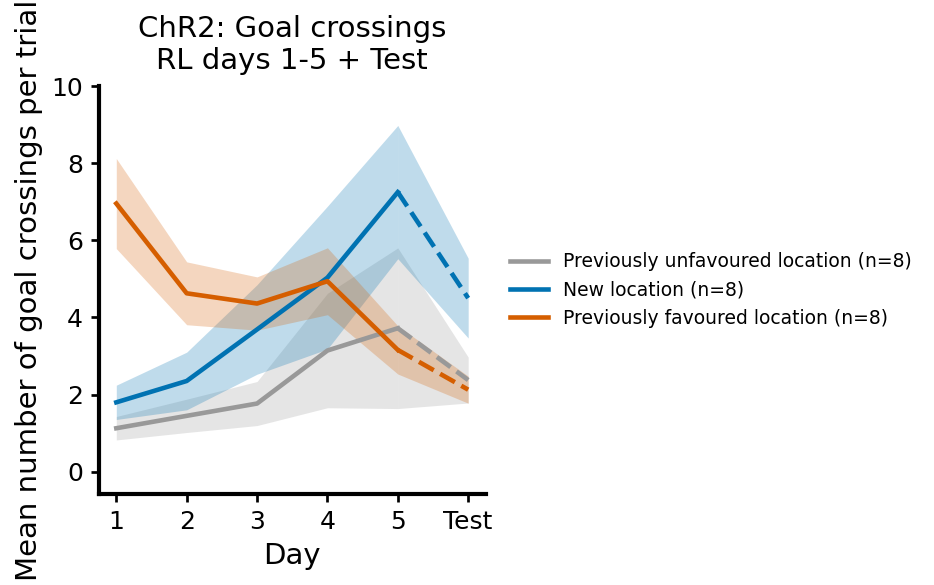


Boxplot: Goal crossings, plot_day 1
Zone type: crossings
Value mode: count
Using column: n_crossings_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[0.75  0.25  0.375 2.875 1.75  1.375 0.875 0.75 ]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[0.5   0.875 0.875 2.625 2.875 2.375 0.5   3.75 ]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 5.25   3.75   8.5    8.25  13.5    5.75   7.5    3.125]

Paired Wilcoxon tests, plot_day 1:
  Previously unfavoured location vs New location: paired n=8, mean=1.125 vs 1.797, median=0.812 vs 1.625, W=6.000, p=0.10938
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=1.125 vs 6.953, median=0.812 vs 6.625, W=0.000, p=0.00781
  New location vs Previously favoured location: paired n=8, mean=1.797 vs 6.953, median=1.625 vs 6.625, W=1.000, p=0.01562
Saved SVG: /Users/stella/Deskt

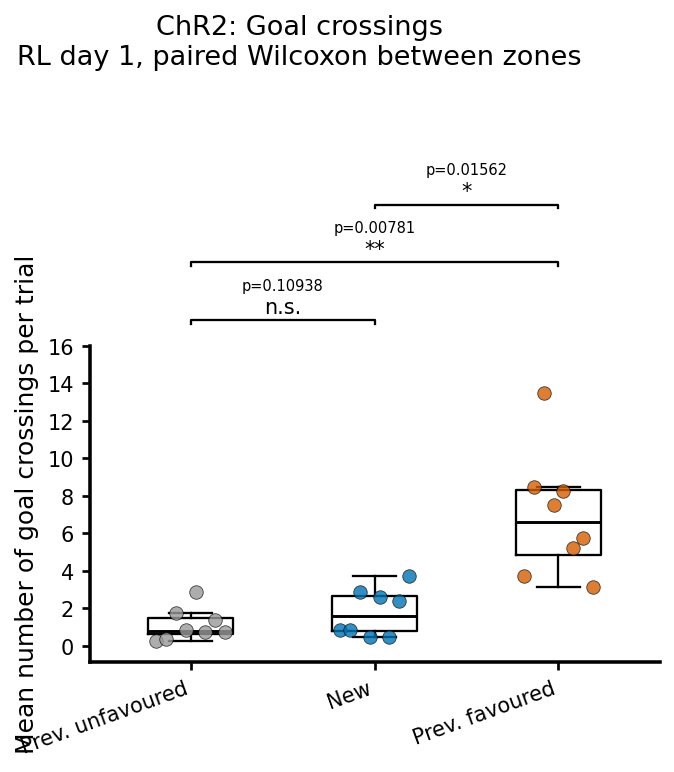


Boxplot: Goal crossings, plot_day 2
Zone type: crossings
Value mode: count
Using column: n_crossings_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[0.5    0.625  0.375  3.625  2.625  2.25   0.5714 1.    ]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[0.25   0.5    1.125  4.5    3.375  2.75   0.4286 5.875 ]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[3.25  3.25  4.75  2.125 9.625 5.5   5.    3.5  ]

Paired Wilcoxon tests, plot_day 2:
  Previously unfavoured location vs New location: paired n=8, mean=1.446 vs 2.350, median=0.812 vs 1.938, W=6.000, p=0.10938
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=1.446 vs 4.625, median=0.812 vs 4.125, W=1.000, p=0.01562
  New location vs Previously favoured location: paired n=8, mean=2.350 vs 4.625, median=1.938 vs 4.125, W=3.000, p=0.03906
Saved SVG: /Users/stel

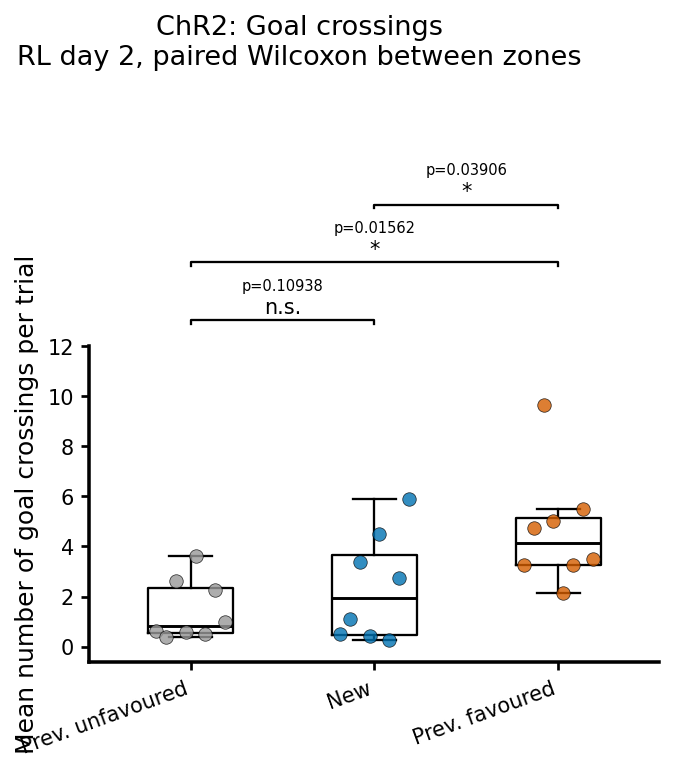


Boxplot: Goal crossings, plot_day 3
Zone type: crossings
Value mode: count
Using column: n_crossings_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[0.375 1.    0.875 2.25  3.75  4.625 0.625 0.625]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[1.    0.75  4.75  8.25  3.875 1.375 0.875 8.625]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[2.125 4.25  3.875 5.875 7.25  5.75  4.375 1.375]

Paired Wilcoxon tests, plot_day 3:
  Previously unfavoured location vs New location: paired n=8, mean=1.766 vs 3.688, median=0.938 vs 2.625, W=7.500, p=0.19531
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=1.766 vs 4.359, median=0.938 vs 4.312, W=0.000, p=0.00781
  New location vs Previously favoured location: paired n=8, mean=3.688 vs 4.359, median=2.625 vs 4.312, W=12.000, p=0.46094
Saved SVG: /Users/stella/Desktop/PhD/

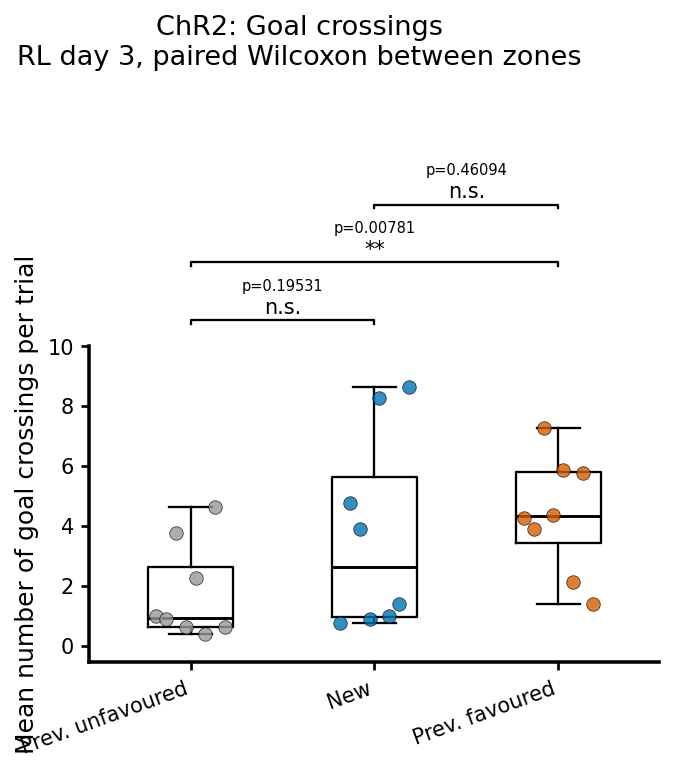


Boxplot: Goal crossings, plot_day 4
Zone type: crossings
Value mode: count
Using column: n_crossings_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 0.75   1.875  0.25   2.25   5.625 12.625  0.375  1.375]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 0.25   1.375  3.     8.875  8.125  1.125  2.25  15.25 ]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[3.25  4.625 4.    2.75  9.5   4.    8.    3.375]

Paired Wilcoxon tests, plot_day 4:
  Previously unfavoured location vs New location: paired n=8, mean=3.141 vs 5.031, median=1.625 vs 2.625, W=10.000, p=0.31250
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=3.141 vs 4.938, median=1.625 vs 4.000, W=8.000, p=0.19531
  New location vs Previously favoured location: paired n=8, mean=5.031 vs 4.938, median=2.625 vs 4.000, W=15.000, p=0.74219
Saved SVG: /Users/st

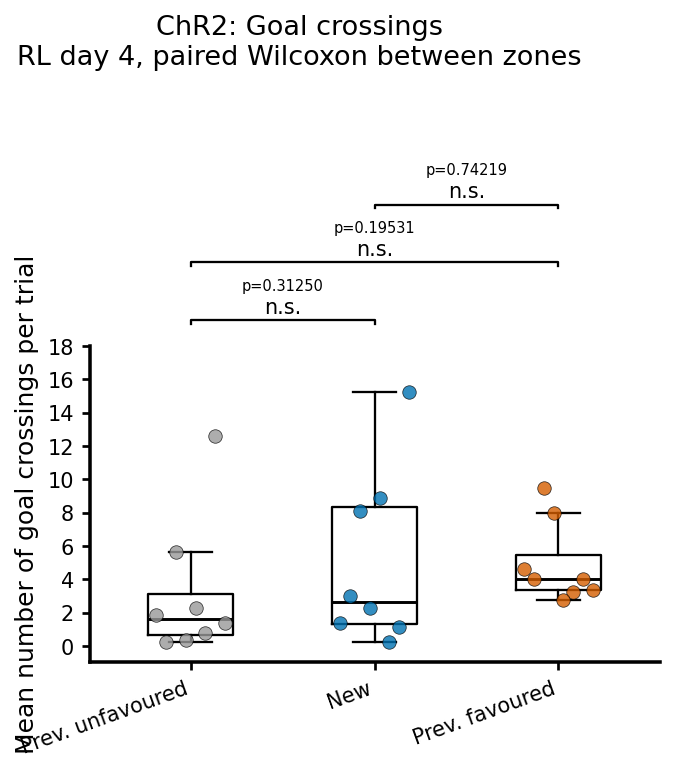


Boxplot: Goal crossings, plot_day 5
Zone type: crossings
Value mode: count
Using column: n_crossings_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 0.75   1.75   0.125  2.25   5.25  17.75   0.375  1.5  ]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 3.25   5.75   4.75   9.75  11.875  1.375  5.25  16.   ]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[3.75  2.75  2.25  2.875 7.125 3.25  1.625 1.625]

Paired Wilcoxon tests, plot_day 5:
  Previously unfavoured location vs New location: paired n=8, mean=3.719 vs 7.250, median=1.625 vs 5.500, W=8.000, p=0.19531
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=3.719 vs 3.156, median=1.625 vs 2.812, W=8.000, p=0.19531
  New location vs Previously favoured location: paired n=8, mean=7.250 vs 3.156, median=5.500 vs 2.812, W=3.000, p=0.03906
Saved SVG: /Users/stel

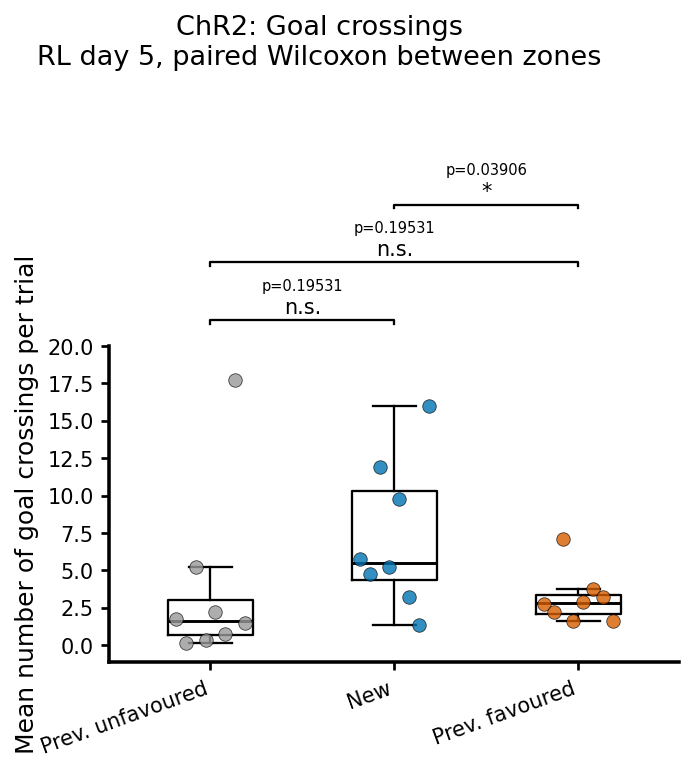


Boxplot: Goal crossings, plot_day 6
Zone type: crossings
Value mode: count
Using column: n_crossings_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[1. 1. 1. 2. 5. 5. 2. 2.]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 2.  3.  3.  7.  5.  1.  5. 10.]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[2. 3. 1. 1. 2. 4. 2. 2.]

Paired Wilcoxon tests, plot_day 6:
  Previously unfavoured location vs New location: paired n=8, mean=2.375 vs 4.500, median=2.000 vs 4.000, W=5.000, p=0.12751
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=2.375 vs 2.125, median=2.000 vs 2.000, W=6.000, p=0.68028
  New location vs Previously favoured location: paired n=8, mean=4.500 vs 2.125, median=4.000 vs 2.000, W=3.000, p=0.11184
Saved SVG: /Users/stella/Desktop/PhD/thesis/figures/ChR2_crossings_count_zone_boxplot_day_6.svg


/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


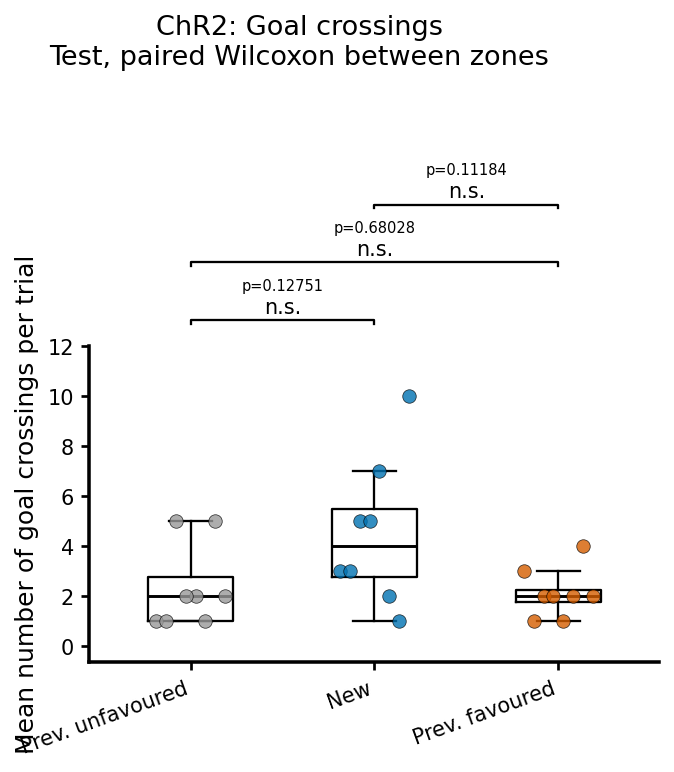


Trial-by-trial plot: Goal crossings
Zone type: crossings
Value mode: count
Using column: n_crossings_trig

Animals included per zone, trial-by-trial:
  Previously unfavoured location: 8 animals
  New location: 8 animals
  Previously favoured location: 8 animals
Total unique animals included, any zone: 8
Animal subs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(17), np.int64(18)]
Animal IDs: ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
Saved SVG: /Users/stella/Desktop/PhD/thesis/figures/ChR2_crossings_count_trial_by_trial_RL1_RL5_Test.svg


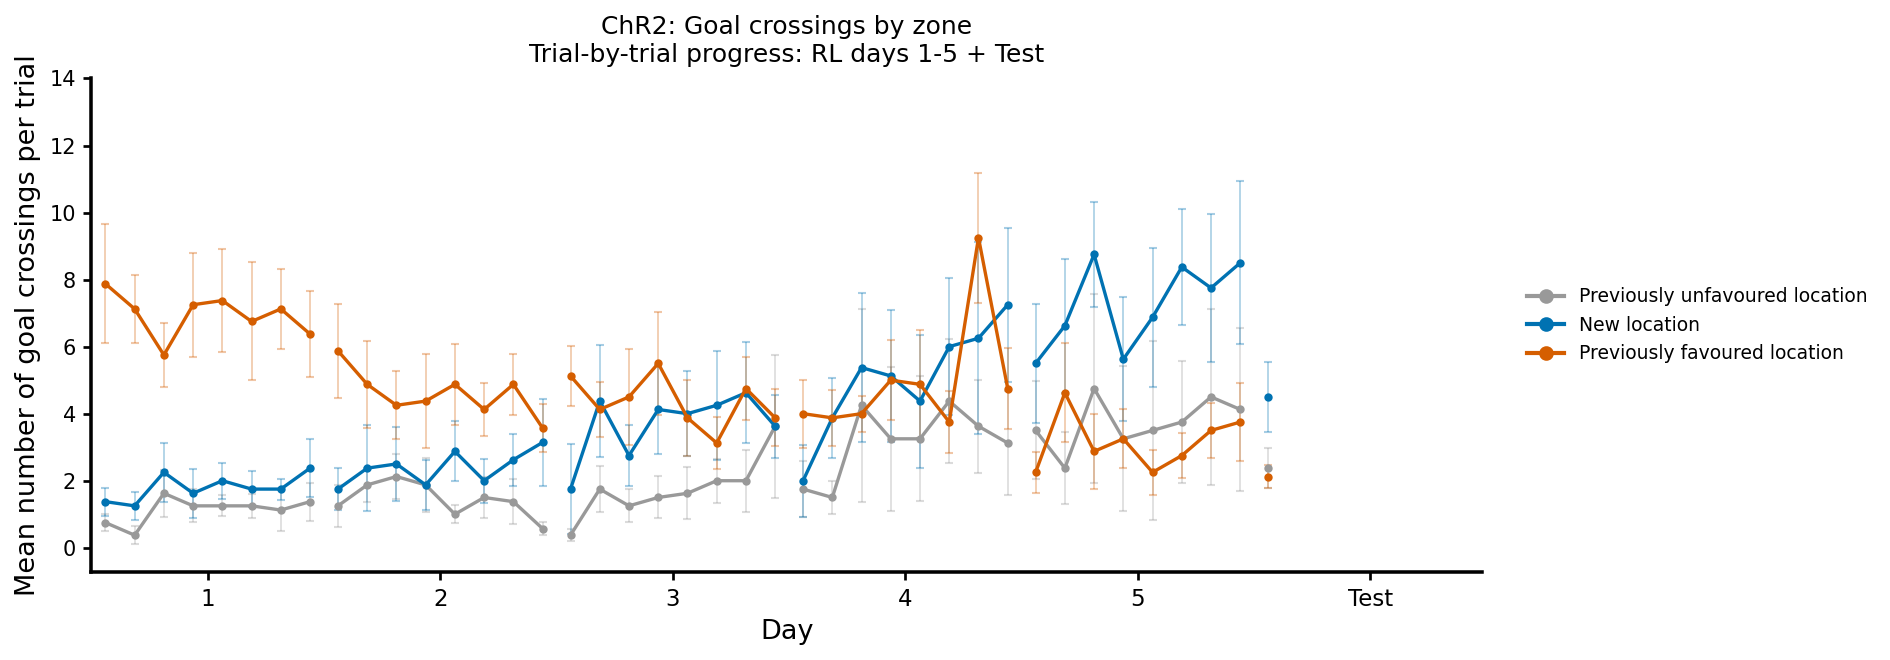


RL day 1 average vs RL day 5 average: Goal crossings
Zone type: crossings
Value mode: count
Using column: n_crossings_trig

Previously unfavoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=6.000, p=0.17630, Day1 mean=1.125, Day5 mean=3.719
Saved SVG: /Users/stella/Desktop/PhD/thesis/figures/ChR2_crossings_count_zone_1_RL_day1_vs_day5.svg


/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


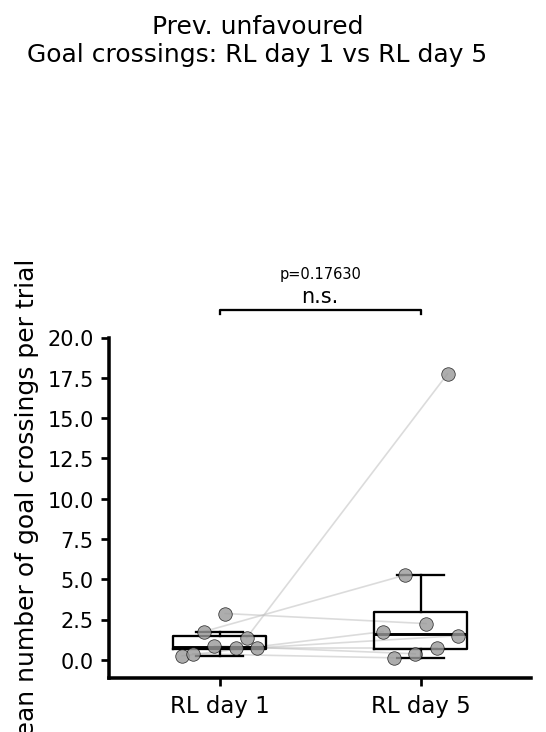


New location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=1.000, p=0.01562, Day1 mean=1.797, Day5 mean=7.250
Saved SVG: /Users/stella/Desktop/PhD/thesis/figures/ChR2_crossings_count_zone_2_RL_day1_vs_day5.svg


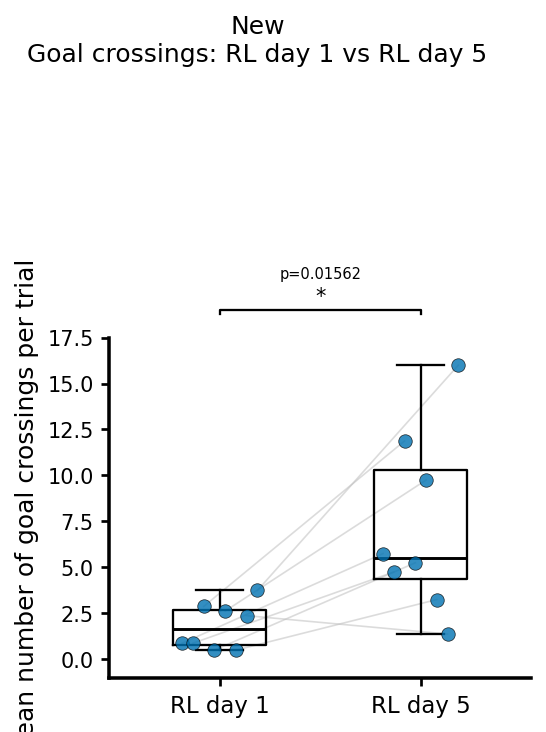


Previously favoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=0.000, p=0.00781, Day1 mean=6.953, Day5 mean=3.156
Saved SVG: /Users/stella/Desktop/PhD/thesis/figures/ChR2_crossings_count_zone_3_RL_day1_vs_day5.svg


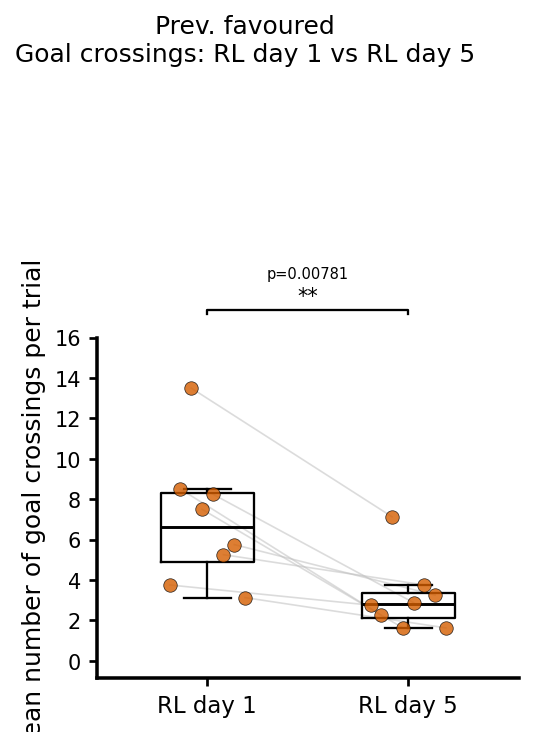


RL day 1 trial 1 vs Test-day average: Goal crossings
Zone type: crossings
Value mode: count
Using column: n_crossings_trig

Previously unfavoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=0.000, p=0.04217, Day1 trial1 mean=0.750, Test mean=2.375
Saved SVG: /Users/stella/Desktop/PhD/thesis/figures/ChR2_crossings_count_zone_1_RL_day1_trial1_vs_Test.svg


/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


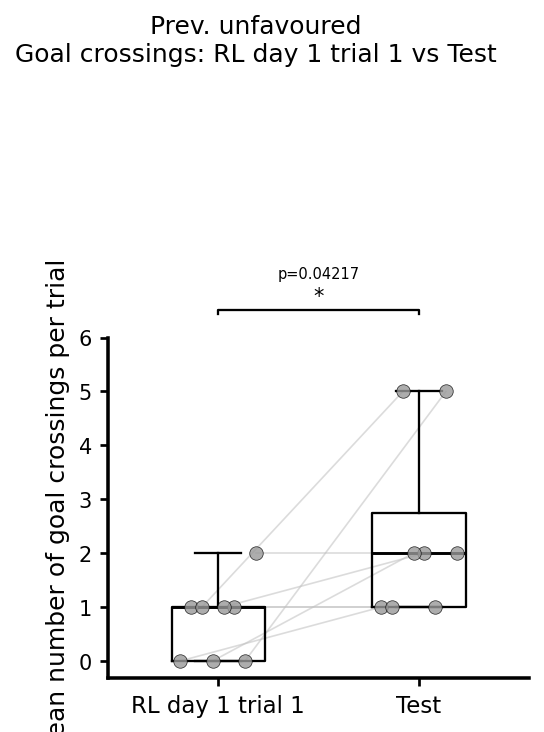


New location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=0.000, p=0.01755, Day1 trial1 mean=1.375, Test mean=4.500
Saved SVG: /Users/stella/Desktop/PhD/thesis/figures/ChR2_crossings_count_zone_2_RL_day1_trial1_vs_Test.svg


/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


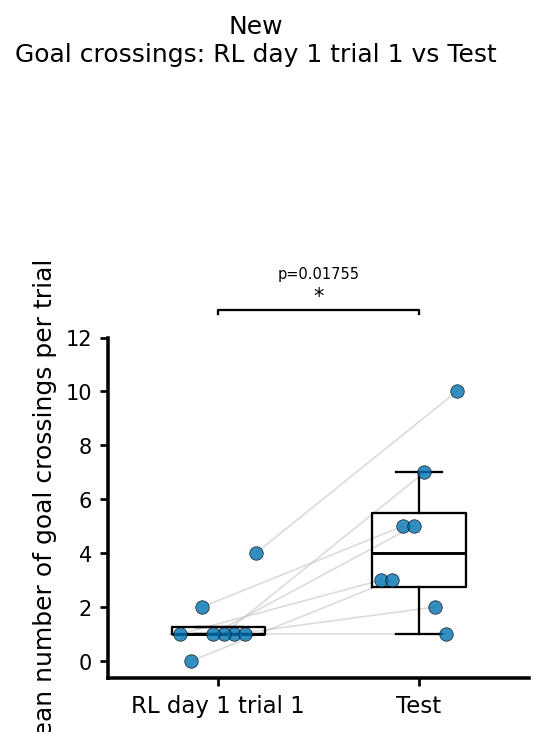


Previously favoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=1.000, p=0.01562, Day1 trial1 mean=7.875, Test mean=2.125
Saved SVG: /Users/stella/Desktop/PhD/thesis/figures/ChR2_crossings_count_zone_3_RL_day1_trial1_vs_Test.svg


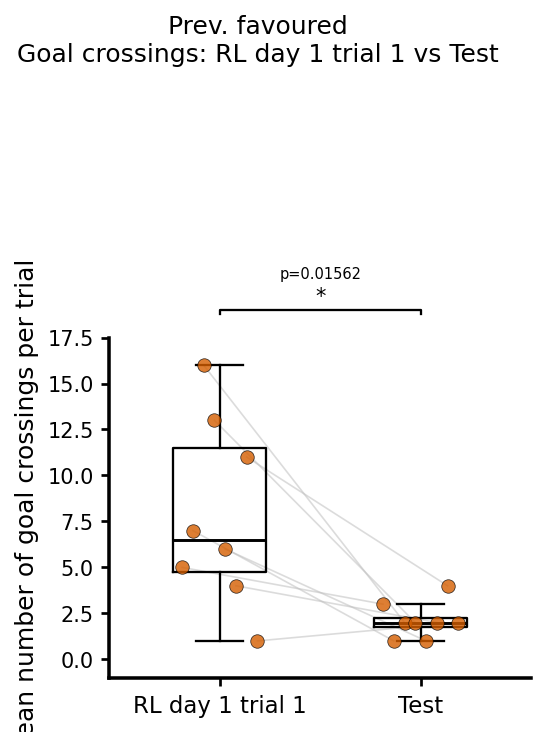

In [15]:
# RL days 1-5 + first post-RL Test day 6
#
# Metric:
#   n_crossings_trig
#       = number of crossings into each goal zone per trial
#
# Produces:
#   1) Wide line plot across RL1-RL5 + Test
#   2) Boxplots for selected days, comparing zones 1/2/3
#   3) Trial-by-trial within-day progress plot
#   4) For each zone: RL day 1 average vs RL day 5 average
#   5) For each zone: RL day 1 trial 1 vs Test-day average
#
# Publication updates:
#   - reward zone wording changed to goal in titles/y-axis labels
#   - original legend/location names are kept
#   - compact boxplot settings
#   - p-value bars are drawn on a separate annotation axis, so they
#     do not stretch the data y-axis
#   - line plots use solid Day 1-Day 5 and dashed Day 5-Test
#   - optional individual animal lines use the same solid/dashed rule
#   - editable SVG export for Inkscape
# ============================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon


# ============================================================
# OPTIONS
# ============================================================

GENOTYPE_TO_PLOT = 'ChR2'

VALUE_COL = 'n_crossings_trig'
VALUE_LABEL = 'Mean number of goal crossings per trial'
VALUE_TITLE = 'Goal crossings'
METRIC_TAG = 'crossings'
VALUE_MODE = 'count'

# Trigger zones
ZONE_IDS = [1, 2, 3]

# Keep these figure legend names.
ZONE_LABELS = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

ZONE_SHORT_LABELS = {
    1: 'Prev. unfavoured',
    2: 'New',
    3: 'Prev. favoured',
}

ZONE_COLORS = {
    1: '#999999',
    2: '#0072B2',
    3: '#D55E00',
}

EXCLUDE_ID = []
EXCLUDE_SUBS = []

# If True, line-plot matrices require all 6 days.
REQUIRE_COMPLETE_LINE = True

# Optional individual lines.
PLOT_INDIVIDUAL_LINES_LINE = False
PLOT_INDIVIDUAL_LINES_TRIAL = False

# Line plot SEM style:
#   'shaded' -> shaded SEM band
#   'bar'    -> SEM error bars
#   'none'   -> mean line only
# LINE_SEM_STYLE = 'shaded' or 'bar'
LINE_SEM_STYLE = 'shaded'
# LINE_SEM_STYLE = 'none'

# Trial-by-trial SEM style:
#   'shaded' -> shaded SEM band
#   'bar'    -> SEM error bars
#   'none'   -> mean line only
TRIAL_SEM_STYLE = 'bar'
# TRIAL_SEM_STYLE = 'shaded'
# TRIAL_SEM_STYLE = 'none'

RUN_LINE_PLOTS = True
RUN_DAY_BOXPLOTS = True
RUN_TRIAL_BY_TRIAL_PLOTS = True
RUN_DAY1_VS_DAY5_BOXPLOTS = True
RUN_DAY1_TRIAL1_VS_TEST_BOXPLOTS = True

# Boxplots comparing zones on each selected day:
#   1 = RL day 1
#   2 = RL day 2
#   ...
#   6 = Test
BOXPLOT_DAYS = [1, 2, 3, 4, 5, 6]

# Pairwise paired Wilcoxon comparisons between zones
ZONE_COMPARISONS = [
    (1, 2),
    (1, 3),
    (2, 3),
]

SHOW_ANIMAL_IDS = False
SHOW_PAIRED_LINES_IN_BOXPLOT = False

# For the added within-zone paired plots
SHOW_PAIRED_LINES_DAY1_DAY5 = True
SHOW_PAIRED_LINES_TRIAL1_TEST = True

# Plot-day labels
plot_days = np.arange(1, 7)
plot_day_labels = ['1', '2', '3', '4', '5', 'Test']

# Trial-by-trial
trials = np.arange(1, 9)

# Figure sizes
LINE_FIGSIZE = (8.0, 4.0)
TRIAL_FIGSIZE = (15, 4.5)
BOX_FIGSIZE = (5.0, 5.4)
PAIR_BOX_FIGSIZE = (3.8, 5.4)

# ------------------------------------------------------------
# Save options
# ------------------------------------------------------------
SAVE_FIGURES = True
SAVE_SVG = True
SAVE_HIGH_DPI_PNG = False
SHOW_FIGURES = True

SAVE_DIR = Path('/Users/stella/Desktop/PhD/thesis/figures')
FIG_DPI = 600

# Keeps text editable in Inkscape.
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# ------------------------------------------------------------
# Line/trial y-axis padding
# ------------------------------------------------------------
LINE_Y_ZERO_PAD_FRAC = 0.06
LINE_Y_TOP_PAD_FRAC = 0.08

TRIAL_Y_ZERO_PAD_FRAC = 0.06
TRIAL_Y_TOP_PAD_FRAC = 0.08

# Y-axis padding as fraction of y-axis upper limit.
Y_BOTTOM_PAD_FRAC = 0.06

# Boxplot data-axis top padding. P-value bars do not use this axis.
BOX_Y_TOP_PAD_FRAC = 0.08

# Optional manual y-axis maxima.
# Use None for auto.
YMAX_BY_METRIC = {
    (METRIC_TAG, VALUE_MODE): None,
}

YMIN_BY_METRIC = {
    (METRIC_TAG, VALUE_MODE): None,
}

# Use None for matplotlib automatic ticks.
# Use 'auto' for:
#   ymax > 60  -> tick step 20
#   ymax < 40  -> tick step 5
#   otherwise  -> tick step 10
Y_TICK_STEP_BY_METRIC = {
    (METRIC_TAG, VALUE_MODE): None,
}

# ------------------------------------------------------------
# Compact boxplot appearance
# ------------------------------------------------------------
BOX_GROUP_SPACING = 0.56
BOX_WIDTH = 0.26
JITTER = 0.105
DOT_SIZE = 42
DOT_ALPHA = 0.8
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.35

# P-value annotation band above boxplot.
# These are fixed 0-1 annotation-axis values.
# For three comparisons, these defaults keep the labels separated.
P_ANNOT_Y_START = 0.18
P_ANNOT_Y_STEP = 0.6
P_ANNOT_CAP_HEIGHT = 0.04
P_ANNOT_STAR_OFFSET = 0.035
P_ANNOT_P_OFFSET = 0.28
P_ANNOT_LINEWIDTH = 1.1
P_ANNOT_STAR_FONTSIZE = 10
P_ANNOT_P_FONTSIZE = 7

P_DECIMALS = 5

np.random.seed(1)

if SAVE_FIGURES:
    SAVE_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# Column selector
# ============================================================

def get_value_info(zone_type, value_mode):
    if zone_type == METRIC_TAG and value_mode == VALUE_MODE:
        return {
            'value_col': VALUE_COL,
            'ylabel': VALUE_LABEL,
            'title': VALUE_TITLE,
            'short_title': 'goal crossings',
        }

    raise ValueError("This script only supports zone_type='crossings' and value_mode='count'")


# ============================================================
# General helpers
# ============================================================

def safe_filename(text):
    text = str(text)
    text = re.sub(r'[^A-Za-z0-9_.-]+', '_', text)
    text = re.sub(r'_+', '_', text).strip('_')
    return text


def save_figure(fig, stem):
    if not SAVE_FIGURES:
        return

    stem = safe_filename(stem)

    if SAVE_SVG:
        out_svg = SAVE_DIR / f'{stem}.svg'
        fig.savefig(out_svg, format='svg', bbox_inches='tight')
        print(f"Saved SVG: {out_svg}")

    if SAVE_HIGH_DPI_PNG:
        out_png = SAVE_DIR / f'{stem}.png'
        fig.savefig(out_png, dpi=FIG_DPI, bbox_inches='tight')
        print(f"Saved PNG: {out_png}")


def finish_figure(fig, stem):
    save_figure(fig, stem)

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def style_nature(ax, linewidth=1.8):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', width=1.3, length=4)
    ax.grid(False)


def style_annotation_axis(ann_ax, n_levels=1):
    ann_ax.set_ylim(0, 1)
    ann_ax.set_yticks([])
    ann_ax.tick_params(
        left=False,
        labelleft=False,
        bottom=False,
        labelbottom=False
    )
    for spine in ann_ax.spines.values():
        spine.set_visible(False)


def mean_sem(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return np.nan, np.nan
    if len(vals) == 1:
        return float(vals[0]), 0.0

    return float(np.nanmean(vals)), float(np.nanstd(vals, ddof=1) / np.sqrt(len(vals)))


def mean_sem_by_col(mat):
    if mat is None or mat.size == 0:
        return None, None

    mean_ = np.full(mat.shape[1], np.nan)
    sem_ = np.full(mat.shape[1], np.nan)

    for j in range(mat.shape[1]):
        m, s = mean_sem(mat[:, j])
        mean_[j] = m
        sem_[j] = s

    return mean_, sem_


def wilcoxon_safe(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    ok = np.isfinite(a) & np.isfinite(b)
    a = a[ok]
    b = b[ok]

    if len(a) == 0:
        return np.nan, np.nan

    if np.allclose(a, b, equal_nan=False):
        return np.nan, 1.0

    try:
        stat, p = wilcoxon(a, b, alternative='two-sided')
    except ValueError:
        stat, p = np.nan, 1.0

    return stat, p


def apply_y_axis(ax, all_vals, zone_type, value_mode, context='line'):
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    key = (zone_type, value_mode)

    manual_ymax = YMAX_BY_METRIC.get(key, None)
    manual_ymin = YMIN_BY_METRIC.get(key, None)
    tick_step = Y_TICK_STEP_BY_METRIC.get(key, None)

    if context == 'line':
        zero_pad = LINE_Y_ZERO_PAD_FRAC
        top_pad = LINE_Y_TOP_PAD_FRAC
    elif context == 'trial':
        zero_pad = TRIAL_Y_ZERO_PAD_FRAC
        top_pad = TRIAL_Y_TOP_PAD_FRAC
    elif context == 'box':
        zero_pad = Y_BOTTOM_PAD_FRAC
        top_pad = BOX_Y_TOP_PAD_FRAC
    else:
        raise ValueError("context must be 'line', 'trial', or 'box'")

    if len(all_vals) == 0:
        data_top = 1.0
    else:
        data_top = np.nanmax(all_vals)
        if not np.isfinite(data_top) or data_top <= 0:
            data_top = 1.0

    if manual_ymax is not None:
        y_top = float(manual_ymax)
    else:
        y_top = data_top * (1 + top_pad)

    if manual_ymin is not None:
        y_bottom = float(manual_ymin)
    else:
        y_bottom = -zero_pad * y_top

    ax.set_ylim(y_bottom, y_top)

    if tick_step == 'auto':
        if y_top > 60:
            tick_step_use = 20
        elif y_top < 40:
            tick_step_use = 5
        else:
            tick_step_use = 10
        tick_end = int(np.ceil(y_top / tick_step_use) * tick_step_use)
        ax.set_yticks(np.arange(0, tick_end + tick_step_use, tick_step_use))
    elif tick_step is not None:
        tick_end = int(np.ceil(y_top / tick_step) * tick_step)
        ax.set_yticks(np.arange(0, tick_end + tick_step, tick_step))
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]
        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)
        ax.set_yticks(yticks)


def draw_p_value_on_annotation_axis(ann_ax, x1, x2, p, level=0):
    y = P_ANNOT_Y_START + level * P_ANNOT_Y_STEP
    cap = P_ANNOT_CAP_HEIGHT

    ann_ax.plot(
        [x1, x1, x2, x2],
        [y - cap, y, y, y - cap],
        color='black',
        linewidth=P_ANNOT_LINEWIDTH,
        clip_on=False
    )

    x_mid = (x1 + x2) / 2

    ann_ax.text(
        x_mid,
        y + P_ANNOT_STAR_OFFSET,
        p_to_stars(p),
        ha='center',
        va='bottom',
        fontsize=P_ANNOT_STAR_FONTSIZE,
        clip_on=False
    )

    ann_ax.text(
        x_mid,
        y + P_ANNOT_P_OFFSET,
        f'p={format_p(p)}',
        ha='center',
        va='bottom',
        fontsize=P_ANNOT_P_FONTSIZE,
        clip_on=False
    )


def get_animal_id(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def compact_offsets(n, jitter=JITTER):
    if n <= 1:
        return np.array([0.0])
    offsets = np.linspace(-jitter, jitter, n)
    rng = np.random.default_rng(1)
    rng.shuffle(offsets)
    return offsets


def create_boxplot_axes(figsize):
    fig, (ann_ax, ax) = plt.subplots(
        2,
        1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={
            'height_ratios': [1.25, 4.1],
            'hspace': 0.04,
        }
    )
    style_annotation_axis(ann_ax, n_levels=1)
    return fig, ann_ax, ax


# ============================================================
# Prepare RL + Test data
# ============================================================

def prepare_rl_test_data(meta_source, value_col):
    needed_cols = [
        'usable',
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'sub',
        'trigger_id',
        value_col,
    ]

    missing_cols = [c for c in needed_cols if c not in meta_source.columns]
    if len(missing_cols) > 0:
        raise KeyError(
            f"Missing columns in meta_cross: {missing_cols}\n"
            f"The selected VALUE_COL is '{value_col}'."
        )

    mt = meta_source[
        (meta_source['usable'] == 1) &
        (meta_source['genotype'] == GENOTYPE_TO_PLOT) &
        (meta_source['trial_type'].isin(['RL', 'T'])) &
        (meta_source['trigger_id'].isin(ZONE_IDS)) &
        (meta_source[value_col].notna()) &
        (np.isfinite(meta_source[value_col]))
    ].copy()

    # No short_duration filtering anywhere.

    if len(EXCLUDE_ID) > 0 and 'id' in mt.columns:
        mt = mt[
            ~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
        ].copy()

    if len(EXCLUDE_SUBS) > 0:
        mt = mt[
            ~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
        ].copy()

    mt['plot_day'] = np.nan

    mask_RL = mt['trial_type'] == 'RL'
    mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

    mt = mt[
        (~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))
    ].copy()

    for sub in mt['sub'].unique():
        ms = mt[mt['sub'] == sub].copy()

        RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']

        if len(RL_ses) == 0:
            continue

        last_RL_ses = RL_ses.max()

        T_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_RL_ses)
        ]

        if len(T_after) == 0:
            continue

        first_T_ses = T_after['ses'].min()

        idx = mt.index[
            (mt['sub'] == sub) &
            (mt['trial_type'] == 'T') &
            (mt['ses'] == first_T_ses)
        ]

        mt.loc[idx, 'plot_day'] = 6

    mt = mt[mt['plot_day'].isin(plot_days)].copy()

    if 'trial_in_day' in mt.columns:
        mt = mt.drop(columns=['trial_in_day'])

    if 'trial_id' not in mt.columns:
        mt = mt.reset_index().rename(columns={'index': 'trial_id'})

    trial_table = (
        mt[['trial_id', 'sub', 'ses', 'plot_day']]
        .drop_duplicates('trial_id')
        .sort_values(['sub', 'ses', 'plot_day', 'trial_id'])
        .copy()
    )

    trial_table['trial_in_day'] = trial_table.groupby(['sub', 'ses']).cumcount() + 1
    trial_table = trial_table[trial_table['trial_in_day'].between(1, 8)].copy()

    mt = mt.merge(
        trial_table[['trial_id', 'trial_in_day']],
        on='trial_id',
        how='inner'
    )

    return mt


# ============================================================
# Matrix / values builders
# ============================================================

def build_zone_day_matrix(mt_all, zone_id, value_col):
    mt_zone = mt_all[mt_all['trigger_id'] == zone_id].copy()

    perf_mat = []
    subjects = []
    ids = []

    for sub in sorted(mt_zone['sub'].unique()):
        ms = mt_zone[mt_zone['sub'] == sub].copy()

        mean_by_day = (
            ms.groupby('plot_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE_LINE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)
        ids.append(get_animal_id(ms, sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, ids


def build_zone_trial_matrix(mt_all, plot_day, zone_id, value_col):
    md = mt_all[
        (mt_all['plot_day'] == plot_day) &
        (mt_all['trigger_id'] == zone_id)
    ].copy()

    if len(md) == 0:
        return None, []

    rows = []
    ids = []

    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub].copy()

        mean_by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        vals = np.array(
            [mean_by_trial.get(t, np.nan) for t in trials],
            dtype=float
        )

        if np.all(np.isnan(vals)):
            continue

        rows.append(vals)
        ids.append(get_animal_id(ms, sub))

    if len(rows) == 0:
        return None, []

    return np.vstack(rows), ids


def day_values_for_zone(mt_all, plot_day, zone_id, value_col):
    md = mt_all[
        (mt_all['plot_day'] == plot_day) &
        (mt_all['trigger_id'] == zone_id)
    ].copy()

    rows = []

    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub].copy()

        if len(ms) == 0:
            continue

        val = ms[value_col].mean()

        if not np.isfinite(val):
            continue

        rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'zone_id': zone_id,
            'plot_day': plot_day,
            'value': float(val),
        })

    return pd.DataFrame(rows)


def day_trial_value_for_zone(mt_all, plot_day, trial_in_day, zone_id, value_col):
    md = mt_all[
        (mt_all['plot_day'] == plot_day) &
        (mt_all['trial_in_day'] == trial_in_day) &
        (mt_all['trigger_id'] == zone_id)
    ].copy()

    rows = []

    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub].copy()

        if len(ms) == 0:
            continue

        val = ms[value_col].mean()

        if not np.isfinite(val):
            continue

        rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'zone_id': zone_id,
            'plot_day': plot_day,
            'trial_in_day': trial_in_day,
            'value': float(val),
        })

    return pd.DataFrame(rows)


# ============================================================
# Plot 1: line plot across RL1-RL5 + Test
# ============================================================

def plot_line_across_days(mt, zone_type, value_mode, value_col, value_label, value_title):
    if not RUN_LINE_PLOTS:
        return

    zone_data = {}

    print("\n============================================================")
    print(f"Line plot: {value_title}")
    print("Zone type:", zone_type)
    print("Value mode:", value_mode)
    print("Using column:", value_col)

    for zid in ZONE_IDS:
        mat, subs, ids = build_zone_day_matrix(mt, zid, value_col)

        zone_data[zid] = {
            'mat': mat,
            'subs': subs,
            'ids': ids,
        }

        print(f"  {ZONE_LABELS[zid]}:")
        print(f"    n animals plotted = {len(subs)}")
        print(f"    ids = {ids}")

    fig, ax = plt.subplots(figsize=LINE_FIGSIZE)

    x_vals = plot_days - 1
    all_y = []

    for zid in ZONE_IDS:
        mat = zone_data[zid]['mat']
        subs = zone_data[zid]['subs']

        if mat is None or len(subs) == 0:
            continue

        mean_vals, sem_vals = mean_sem_by_col(mat)

        col = ZONE_COLORS[zid]

        if PLOT_INDIVIDUAL_LINES_LINE:
            for row in mat:
                ax.plot(
                    x_vals[:5],
                    row[:5],
                    '-',
                    color=col,
                    alpha=0.18,
                    linewidth=0.9,
                    zorder=1
                )
                ax.plot(
                    x_vals[4:6],
                    row[4:6],
                    '--',
                    color=col,
                    alpha=0.18,
                    linewidth=0.9,
                    zorder=1
                )

        if LINE_SEM_STYLE == 'shaded':
            ax.fill_between(
                x_vals[:5],
                mean_vals[:5] - sem_vals[:5],
                mean_vals[:5] + sem_vals[:5],
                color=col,
                alpha=0.25,
                linewidth=0,
                zorder=2
            )
            ax.fill_between(
                x_vals[4:6],
                mean_vals[4:6] - sem_vals[4:6],
                mean_vals[4:6] + sem_vals[4:6],
                color=col,
                alpha=0.25,
                linewidth=0,
                zorder=2
            )

        ax.plot(
            x_vals[:5],
            mean_vals[:5],
            '-',
            color=col,
            linewidth=2.2,
            label=f'{ZONE_LABELS[zid]} (n={len(subs)})',
            zorder=4
        )
        ax.plot(
            x_vals[4:6],
            mean_vals[4:6],
            '--',
            color=col,
            linewidth=2.2,
            zorder=4
        )

        if LINE_SEM_STYLE == 'bar':
            ax.errorbar(
                x_vals,
                mean_vals,
                yerr=sem_vals,
                fmt='none',
                ecolor=col,
                alpha=0.45,
                elinewidth=1.1,
                capsize=3,
                zorder=3
            )
        elif LINE_SEM_STYLE == 'none':
            pass
        elif LINE_SEM_STYLE != 'shaded':
            raise ValueError("LINE_SEM_STYLE must be 'shaded', 'bar', or 'none'")

        all_y.extend(list((mean_vals + sem_vals)[np.isfinite(mean_vals + sem_vals)]))
        all_y.extend(list((mean_vals - sem_vals)[np.isfinite(mean_vals - sem_vals)]))

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel(value_label, fontsize=14)

    ax.set_xticks(x_vals)
    ax.set_xticklabels(plot_day_labels, fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.set_title(
        f'{GENOTYPE_TO_PLOT}: {value_title}\nRL days 1-5 + Test',
        fontsize=14,
        pad=8
    )

    style_nature(ax, linewidth=2.0)
    apply_y_axis(ax, all_y, zone_type, value_mode, context='line')

    ax.legend(
        frameon=False,
        fontsize=9,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5)
    )

    plt.tight_layout(rect=[0, 0, 0.80, 1])
    finish_figure(fig, f'{GENOTYPE_TO_PLOT}_{zone_type}_{value_mode}_line_RL1_RL5_Test')


# ============================================================
# Boxplot helpers
# ============================================================

def draw_boxplot_points(ax, data, positions, colors, ids_by_group=None):
    for i, vals in enumerate(data):
        vals = np.asarray(vals, dtype=float)
        if len(vals) == 0:
            continue

        x = positions[i] + compact_offsets(len(vals), JITTER)

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=colors[i],
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            alpha=DOT_ALPHA,
            zorder=3
        )

        if SHOW_ANIMAL_IDS and ids_by_group is not None:
            for xi, yi, animal_id in zip(x, vals, ids_by_group[i]):
                ax.text(
                    xi + 0.035,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=colors[i],
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )


def draw_boxplot(ax, data, positions):
    ax.boxplot(
        data,
        positions=positions,
        widths=BOX_WIDTH,
        patch_artist=False,
        showfliers=False,
        medianprops={'color': 'black', 'linewidth': 1.4},
        boxprops={'color': 'black', 'linewidth': 1.1},
        whiskerprops={'color': 'black', 'linewidth': 1.1},
        capprops={'color': 'black', 'linewidth': 1.1},
    )


# ============================================================
# Plot 2: boxplot comparing zones for selected days
# ============================================================

def plot_day_boxplot(mt, zone_type, value_mode, value_col, value_label, value_title, test_day):
    if not RUN_DAY_BOXPLOTS:
        return

    zone_dfs = {
        zid: day_values_for_zone(mt, test_day, zid, value_col)
        for zid in ZONE_IDS
    }

    vals_groups = [
        zone_dfs[zid]['value'].values.astype(float)
        for zid in ZONE_IDS
    ]

    print("\n============================================================")
    print(f"Boxplot: {value_title}, plot_day {test_day}")
    print("Zone type:", zone_type)
    print("Value mode:", value_mode)
    print("Using column:", value_col)

    for zid in ZONE_IDS:
        df_z = zone_dfs[zid]
        print(
            f"  {ZONE_LABELS[zid]}: "
            f"n={len(df_z)}, ids={list(df_z['id']) if 'id' in df_z else []}, "
            f"values={np.round(df_z['value'].values.astype(float), 4) if 'value' in df_z else []}"
        )

    fig, ann_ax, ax = create_boxplot_axes(BOX_FIGSIZE)

    positions = np.arange(len(ZONE_IDS), dtype=float) * BOX_GROUP_SPACING

    draw_boxplot(ax, vals_groups, positions)

    colors = [ZONE_COLORS[zid] for zid in ZONE_IDS]
    ids_by_group = [
        zone_dfs[zid]['id'].values if 'id' in zone_dfs[zid] else []
        for zid in ZONE_IDS
    ]
    draw_boxplot_points(ax, vals_groups, positions, colors, ids_by_group)

    print(f"\nPaired Wilcoxon tests, plot_day {test_day}:")

    stats_to_draw = []

    for zid1, zid2 in ZONE_COMPARISONS:
        df1 = zone_dfs[zid1][['sub', 'value']].rename(columns={'value': 'value_1'})
        df2 = zone_dfs[zid2][['sub', 'value']].rename(columns={'value': 'value_2'})

        paired = df1.merge(df2, on='sub', how='inner')
        paired = paired[
            paired['value_1'].notna() &
            paired['value_2'].notna() &
            np.isfinite(paired['value_1']) &
            np.isfinite(paired['value_2'])
        ].copy()

        vals1 = paired['value_1'].values.astype(float)
        vals2 = paired['value_2'].values.astype(float)

        stat, p = wilcoxon_safe(vals1, vals2)

        print(
            f"  {ZONE_LABELS[zid1]} vs {ZONE_LABELS[zid2]}: "
            f"paired n={len(paired)}, "
            f"mean={np.nanmean(vals1) if len(vals1) else np.nan:.3f} vs "
            f"{np.nanmean(vals2) if len(vals2) else np.nan:.3f}, "
            f"median={np.nanmedian(vals1) if len(vals1) else np.nan:.3f} vs "
            f"{np.nanmedian(vals2) if len(vals2) else np.nan:.3f}, "
            f"W={stat:.3f}, p={format_p(p)}"
        )

        stats_to_draw.append((
            positions[ZONE_IDS.index(zid1)],
            positions[ZONE_IDS.index(zid2)],
            p
        ))

        if SHOW_PAIRED_LINES_IN_BOXPLOT and len(paired) > 0:
            for _, row in paired.iterrows():
                ax.plot(
                    [positions[ZONE_IDS.index(zid1)], positions[ZONE_IDS.index(zid2)]],
                    [row['value_1'], row['value_2']],
                    '-',
                    color='0.75',
                    linewidth=0.7,
                    alpha=0.45,
                    zorder=1
                )

    style_annotation_axis(ann_ax, n_levels=len(stats_to_draw))
    ann_ax.set_xlim(positions[0] - BOX_GROUP_SPACING * 0.55, positions[-1] + BOX_GROUP_SPACING * 0.55)

    for level, (x1, x2, p) in enumerate(stats_to_draw):
        draw_p_value_on_annotation_axis(ann_ax, x1, x2, p, level=level)

    ax.set_xlim(positions[0] - BOX_GROUP_SPACING * 0.55, positions[-1] + BOX_GROUP_SPACING * 0.55)

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [ZONE_SHORT_LABELS[zid] for zid in ZONE_IDS],
        fontsize=10,
        rotation=20,
        ha='right'
    )

    ax.set_ylabel(value_label, fontsize=12)

    day_label = 'Test' if test_day == 6 else f'RL day {test_day}'

    fig.suptitle(
        f'{GENOTYPE_TO_PLOT}: {value_title}\n'
        f'{day_label}, paired Wilcoxon between zones',
        fontsize=13,
        y=0.98
    )

    style_nature(ax, linewidth=1.7)

    nonempty_vals = [v for v in vals_groups if len(v) > 0]
    all_for_axis = np.concatenate(nonempty_vals) if len(nonempty_vals) > 0 else np.array([])

    apply_y_axis(
        ax,
        all_for_axis,
        zone_type,
        value_mode,
        context='box'
    )

    fig.subplots_adjust(left=0.22, right=0.98, bottom=0.18, top=0.70)

    finish_figure(
        fig,
        f'{GENOTYPE_TO_PLOT}_{zone_type}_{value_mode}_zone_boxplot_day_{test_day}'
    )


# ============================================================
# Plot 3: trial-by-trial within-day plot
# ============================================================

def plot_trial_by_trial(mt, zone_type, value_mode, value_col, value_label, value_title):
    if not RUN_TRIAL_BY_TRIAL_PLOTS:
        return

    print("\n============================================================")
    print(f"Trial-by-trial plot: {value_title}")
    print("Zone type:", zone_type)
    print("Value mode:", value_mode)
    print("Using column:", value_col)

    fig, ax = plt.subplots(figsize=TRIAL_FIGSIZE)

    offsets = np.linspace(0.06, 0.94, len(trials))

    all_y_for_axis = []

    for zid in ZONE_IDS:
        first_label = True

        for day in plot_days:
            mat, ids = build_zone_trial_matrix(mt, day, zid, value_col)

            if mat is None:
                continue

            x = day + offsets

            mean_, sem_ = mean_sem_by_col(mat)

            col = ZONE_COLORS[zid]

            valid_band = np.isfinite(mean_) & np.isfinite(sem_)
            if np.any(valid_band):
                all_y_for_axis.extend(list((mean_ + sem_)[valid_band]))
                all_y_for_axis.extend(list((mean_ - sem_)[valid_band]))

            if PLOT_INDIVIDUAL_LINES_TRIAL:
                for row in mat:
                    ax.plot(
                        x,
                        row,
                        '-',
                        color=col,
                        alpha=0.18,
                        linewidth=0.8,
                        zorder=1
                    )

            if TRIAL_SEM_STYLE == 'shaded':
                ax.fill_between(
                    x,
                    mean_ - sem_,
                    mean_ + sem_,
                    color=col,
                    alpha=0.20,
                    linewidth=0,
                    zorder=2
                )

            ax.plot(
                x,
                mean_,
                'o-',
                color=col,
                linewidth=1.6,
                markersize=3,
                label=ZONE_LABELS[zid] if first_label else '_nolegend_',
                zorder=4
            )

            if TRIAL_SEM_STYLE == 'bar':
                ax.errorbar(
                    x,
                    mean_,
                    yerr=sem_,
                    fmt='none',
                    ecolor=col,
                    alpha=0.35,
                    elinewidth=0.8,
                    capsize=2,
                    zorder=3
                )
            elif TRIAL_SEM_STYLE == 'none':
                pass
            elif TRIAL_SEM_STYLE != 'shaded':
                raise ValueError("TRIAL_SEM_STYLE must be 'shaded', 'bar', or 'none'")

            first_label = False

    ax.set_xlabel('Day', fontsize=13)
    ax.set_ylabel(value_label, fontsize=13)

    ax.set_xticks(plot_days + 0.5)
    ax.set_xticklabels(plot_day_labels, fontsize=11)

    ax.set_xlim(1.0, 6.98)

    ax.set_title(
        f'{GENOTYPE_TO_PLOT}: {value_title} by zone\n'
        f'Trial-by-trial progress: RL days 1-5 + Test',
        fontsize=12,
        pad=8
    )

    style_nature(ax, linewidth=1.7)

    apply_y_axis(
        ax,
        all_y_for_axis,
        zone_type,
        value_mode,
        context='trial'
    )

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=ZONE_COLORS[zid],
            lw=2,
            marker='o',
            label=ZONE_LABELS[zid]
        )
        for zid in ZONE_IDS
    ]

    ax.legend(
        handles=legend_handles,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=9
    )

    print("\nAnimals included per zone, trial-by-trial:")
    for zid in ZONE_IDS:
        ids_z = sorted(mt.loc[mt['trigger_id'] == zid, 'sub'].unique())
        print(f"  {ZONE_LABELS[zid]}: {len(ids_z)} animals")

    all_animals = sorted(set().union(*[
        set(mt.loc[mt['trigger_id'] == zid, 'sub'].unique())
        for zid in ZONE_IDS
    ]))

    print(f"Total unique animals included, any zone: {len(all_animals)}")
    print("Animal subs:", all_animals)

    if 'id' in mt.columns and len(mt) > 0:
        ids_all = sorted(mt['id'].dropna().astype(str).unique())
        print("Animal IDs:", ids_all)

    plt.tight_layout(rect=[0, 0, 0.85, 1])

    finish_figure(
        fig,
        f'{GENOTYPE_TO_PLOT}_{zone_type}_{value_mode}_trial_by_trial_RL1_RL5_Test'
    )


# ============================================================
# Paired two-condition boxplot helper
# ============================================================

def plot_two_condition_paired_boxplot(
    data_left,
    data_right,
    ids,
    color,
    xlabels,
    title,
    value_label,
    zone_type,
    value_mode,
    show_paired_lines,
    save_stem
):
    data_left = np.asarray(data_left, dtype=float)
    data_right = np.asarray(data_right, dtype=float)

    stat, p = wilcoxon_safe(data_left, data_right)

    fig, ann_ax, ax = create_boxplot_axes(PAIR_BOX_FIGSIZE)

    data = [data_left, data_right]
    positions = np.array([0, BOX_GROUP_SPACING], dtype=float)

    draw_boxplot(ax, data, positions)

    offsets = compact_offsets(len(data_left), JITTER)

    if show_paired_lines:
        for j, (v1, v2) in enumerate(zip(data_left, data_right)):
            ax.plot(
                [positions[0] + offsets[j], positions[1] + offsets[j]],
                [v1, v2],
                '-',
                color='0.75',
                linewidth=0.8,
                alpha=0.55,
                zorder=1
            )

    for i, vals in enumerate(data):
        x = positions[i] + offsets
        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=color,
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            alpha=DOT_ALPHA,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, ids):
                ax.text(
                    xi + 0.035,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=color,
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    style_annotation_axis(ann_ax, n_levels=1)
    ann_ax.set_xlim(positions[0] - BOX_GROUP_SPACING * 0.55, positions[-1] + BOX_GROUP_SPACING * 0.55)
    draw_p_value_on_annotation_axis(ann_ax, positions[0], positions[1], p, level=0)

    ax.set_xlim(positions[0] - BOX_GROUP_SPACING * 0.55, positions[-1] + BOX_GROUP_SPACING * 0.55)
    ax.set_xticks(positions)
    ax.set_xticklabels(xlabels, fontsize=11)

    ax.set_ylabel(value_label, fontsize=12)

    fig.suptitle(title, fontsize=12, y=0.98)

    style_nature(ax, linewidth=1.7)

    all_vals = np.r_[data_left, data_right]

    apply_y_axis(
        ax,
        all_vals,
        zone_type,
        value_mode,
        context='box'
    )

    fig.subplots_adjust(left=0.24, right=0.98, bottom=0.16, top=0.72)

    finish_figure(fig, save_stem)

    return stat, p


# ============================================================
# Plot 4: each zone, RL day 1 average vs RL day 5 average
# ============================================================

def plot_day1_vs_day5_for_each_zone(mt, zone_type, value_mode, value_col, value_label, value_title):
    if not RUN_DAY1_VS_DAY5_BOXPLOTS:
        return

    print("\n============================================================")
    print(f"RL day 1 average vs RL day 5 average: {value_title}")
    print("Zone type:", zone_type)
    print("Value mode:", value_mode)
    print("Using column:", value_col)

    for zid in ZONE_IDS:
        df_day1 = day_values_for_zone(mt, 1, zid, value_col).rename(
            columns={'value': 'day1_value', 'id': 'day1_id'}
        )
        df_day5 = day_values_for_zone(mt, 5, zid, value_col).rename(
            columns={'value': 'day5_value', 'id': 'day5_id'}
        )

        if len(df_day1) == 0 or len(df_day5) == 0:
            print(f"\n{ZONE_LABELS[zid]}: no paired day 1/day 5 data.")
            continue

        paired = df_day1[['sub', 'day1_id', 'day1_value']].merge(
            df_day5[['sub', 'day5_id', 'day5_value']],
            on='sub',
            how='inner'
        )

        paired['id'] = paired['day1_id'].fillna(paired['day5_id'])

        paired = paired[
            paired['day1_value'].notna() &
            paired['day5_value'].notna() &
            np.isfinite(paired['day1_value']) &
            np.isfinite(paired['day5_value'])
        ].copy()

        if len(paired) == 0:
            print(f"\n{ZONE_LABELS[zid]}: no finite paired day 1/day 5 data.")
            continue

        d1 = paired['day1_value'].values.astype(float)
        d5 = paired['day5_value'].values.astype(float)

        stat, p = wilcoxon_safe(d1, d5)

        print(f"\n{ZONE_LABELS[zid]}")
        print(f"  Paired n = {len(paired)}")
        print(f"  IDs = {list(paired['id'])}")
        print(
            f"  Wilcoxon: W={stat:.3f}, p={format_p(p)}, "
            f"Day1 mean={np.nanmean(d1):.3f}, Day5 mean={np.nanmean(d5):.3f}"
        )

        plot_two_condition_paired_boxplot(
            data_left=d1,
            data_right=d5,
            ids=paired['id'].values,
            color=ZONE_COLORS[zid],
            xlabels=['RL day 1', 'RL day 5'],
            title=(
                f'{ZONE_SHORT_LABELS[zid]}\n'
                f'{value_title}: RL day 1 vs RL day 5'
            ),
            value_label=value_label,
            zone_type=zone_type,
            value_mode=value_mode,
            show_paired_lines=SHOW_PAIRED_LINES_DAY1_DAY5,
            save_stem=f'{GENOTYPE_TO_PLOT}_{zone_type}_{value_mode}_zone_{zid}_RL_day1_vs_day5'
        )


# ============================================================
# Plot 5: each zone, RL day 1 trial 1 vs Test-day average
# ============================================================

def plot_day1_trial1_vs_test_for_each_zone(mt, zone_type, value_mode, value_col, value_label, value_title):
    if not RUN_DAY1_TRIAL1_VS_TEST_BOXPLOTS:
        return

    print("\n============================================================")
    print(f"RL day 1 trial 1 vs Test-day average: {value_title}")
    print("Zone type:", zone_type)
    print("Value mode:", value_mode)
    print("Using column:", value_col)

    for zid in ZONE_IDS:
        df_trial1 = day_trial_value_for_zone(
            mt_all=mt,
            plot_day=1,
            trial_in_day=1,
            zone_id=zid,
            value_col=value_col
        ).rename(columns={'value': 'day1_trial1_value', 'id': 'trial1_id'})

        df_test = day_values_for_zone(
            mt_all=mt,
            plot_day=6,
            zone_id=zid,
            value_col=value_col
        ).rename(columns={'value': 'test_value', 'id': 'test_id'})

        if len(df_trial1) == 0 or len(df_test) == 0:
            print(f"\n{ZONE_LABELS[zid]}: no paired day 1 trial 1 / Test data.")
            continue

        paired = df_trial1[['sub', 'trial1_id', 'day1_trial1_value']].merge(
            df_test[['sub', 'test_id', 'test_value']],
            on='sub',
            how='inner'
        )

        paired['id'] = paired['trial1_id'].fillna(paired['test_id'])

        paired = paired[
            paired['day1_trial1_value'].notna() &
            paired['test_value'].notna() &
            np.isfinite(paired['day1_trial1_value']) &
            np.isfinite(paired['test_value'])
        ].copy()

        if len(paired) == 0:
            print(f"\n{ZONE_LABELS[zid]}: no finite paired day 1 trial 1 / Test data.")
            continue

        t1 = paired['day1_trial1_value'].values.astype(float)
        test = paired['test_value'].values.astype(float)

        stat, p = wilcoxon_safe(t1, test)

        print(f"\n{ZONE_LABELS[zid]}")
        print(f"  Paired n = {len(paired)}")
        print(f"  IDs = {list(paired['id'])}")
        print(
            f"  Wilcoxon: W={stat:.3f}, p={format_p(p)}, "
            f"Day1 trial1 mean={np.nanmean(t1):.3f}, Test mean={np.nanmean(test):.3f}"
        )

        plot_two_condition_paired_boxplot(
            data_left=t1,
            data_right=test,
            ids=paired['id'].values,
            color=ZONE_COLORS[zid],
            xlabels=['RL day 1 trial 1', 'Test'],
            title=(
                f'{ZONE_SHORT_LABELS[zid]}\n'
                f'{value_title}: RL day 1 trial 1 vs Test'
            ),
            value_label=value_label,
            zone_type=zone_type,
            value_mode=value_mode,
            show_paired_lines=SHOW_PAIRED_LINES_TRIAL1_TEST,
            save_stem=f'{GENOTYPE_TO_PLOT}_{zone_type}_{value_mode}_zone_{zid}_RL_day1_trial1_vs_Test'
        )


# ============================================================
# Run full analysis for number of crossings
# ============================================================

if 'meta_cross' not in globals():
    raise NameError(
        "meta_cross is not defined. Run the crossings compute code first, "
        "then run this plotting code."
    )

info = get_value_info(METRIC_TAG, VALUE_MODE)

VALUE_COL = info['value_col']
VALUE_LABEL = info['ylabel']
VALUE_TITLE = info['title']

print("\n\n############################################################")
print(f"RUNNING: {METRIC_TAG}, {VALUE_MODE}")
print("Using dataframe: meta_cross")
print("Using column:", VALUE_COL)
print("############################################################")

mt = prepare_rl_test_data(meta_cross, VALUE_COL)

print("\nFiltered RL/Test rows:")
if len(mt) == 0:
    print("No rows left after filtering.")
else:
    cols_to_print = ['sub']
    if 'id' in mt.columns:
        cols_to_print.append('id')

    cols_to_print += [
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'plot_day',
        'trial_in_day',
        'trigger_id',
        VALUE_COL,
    ]

    print(
        mt[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )

    plot_line_across_days(
        mt=mt,
        zone_type=METRIC_TAG,
        value_mode=VALUE_MODE,
        value_col=VALUE_COL,
        value_label=VALUE_LABEL,
        value_title=VALUE_TITLE
    )

    if RUN_DAY_BOXPLOTS:
        for d in BOXPLOT_DAYS:
            plot_day_boxplot(
                mt=mt,
                zone_type=METRIC_TAG,
                value_mode=VALUE_MODE,
                value_col=VALUE_COL,
                value_label=VALUE_LABEL,
                value_title=VALUE_TITLE,
                test_day=d
            )

    plot_trial_by_trial(
        mt=mt,
        zone_type=METRIC_TAG,
        value_mode=VALUE_MODE,
        value_col=VALUE_COL,
        value_label=VALUE_LABEL,
        value_title=VALUE_TITLE
    )

    plot_day1_vs_day5_for_each_zone(
        mt=mt,
        zone_type=METRIC_TAG,
        value_mode=VALUE_MODE,
        value_col=VALUE_COL,
        value_label=VALUE_LABEL,
        value_title=VALUE_TITLE
    )

    plot_day1_trial1_vs_test_for_each_zone(
        mt=mt,
        zone_type=METRIC_TAG,
        value_mode=VALUE_MODE,
        value_col=VALUE_COL,
        value_label=VALUE_LABEL,
        value_title=VALUE_TITLE
    )



Line plot: Previously unfavoured location
Metric: n_crossings_trig
New learning trigger: 1 - Previously unfavoured location
Forgetting/extinction trigger: 1

New learning animals by day:
  RL day 1: n=7, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  RL day 2: n=7, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  RL day 3: n=7, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  RL day 4: n=7, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  RL day 5: n=7, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']

Forgetting animals by day:
  T day 1: n=9, subs=[6, 7, 8, 9, 10, 11, 12, 16, 18]
  T day 2: n=0, subs=[]
  T day 3: n=0, subs=[]
  T day 4: n=0, subs=[]
  T day 5: n=9, subs=[6, 7, 8, 9, 10, 11, 12, 16, 18]

Extinction animals by day:
  T day 1: n=10, subs=[1, 6, 7, 8, 9, 10, 11, 12, 16, 18]
  T day 2: n=10, subs=[1, 6, 7, 8, 9, 10, 11, 12, 16, 18]
  T day 3: n=10, subs=[1, 6, 7, 8, 9, 10, 11, 12, 16, 18]
  T day 4: n=9, subs=[6, 7, 8, 9, 10, 11, 12, 16, 18]
  T day 5: n=8, subs=[6, 7, 

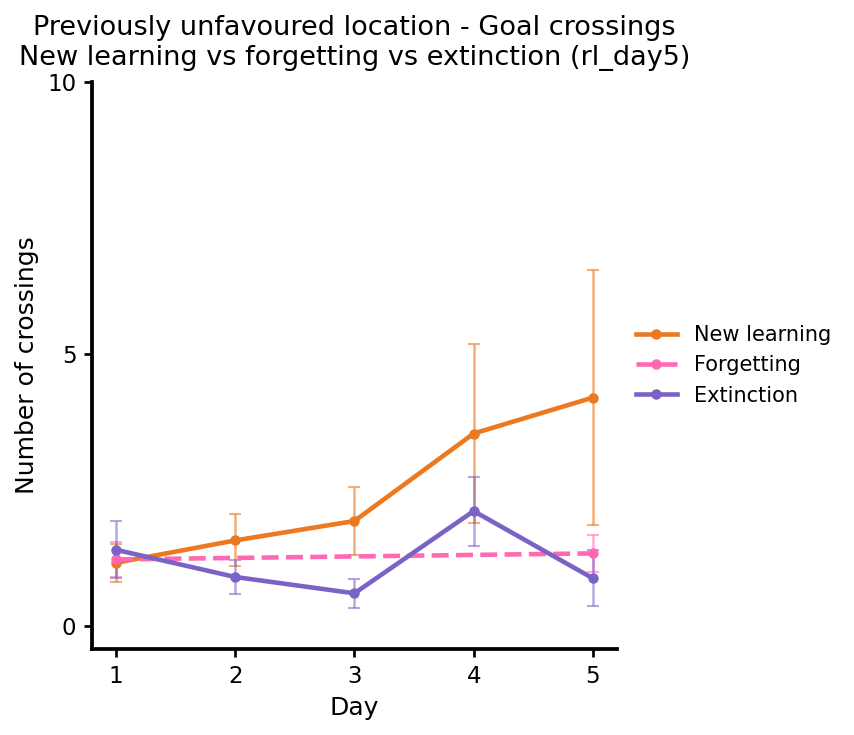


Line plot: New location
Metric: n_crossings_trig
New learning trigger: 2 - New location
Forgetting/extinction trigger: none

New learning animals by day:
  RL day 1: n=7, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  RL day 2: n=7, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  RL day 3: n=7, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  RL day 4: n=7, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  RL day 5: n=7, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
Saved SVG: /Users/stella/Desktop/PhD/thesis/figures/ChR2_crossings_New_location_new_learning_forgetting_extinction_line.svg


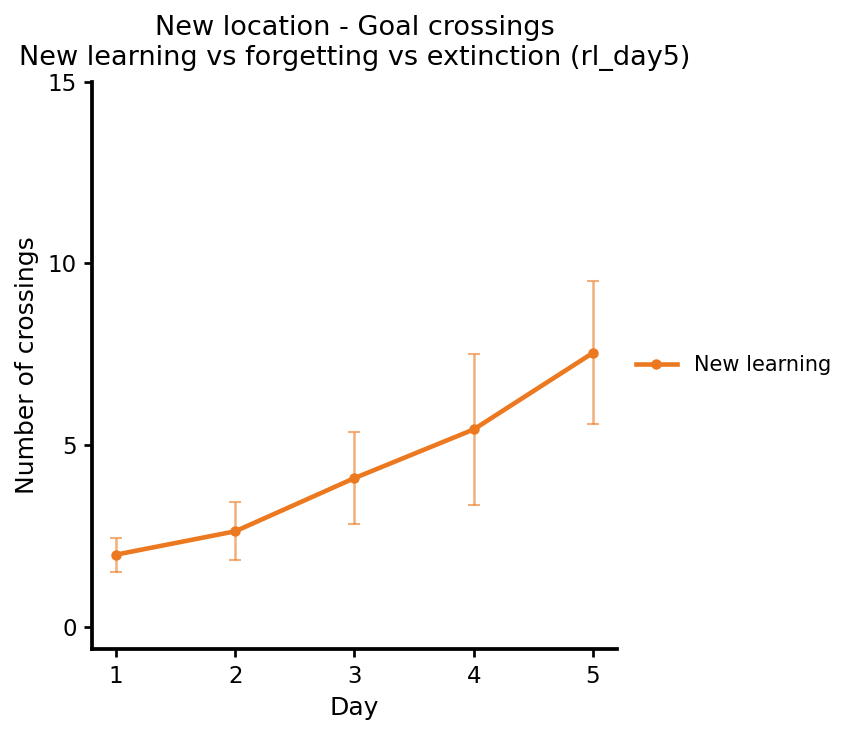


Line plot: Previously favoured location
Metric: n_crossings_trig
New learning trigger: 3 - Previously favoured location
Forgetting/extinction trigger: 2

New learning animals by day:
  RL day 1: n=7, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  RL day 2: n=7, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  RL day 3: n=7, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  RL day 4: n=7, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  RL day 5: n=7, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']

Forgetting animals by day:
  T day 1: n=9, subs=[6, 7, 8, 9, 10, 11, 12, 16, 18]
  T day 2: n=0, subs=[]
  T day 3: n=0, subs=[]
  T day 4: n=0, subs=[]
  T day 5: n=9, subs=[6, 7, 8, 9, 10, 11, 12, 16, 18]

Extinction animals by day:
  T day 1: n=10, subs=[1, 6, 7, 8, 9, 10, 11, 12, 16, 18]
  T day 2: n=10, subs=[1, 6, 7, 8, 9, 10, 11, 12, 16, 18]
  T day 3: n=10, subs=[1, 6, 7, 8, 9, 10, 11, 12, 16, 18]
  T day 4: n=9, subs=[6, 7, 8, 9, 10, 11, 12, 16, 18]
  T day 5: n=8, subs=[6, 7, 8, 9

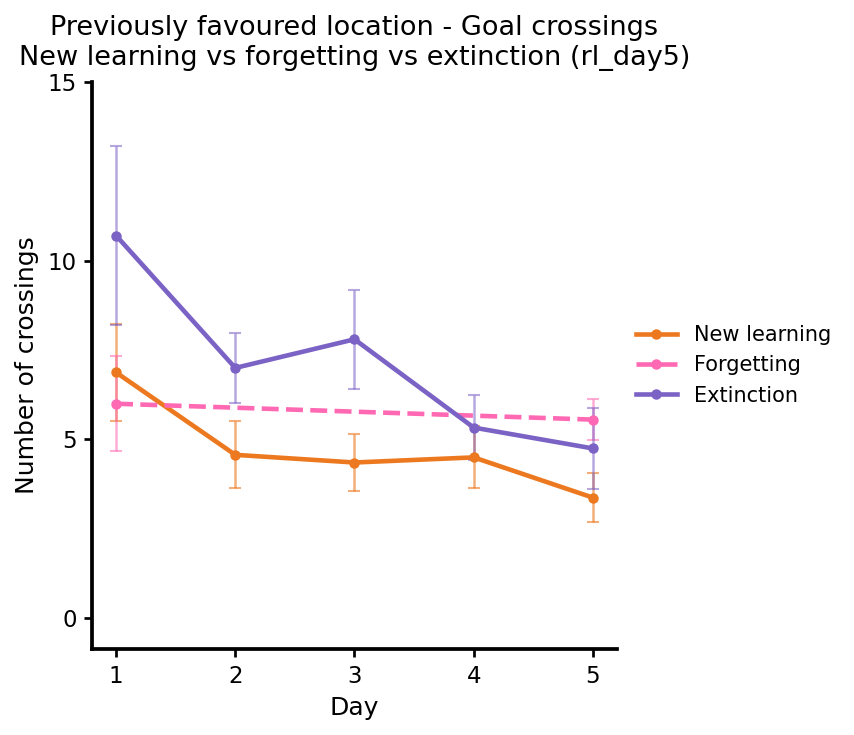


Extracted new-learning test rows
      experiment  sub  id  trigger_id                      zone_label  value  \
0   New learning    8  AD           1  Previously unfavoured location    1.0   
1   New learning    8  AD           3    Previously favoured location    0.0   
2   New learning    9  AE           1  Previously unfavoured location    2.0   
3   New learning    9  AE           3    Previously favoured location    3.0   
4   New learning   10  AF           1  Previously unfavoured location    1.0   
5   New learning   10  AF           3    Previously favoured location    1.0   
6   New learning   11  AG           1  Previously unfavoured location    1.0   
7   New learning   11  AG           3    Previously favoured location    3.0   
8   New learning   12  AH           1  Previously unfavoured location    2.0   
9   New learning   12  AH           3    Previously favoured location    4.0   
10  New learning   16  AM           1  Previously unfavoured location    5.0   
11  Ne

/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


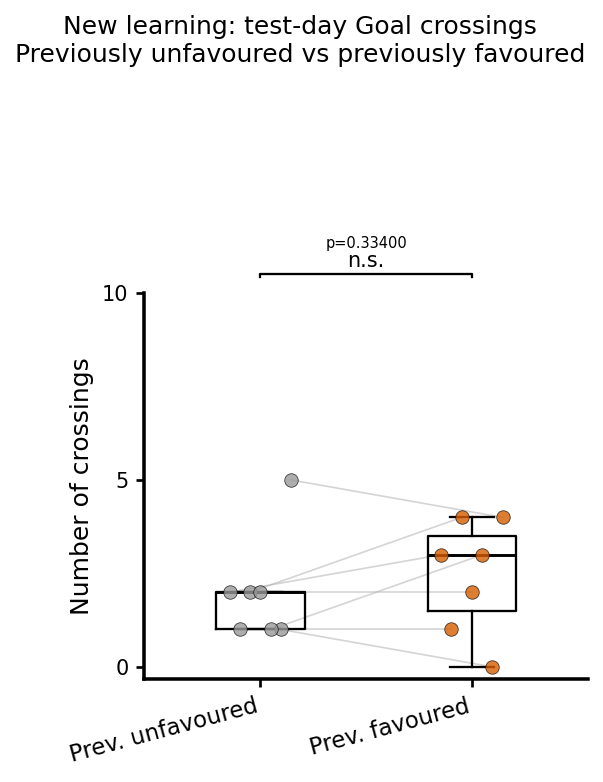


Test-day paired boxplot: Forgetting
Metric: n_crossings_trig
Comparison: Previously unfavoured vs Previously favoured
Paired animals:
   sub  id  unfav_value  fav_value
0    6  AB          1.0        6.0
1    7  AC          1.0        4.0
2    8  AD          2.0        4.0
3    9  AE          0.0        4.0
4   10  AF          0.0        5.0
5   11  AG          3.0        8.0
6   12  AH          2.0        8.0
7   16  AM          1.0        7.0
8   18  AO          2.0        4.0
Wilcoxon paired test: n=9, unfav mean=1.333, fav mean=5.556, unfav median=1.000, fav median=5.000, W=0.000, p=0.00391
Saved SVG: /Users/stella/Desktop/PhD/thesis/figures/ChR2_crossings_Forgetting_test_prev_unfav_vs_prev_fav_boxplot.svg


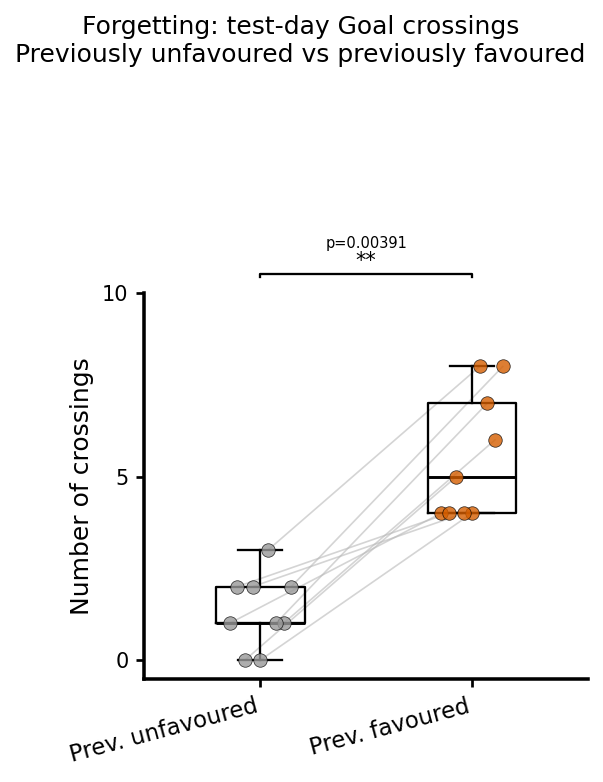


Test-day paired boxplot: Extinction
Metric: n_crossings_trig
Comparison: Previously unfavoured vs Previously favoured
Paired animals:
   sub  id  unfav_value  fav_value
0    6  AB          0.0        4.0
1    7  AC          4.0       11.0
2    8  AD          0.0        7.0
3    9  AE          0.0        2.0
4   10  AF          1.0        1.0
5   11  AG          0.0        6.0
6   16  AM          2.0        4.0
7   18  AO          0.0        3.0
Wilcoxon paired test: n=8, unfav mean=0.875, fav mean=4.750, unfav median=0.000, fav median=4.000, W=0.000, p=0.01755
Saved SVG: /Users/stella/Desktop/PhD/thesis/figures/ChR2_crossings_Extinction_test_prev_unfav_vs_prev_fav_boxplot.svg


/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


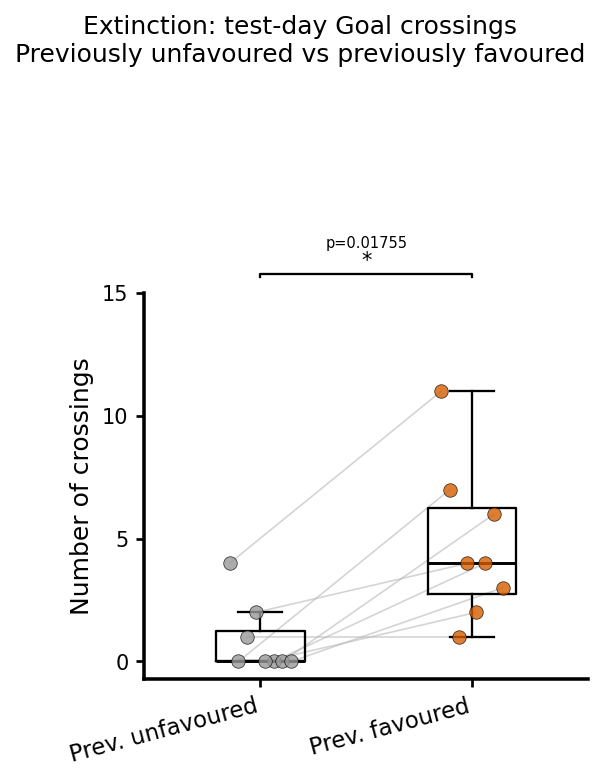


Day 5 boxplot: Previously favoured location
Metric: n_crossings_trig
      experiment  sub  id   value
0   New learning    8  AD   3.750
1   New learning    9  AE   2.750
2   New learning   10  AF   2.250
3   New learning   11  AG   2.875
4   New learning   12  AH   7.125
5   New learning   16  AM   3.250
6   New learning   18  AO   1.625
7     Forgetting    6  AB   6.000
8     Forgetting    7  AC   4.000
9     Forgetting    8  AD   4.000
10    Forgetting    9  AE   4.000
11    Forgetting   10  AF   5.000
12    Forgetting   11  AG   8.000
13    Forgetting   12  AH   8.000
14    Forgetting   16  AM   7.000
15    Forgetting   18  AO   4.000
16    Extinction    6  AB   4.000
17    Extinction    7  AC  11.000
18    Extinction    8  AD   7.000
19    Extinction    9  AE   2.000
20    Extinction   10  AF   1.000
21    Extinction   11  AG   6.000
22    Extinction   16  AM   4.000
23    Extinction   18  AO   3.000
  New learning: n=7, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO'], values=[3.7

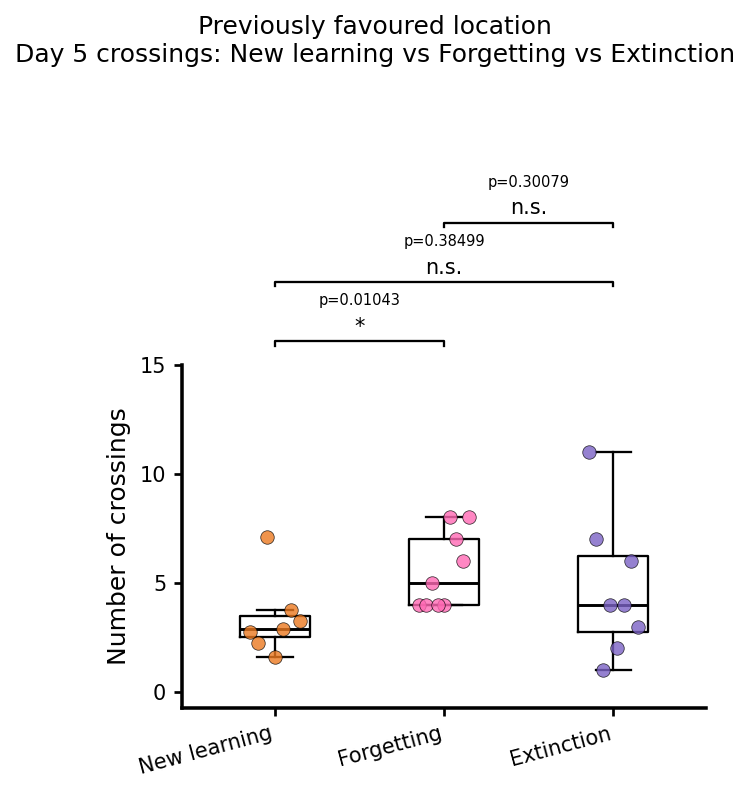

In [16]:
# Compare number of crossings in goal zones:
#
# New learning:
#   RL days 1-5 + first post-RL Test day 6, ChR2
#   trigger_id:
#       1 = Previously unfavoured location
#       2 = New location
#       3 = Previously favoured location
#
# Forgetting / extinction:
#   T days 1-5, ChR2
#   trigger_id:
#       1 = Previously unfavoured location
#       2 = Previously favoured location
#
# Produces:
#   1) Line plot for each target zone:
#        New learning vs forgetting vs extinction
#        line plot uses days 1-5 only
#
#      For "New location", forgetting/extinction are not plotted because
#      they only have trigger 1 and trigger 2.
#
#   2) Test-day paired boxplots comparing:
#        Previously unfavoured location vs Previously favoured location
#
#      New learning test extraction:
#        first T session after the last RL session for that animal
#        used only for the Test-day boxplot
#
#      Forgetting/extinction test extraction:
#        T trial_type_day == 5
#
# Metric:
#   VALUE_COL = 'n_crossings_trig'
#       number of crossings into each goal zone per trial
# ============================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from scipy.stats import wilcoxon


# ============================================================
# OPTIONS
# ============================================================

GENOTYPE_TO_PLOT = 'ChR2'

VALUE_MODE = 'crossings'

EXCLUDE_ID = []
EXCLUDE_SUBS = []

# If True, excludes short_duration == 1.
FILTER_SHORT_DURATION = True

RUN_LINE_PLOTS = True
RUN_TEST_ZONE_BOXPLOTS = True
RUN_DAY5_EXPERIMENT_BOXPLOT = True

SHOW_ANIMAL_IDS = False
SHOW_PAIRED_LINES = True

# Optional individual animal lines on line plots.
PLOT_INDIVIDUAL_LINES_LINE = False

# New-learning line plot day-5 value:
#   'rl_day5'      -> x=5 is true RL day 5
#   'test_as_day5' -> x=5 is the first post-RL Test value
NEW_LEARNING_LINE_DAY5_SOURCE = 'rl_day5'
# NEW_LEARNING_LINE_DAY5_SOURCE = 'test_as_day5' or 'rl_day5'

# New learning:
# 1 = prev unfavoured, 2 = new, 3 = prev favoured
NL_ZONE_LABELS = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

# Forgetting/extinction:
# 1 = prev unfavoured, 2 = prev favoured
FE_ZONE_LABELS = {
    1: 'Previously unfavoured location',
    2: 'Previously favoured location',
}

# Target zones to plot from new learning.
TARGET_ZONES_NL = [1, 2, 3]

ZONE_COLORS = {
    1: '#999999',
    2: '#0072B2',
    3: '#D55E00',
}

# Experiment colours
COL_NEW_LEARNING = '#EC7920'
COL_FORGETTING = '#FF69B4'
COL_EXTINCTION = '#7b62c5ff'

# Plot style
LINE_SEM_STYLE = 'bar'
# LINE_SEM_STYLE = 'shaded'
# LINE_SEM_STYLE = 'none'

# ------------------------------------------------------------
# Save options
# ------------------------------------------------------------
SAVE_FIGURES = True
SAVE_SVG = True
SAVE_HIGH_DPI_PNG = False
SHOW_FIGURES = True

SAVE_DIR = Path('/Users/stella/Desktop/PhD/thesis/figures')
FIG_DPI = 600

# Keeps SVG text editable in Inkscape.
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# ------------------------------------------------------------
# Y-axis options
# ------------------------------------------------------------
Y_BOTTOM_PAD_FRAC = 0.06

LINE_Y_TOP_PAD_FRAC = 0.08
BOX_Y_TOP_PAD_FRAC = 0.08

YMAX_LINE = None
YMIN_LINE = None
Y_TICK_STEP_LINE = 'auto'

YMAX_BOX = None
YMIN_BOX = None
Y_TICK_STEP_BOX = 'auto'

# ------------------------------------------------------------
# Compact boxplot appearance
# ------------------------------------------------------------
BOX_GROUP_SPACING = 0.72
BOX_WIDTH = 0.3
JITTER = 0.105
DOT_SIZE = 42
DOT_ALPHA = 0.8
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.35

# P-value annotation band above boxplot.
# These are 0-1 annotation-axis coordinates.
P_ANNOT_Y_START = 0.12
P_ANNOT_Y_STEP = 0.5
P_ANNOT_CAP_HEIGHT = 0.035
P_ANNOT_STAR_OFFSET = 0.04
P_ANNOT_P_OFFSET = 0.28
P_ANNOT_LINEWIDTH = 1.1
P_ANNOT_STAR_FONTSIZE = 10
P_ANNOT_P_FONTSIZE = 7

P_DECIMALS = 5

np.random.seed(1)

if SAVE_FIGURES:
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

if NEW_LEARNING_LINE_DAY5_SOURCE not in ['rl_day5', 'test_as_day5']:
    raise ValueError("NEW_LEARNING_LINE_DAY5_SOURCE must be 'rl_day5' or 'test_as_day5'")


# ============================================================
# Metric column
# ============================================================

VALUE_COL = 'n_crossings_trig'
VALUE_LABEL = 'Number of crossings'
VALUE_TITLE = 'Goal crossings'


# ============================================================
# Helpers
# ============================================================

def safe_filename(text):
    text = str(text)
    text = re.sub(r'[^A-Za-z0-9_.-]+', '_', text)
    text = re.sub(r'_+', '_', text).strip('_')
    return text


def save_figure(fig, stem):
    if not SAVE_FIGURES:
        return

    stem = safe_filename(stem)

    if SAVE_SVG:
        out_svg = SAVE_DIR / f'{stem}.svg'
        fig.savefig(out_svg, format='svg', bbox_inches='tight')
        print(f"Saved SVG: {out_svg}")

    if SAVE_HIGH_DPI_PNG:
        out_png = SAVE_DIR / f'{stem}.png'
        fig.savefig(out_png, dpi=FIG_DPI, bbox_inches='tight')
        print(f"Saved PNG: {out_png}")


def finish_figure(fig, stem):
    save_figure(fig, stem)

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def style_nature(ax, linewidth=1.8):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.3)
    ax.grid(False)


def style_annotation_axis(ann_ax):
    ann_ax.set_ylim(0, 1)
    ann_ax.set_yticks([])
    ann_ax.tick_params(
        left=False,
        labelleft=False,
        bottom=False,
        labelbottom=False
    )

    for spine in ann_ax.spines.values():
        spine.set_visible(False)


def mean_sem(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return np.nan, np.nan

    if len(vals) == 1:
        return float(vals[0]), 0.0

    return float(np.nanmean(vals)), float(np.nanstd(vals, ddof=1) / np.sqrt(len(vals)))


def wilcoxon_safe(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    ok = np.isfinite(a) & np.isfinite(b)
    a = a[ok]
    b = b[ok]

    if len(a) == 0:
        return np.nan, np.nan

    if np.allclose(a, b, equal_nan=False):
        return np.nan, 1.0

    try:
        stat, p = wilcoxon(a, b, alternative='two-sided')
    except ValueError:
        stat, p = np.nan, 1.0

    return stat, p


def get_animal_id(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def auto_tick_step(y_top):
    if y_top > 60:
        return 20
    if y_top < 40:
        return 5
    return 10


def apply_y_axis(ax, all_vals, ymax_manual=None, ymin_manual=None,
                 tick_step='auto', top_pad_frac=0.08):
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if ymax_manual is not None:
        y_top = float(ymax_manual)
    else:
        if len(all_vals) == 0:
            y_top = 1.0
        else:
            y_top = np.nanmax(all_vals)
            if not np.isfinite(y_top) or y_top <= 0:
                y_top = 1.0

        y_top = y_top * (1 + top_pad_frac)

    if ymin_manual is not None:
        y_bottom = float(ymin_manual)
    else:
        y_bottom = -Y_BOTTOM_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if tick_step == 'auto':
        step = auto_tick_step(y_top)
        tick_end = int(np.ceil(y_top / step) * step)
        ax.set_yticks(np.arange(0, tick_end + step, step))
    elif tick_step is not None:
        step = tick_step
        tick_end = int(np.ceil(y_top / step) * step)
        ax.set_yticks(np.arange(0, tick_end + step, step))
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]
        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)
        ax.set_yticks(yticks)


def draw_p_value_on_annotation_axis(ann_ax, x1, x2, p, level=0):
    y = P_ANNOT_Y_START + level * P_ANNOT_Y_STEP
    cap = P_ANNOT_CAP_HEIGHT

    ann_ax.plot(
        [x1, x1, x2, x2],
        [y - cap, y, y, y - cap],
        color='black',
        linewidth=P_ANNOT_LINEWIDTH,
        clip_on=False
    )

    x_mid = (x1 + x2) / 2

    ann_ax.text(
        x_mid,
        y + P_ANNOT_STAR_OFFSET,
        p_to_stars(p),
        ha='center',
        va='bottom',
        fontsize=P_ANNOT_STAR_FONTSIZE,
        clip_on=False
    )

    ann_ax.text(
        x_mid,
        y + P_ANNOT_P_OFFSET,
        f'p={format_p(p)}',
        ha='center',
        va='bottom',
        fontsize=P_ANNOT_P_FONTSIZE,
        clip_on=False
    )


def compact_offsets(n, jitter=JITTER):
    if n <= 1:
        return np.array([0.0])

    offsets = np.linspace(-jitter, jitter, n)
    rng = np.random.default_rng(1)
    rng.shuffle(offsets)
    return offsets


# ============================================================
# Check required columns
# ============================================================

needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
    'trigger_id',
    VALUE_COL,
]

if FILTER_SHORT_DURATION:
    needed_cols.append('short_duration')

if 'meta_cross' not in globals():
    raise NameError(
        "meta_cross is not defined. Run the crossings compute code first, "
        "then run this plotting code."
    )

missing_cols = [c for c in needed_cols if c not in meta_cross.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in meta_cross: {missing_cols}")

if 'test_type' not in meta_cross.columns:
    raise KeyError("Missing column in meta_cross: test_type")


# ============================================================
# 1. New learning data: RL days 1-5 + first post-RL Test
# ============================================================

def prepare_new_learning_rl(meta_source):
    mt = meta_source[
        (meta_source['usable'] == 1) &
        (meta_source['genotype'] == GENOTYPE_TO_PLOT) &
        (meta_source['trial_type'].isin(['RL', 'T'])) &
        (meta_source['trigger_id'].isin([1, 2, 3])) &
        (meta_source[VALUE_COL].notna()) &
        (np.isfinite(meta_source[VALUE_COL]))
    ].copy()

    if FILTER_SHORT_DURATION:
        mt = mt[mt['short_duration'] != 1].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in mt.columns:
        mt = mt[~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])].copy()

    if len(EXCLUDE_SUBS) > 0:
        mt = mt[~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])].copy()

    mt['plot_day'] = np.nan

    mask_RL = mt['trial_type'] == 'RL'
    mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

    mt = mt[
        (~mask_RL) |
        (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))
    ].copy()

    for sub in mt['sub'].unique():
        ms = mt[mt['sub'] == sub].copy()

        rl_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']

        if len(rl_ses) == 0:
            continue

        last_rl_ses = rl_ses.max()

        test_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_rl_ses)
        ].copy()

        # If the test is recorded in the same session as RL5 in your dataset,
        # include that as a fallback.
        if len(test_after) == 0:
            test_after = ms[
                (ms['trial_type'] == 'T') &
                (ms['ses'] == last_rl_ses)
            ].copy()

        if len(test_after) == 0:
            continue

        first_test_ses = test_after['ses'].min()

        idx = mt.index[
            (mt['sub'] == sub) &
            (mt['trial_type'] == 'T') &
            (mt['ses'] == first_test_ses)
        ]

        mt.loc[idx, 'plot_day'] = 6

    mt = mt[
        ((mt['trial_type'] == 'RL') & (mt['plot_day'].isin([1, 2, 3, 4, 5]))) |
        ((mt['trial_type'] == 'T') & (mt['plot_day'] == 6))
    ].copy()

    return mt


mt_rl = prepare_new_learning_rl(meta_cross)

nl_plot_days = np.arange(1, 7)
rl_days = np.arange(1, 6)


def build_new_learning_zone_matrix(mt_rl, trigger_id):
    df = mt_rl[
        (mt_rl['trigger_id'] == trigger_id) &
        (mt_rl['plot_day'].isin(nl_plot_days))
    ].copy()

    rows = []
    subjects = []
    ids = []

    for sub in sorted(df['sub'].unique()):
        ms = df[df['sub'] == sub].copy()

        mean_by_day = ms.groupby('plot_day')[VALUE_COL].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in nl_plot_days],
            dtype=float
        )

        if np.all(np.isnan(vals)):
            continue

        rows.append(vals)
        subjects.append(sub)
        ids.append(get_animal_id(ms, sub))

    if len(rows) == 0:
        return None, [], []

    return np.vstack(rows), subjects, ids


def build_new_learning_zone_stats(mt_rl, trigger_id):
    mat, subs, ids = build_new_learning_zone_matrix(mt_rl, trigger_id)

    mean_vals = np.full(len(nl_plot_days), np.nan)
    sem_vals = np.full(len(nl_plot_days), np.nan)
    ids_by_day = {}

    if mat is None:
        return mean_vals, sem_vals, ids_by_day, mat

    for i, d in enumerate(nl_plot_days):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            continue

        mean_vals[i], sem_vals[i] = mean_sem(vals)

        day_ids = [
            ids[j]
            for j in range(len(ids))
            if np.isfinite(mat[j, i])
        ]
        ids_by_day[d] = day_ids

    return mean_vals, sem_vals, ids_by_day, mat


# ============================================================
# 2. Forgetting / extinction data: T days 1-5
# ============================================================

def prepare_forgetting_extinction(meta_source):
    mt = meta_source[
        (meta_source['usable'] == 1) &
        (meta_source['genotype'] == GENOTYPE_TO_PLOT) &
        (meta_source['trial_type'] == 'T') &
        (meta_source['test_type'].isin(['forgetting', 'extinction'])) &
        (meta_source['trigger_id'].isin([1, 2])) &
        (meta_source['trial_type_day'].isin([1, 2, 3, 4, 5])) &
        (meta_source[VALUE_COL].notna()) &
        (np.isfinite(meta_source[VALUE_COL]))
    ].copy()

    if FILTER_SHORT_DURATION:
        mt = mt[mt['short_duration'] != 1].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in mt.columns:
        mt = mt[~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])].copy()

    if len(EXCLUDE_SUBS) > 0:
        mt = mt[~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])].copy()

    return mt


mt_fe = prepare_forgetting_extinction(meta_cross)

test_days = np.arange(1, 6)


def build_fe_zone_stats(mt_fe, test_type, trigger_id):
    df = mt_fe[
        (mt_fe['test_type'] == test_type) &
        (mt_fe['trigger_id'] == trigger_id)
    ].copy()

    mean_vals = np.full(len(test_days), np.nan)
    sem_vals = np.full(len(test_days), np.nan)
    ids_by_day = {}

    for i, d in enumerate(test_days):
        df_day = df[df['trial_type_day'] == d].copy()

        if len(df_day) == 0:
            continue

        per_sub = (
            df_day.groupby('sub', as_index=False)
                  .agg(value=(VALUE_COL, 'mean'))
        )

        vals = per_sub['value'].values.astype(float)
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            continue

        mean_vals[i], sem_vals[i] = mean_sem(vals)
        ids_by_day[d] = list(per_sub['sub'])

    return mean_vals, sem_vals, ids_by_day


# ============================================================
# 3. Line plot for one zone
# ============================================================

def plot_solid_line(ax, x, y, color, label=None, **kwargs):
    ax.plot(
        x,
        y,
        '-o',
        color=color,
        label=label,
        **kwargs
    )


def plot_individual_solid_line(ax, x, mat, color):
    if not PLOT_INDIVIDUAL_LINES_LINE or mat is None:
        return

    for row in mat:
        ax.plot(
            x,
            row[:5],
            '-',
            color=color,
            alpha=0.18,
            linewidth=0.9,
            zorder=1
        )


def select_new_learning_line_values(mean_nl, sem_nl, mat_nl):
    """
    Returns the five values plotted at x=1..5 for new learning.

    If NEW_LEARNING_LINE_DAY5_SOURCE == 'test_as_day5',
    the first post-RL Test value, stored internally at plot_day 6,
    is substituted into x=5.
    """
    mean_line = mean_nl[:5].copy()
    sem_line = sem_nl[:5].copy()

    if mat_nl is not None:
        mat_line = mat_nl[:, :5].copy()
    else:
        mat_line = None

    if NEW_LEARNING_LINE_DAY5_SOURCE == 'test_as_day5':
        mean_line[4] = mean_nl[5]
        sem_line[4] = sem_nl[5]

        if mat_line is not None and mat_nl.shape[1] >= 6:
            mat_line[:, 4] = mat_nl[:, 5]

    return mean_line, sem_line, mat_line


def plot_zone_line(new_learning_trigger_id):
    zone_name = NL_ZONE_LABELS[new_learning_trigger_id]

    mean_nl, sem_nl, ids_nl, mat_nl = build_new_learning_zone_stats(
        mt_rl,
        trigger_id=new_learning_trigger_id
    )

    mean_nl_line, sem_nl_line, mat_nl_line = select_new_learning_line_values(
        mean_nl,
        sem_nl,
        mat_nl
    )

    if new_learning_trigger_id == 1:
        fe_trigger_id = 1
    elif new_learning_trigger_id == 3:
        fe_trigger_id = 2
    else:
        fe_trigger_id = None

    if fe_trigger_id is not None:
        mean_forg, sem_forg, ids_forg = build_fe_zone_stats(
            mt_fe,
            test_type='forgetting',
            trigger_id=fe_trigger_id
        )
        mean_ext, sem_ext, ids_ext = build_fe_zone_stats(
            mt_fe,
            test_type='extinction',
            trigger_id=fe_trigger_id
        )
    else:
        mean_forg = np.full(len(test_days), np.nan)
        sem_forg = np.full(len(test_days), np.nan)
        mean_ext = np.full(len(test_days), np.nan)
        sem_ext = np.full(len(test_days), np.nan)
        ids_forg = {}
        ids_ext = {}

    print("\n============================================================")
    print(f"Line plot: {zone_name}")
    print("Metric:", VALUE_COL)
    print("New learning trigger:", new_learning_trigger_id, "-", zone_name)
    print("Forgetting/extinction trigger:", fe_trigger_id if fe_trigger_id is not None else "none")

    print("\nNew learning animals by day:")
    for d in rl_days:
        if d < 5 or NEW_LEARNING_LINE_DAY5_SOURCE == 'rl_day5':
            print(f"  RL day {d}: n={len(ids_nl.get(d, []))}, ids={ids_nl.get(d, [])}")
        else:
            print(f"  x=5 uses Test: n={len(ids_nl.get(6, []))}, ids={ids_nl.get(6, [])}")

    if fe_trigger_id is not None:
        print("\nForgetting animals by day:")
        for d in test_days:
            print(f"  T day {d}: n={len(ids_forg.get(d, []))}, subs={ids_forg.get(d, [])}")

        print("\nExtinction animals by day:")
        for d in test_days:
            print(f"  T day {d}: n={len(ids_ext.get(d, []))}, subs={ids_ext.get(d, [])}")

    fig, ax = plt.subplots(figsize=(7.3, 5))

    all_y = []

    # New learning line plot: RL days 1-5 only.
    if LINE_SEM_STYLE == 'shaded':
        ax.fill_between(
            rl_days,
            mean_nl_line - sem_nl_line,
            mean_nl_line + sem_nl_line,
            color=COL_NEW_LEARNING,
            alpha=0.22,
            linewidth=0,
            zorder=2
        )

    plot_individual_solid_line(ax, rl_days, mat_nl_line, COL_NEW_LEARNING)

    plot_solid_line(
        ax,
        rl_days,
        mean_nl_line,
        COL_NEW_LEARNING,
        label='New learning',
        linewidth=2.2,
        markersize=4,
        zorder=4
    )

    if LINE_SEM_STYLE == 'bar':
        ax.errorbar(
            rl_days,
            mean_nl_line,
            yerr=sem_nl_line,
            fmt='none',
            ecolor=COL_NEW_LEARNING,
            alpha=0.6,
            capsize=3,
            elinewidth=1.2,
            zorder=3
        )

    nl_line_top = mean_nl_line + sem_nl_line
    all_y.extend(list(nl_line_top[np.isfinite(nl_line_top)]))

    if fe_trigger_id is not None:
        # Forgetting: show day 1 and day 5 only, matching your previous style.
        forget_days = np.array([1, 5])
        y_f = np.array([mean_forg[0], mean_forg[4]], dtype=float)
        e_f = np.array([sem_forg[0], sem_forg[4]], dtype=float)

        ax.plot(
            forget_days,
            y_f,
            '--o',
            color=COL_FORGETTING,
            linewidth=2.2,
            markersize=4,
            label='Forgetting',
            zorder=4
        )

        if LINE_SEM_STYLE == 'bar':
            ax.errorbar(
                forget_days,
                y_f,
                yerr=e_f,
                fmt='none',
                ecolor=COL_FORGETTING,
                alpha=0.55,
                capsize=3,
                elinewidth=1.2,
                zorder=3
            )
        elif LINE_SEM_STYLE == 'shaded':
            ax.fill_between(
                forget_days,
                y_f - e_f,
                y_f + e_f,
                color=COL_FORGETTING,
                alpha=0.18,
                linewidth=0,
                zorder=2
            )

        all_y.extend(list((y_f + e_f)[np.isfinite(y_f + e_f)]))

        # Extinction: day 1-5.
        if LINE_SEM_STYLE == 'shaded':
            ax.fill_between(
                test_days,
                mean_ext - sem_ext,
                mean_ext + sem_ext,
                color=COL_EXTINCTION,
                alpha=0.20,
                linewidth=0,
                zorder=2
            )

        ax.plot(
            test_days,
            mean_ext,
            '-o',
            color=COL_EXTINCTION,
            linewidth=2.2,
            markersize=4,
            label='Extinction',
            zorder=4
        )

        if LINE_SEM_STYLE == 'bar':
            ax.errorbar(
                test_days,
                mean_ext,
                yerr=sem_ext,
                fmt='none',
                ecolor=COL_EXTINCTION,
                alpha=0.55,
                capsize=3,
                elinewidth=1.2,
                zorder=3
            )

        all_y.extend(list((mean_ext + sem_ext)[np.isfinite(mean_ext + sem_ext)]))

    ax.set_xlabel('Day', fontsize=12)
    ax.set_ylabel(VALUE_LABEL, fontsize=12)

    ax.set_xticks(rl_days)
    ax.set_xticklabels(['1', '2', '3', '4', '5'], fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    ax.set_title(
        f'{zone_name} - {VALUE_TITLE}\n'
        f'New learning vs forgetting vs extinction'
        f' ({NEW_LEARNING_LINE_DAY5_SOURCE})',
        fontsize=13,
        pad=8
    )

    style_nature(ax, linewidth=1.8)

    apply_y_axis(
        ax,
        all_y,
        ymax_manual=YMAX_LINE,
        ymin_manual=YMIN_LINE,
        tick_step=Y_TICK_STEP_LINE,
        top_pad_frac=LINE_Y_TOP_PAD_FRAC
    )

    ax.legend(
        frameon=False,
        fontsize=10,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.
    )

    plt.tight_layout(rect=[0, 0, 0.8, 1])

    finish_figure(
        fig,
        f'{GENOTYPE_TO_PLOT}_{VALUE_MODE}_{zone_name}_new_learning_forgetting_extinction_line'
    )


# ============================================================
# 4. Test-day extraction for paired boxplots
# ============================================================

def extract_new_learning_test_values():
    """
    New learning test values:
      - first T session after last RL session, fallback to same RL5 session
      - day 6 after five RL days
      - compare trigger 1 vs trigger 3
    """
    rows = []

    mt = meta_cross[
        (meta_cross['usable'] == 1) &
        (meta_cross['genotype'] == GENOTYPE_TO_PLOT) &
        (meta_cross['trial_type'].isin(['RL', 'T'])) &
        (meta_cross['trigger_id'].isin([1, 3])) &
        (meta_cross[VALUE_COL].notna()) &
        (np.isfinite(meta_cross[VALUE_COL]))
    ].copy()

    if FILTER_SHORT_DURATION:
        mt = mt[mt['short_duration'] != 1].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in mt.columns:
        mt = mt[~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])].copy()

    if len(EXCLUDE_SUBS) > 0:
        mt = mt[~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])].copy()

    for sub in sorted(mt['sub'].unique()):
        ms = mt[mt['sub'] == sub].copy()

        rl = ms[ms['trial_type'] == 'RL'].copy()

        if len(rl) == 0:
            continue

        last_rl_ses = rl['ses'].max()

        test = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_rl_ses) &
            (ms['trigger_id'].isin([1, 3]))
        ].copy()

        if len(test) == 0:
            test = ms[
                (ms['trial_type'] == 'T') &
                (ms['ses'] == last_rl_ses) &
                (ms['trigger_id'].isin([1, 3]))
            ].copy()

        if len(test) == 0:
            continue

        first_test_ses = test['ses'].min()
        test = test[test['ses'] == first_test_ses].copy()

        for trig_id in [1, 3]:
            ms_trig = test[test['trigger_id'] == trig_id].copy()

            if len(ms_trig) == 0:
                continue

            value = ms_trig[VALUE_COL].mean()

            if not np.isfinite(value):
                continue

            rows.append({
                'experiment': 'New learning',
                'sub': sub,
                'id': get_animal_id(ms_trig, sub),
                'trigger_id': trig_id,
                'zone_label': NL_ZONE_LABELS[trig_id],
                'value': float(value),
                'ses': first_test_ses,
                'plot_day': 6,
            })

    return pd.DataFrame(rows)


def extract_fe_test_day5_values(test_type):
    rows = []

    mt = meta_cross[
        (meta_cross['usable'] == 1) &
        (meta_cross['genotype'] == GENOTYPE_TO_PLOT) &
        (meta_cross['trial_type'] == 'T') &
        (meta_cross['test_type'] == test_type) &
        (meta_cross['trial_type_day'] == 5) &
        (meta_cross['trigger_id'].isin([1, 2])) &
        (meta_cross[VALUE_COL].notna()) &
        (np.isfinite(meta_cross[VALUE_COL]))
    ].copy()

    if FILTER_SHORT_DURATION:
        mt = mt[mt['short_duration'] != 1].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in mt.columns:
        mt = mt[~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])].copy()

    if len(EXCLUDE_SUBS) > 0:
        mt = mt[~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])].copy()

    for sub in sorted(mt['sub'].unique()):
        ms = mt[mt['sub'] == sub].copy()

        for trig_id in [1, 2]:
            ms_trig = ms[ms['trigger_id'] == trig_id].copy()

            if len(ms_trig) == 0:
                continue

            value = ms_trig[VALUE_COL].mean()

            if not np.isfinite(value):
                continue

            rows.append({
                'experiment': test_type.capitalize(),
                'sub': sub,
                'id': get_animal_id(ms_trig, sub),
                'trigger_id': trig_id,
                'zone_label': FE_ZONE_LABELS[trig_id],
                'value': float(value),
                'ses': ms_trig['ses'].iloc[0] if 'ses' in ms_trig.columns else np.nan,
                'trial_type_day': 5,
            })

    return pd.DataFrame(rows)


# ============================================================
# 5. Paired boxplot: prev unfavoured vs prev favoured
# ============================================================

def plot_prev_unfav_vs_prev_fav_boxplot(df, experiment_name):
    if len(df) == 0:
        print(f"\nSkipping {experiment_name}: no data.")
        return

    if experiment_name == 'New learning':
        trig_unfav = 1
        trig_fav = 3
    else:
        trig_unfav = 1
        trig_fav = 2

    df_unfav = df[df['trigger_id'] == trig_unfav][['sub', 'id', 'value']].rename(
        columns={'id': 'id_unfav', 'value': 'unfav_value'}
    )

    df_fav = df[df['trigger_id'] == trig_fav][['sub', 'id', 'value']].rename(
        columns={'id': 'id_fav', 'value': 'fav_value'}
    )

    paired = df_unfav.merge(df_fav, on='sub', how='inner')
    paired['id'] = paired['id_unfav'].fillna(paired['id_fav'])

    paired = paired[
        paired['unfav_value'].notna() &
        paired['fav_value'].notna() &
        np.isfinite(paired['unfav_value']) &
        np.isfinite(paired['fav_value'])
    ].copy()

    print("\n============================================================")
    print(f"Test-day paired boxplot: {experiment_name}")
    print("Metric:", VALUE_COL)
    print("Comparison: Previously unfavoured vs Previously favoured")
    print("Paired animals:")
    if len(paired) > 0:
        print(paired[['sub', 'id', 'unfav_value', 'fav_value']].reset_index(drop=True))
    else:
        print("No paired animals.")
        return

    unfav_vals = paired['unfav_value'].values.astype(float)
    fav_vals = paired['fav_value'].values.astype(float)

    stat, p = wilcoxon_safe(unfav_vals, fav_vals)

    print(
        f"Wilcoxon paired test: "
        f"n={len(paired)}, "
        f"unfav mean={np.nanmean(unfav_vals):.3f}, "
        f"fav mean={np.nanmean(fav_vals):.3f}, "
        f"unfav median={np.nanmedian(unfav_vals):.3f}, "
        f"fav median={np.nanmedian(fav_vals):.3f}, "
        f"W={stat:.3f}, "
        f"p={format_p(p)}"
    )

    fig, (ann_ax, ax) = plt.subplots(
        2,
        1,
        figsize=(4.0, 5.4),
        sharex=True,
        gridspec_kw={
            'height_ratios': [0.9, 4.2],
            'hspace': 0.04,
        }
    )

    style_annotation_axis(ann_ax)

    positions = np.array([0, BOX_GROUP_SPACING], dtype=float)
    data = [unfav_vals, fav_vals]

    ax.boxplot(
        data,
        positions=positions,
        widths=BOX_WIDTH,
        patch_artist=False,
        showfliers=False,
        medianprops={'color': 'black', 'linewidth': 1.4},
        boxprops={'color': 'black', 'linewidth': 1.1},
        whiskerprops={'color': 'black', 'linewidth': 1.1},
        capprops={'color': 'black', 'linewidth': 1.1},
    )

    offsets = compact_offsets(len(unfav_vals), JITTER)

    if SHOW_PAIRED_LINES:
        for j, (u, f) in enumerate(zip(unfav_vals, fav_vals)):
            ax.plot(
                [positions[0] + offsets[j], positions[1] + offsets[j]],
                [u, f],
                '-',
                color='0.72',
                linewidth=0.8,
                alpha=0.6,
                zorder=1
            )

    plot_colors = [ZONE_COLORS[1], ZONE_COLORS[3]]

    for i, vals in enumerate(data):
        x = positions[i] + offsets

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=plot_colors[i],
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            alpha=DOT_ALPHA,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, paired['id'].values):
                ax.text(
                    xi + 0.035,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=plot_colors[i],
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    ann_ax.set_xlim(
        positions[0] - BOX_GROUP_SPACING * 0.55,
        positions[-1] + BOX_GROUP_SPACING * 0.55
    )
    draw_p_value_on_annotation_axis(
        ann_ax,
        positions[0],
        positions[1],
        p,
        level=0
    )

    ax.set_xlim(
        positions[0] - BOX_GROUP_SPACING * 0.55,
        positions[-1] + BOX_GROUP_SPACING * 0.55
    )

    ax.set_xticks(positions)
    ax.set_xticklabels(
        ['Prev. unfavoured', 'Prev. favoured'],
        fontsize=11,
        rotation=15,
        ha='right'
    )

    ax.set_ylabel(VALUE_LABEL, fontsize=12)

    fig.suptitle(
        f'{experiment_name}: test-day {VALUE_TITLE}\n'
        f'Previously unfavoured vs previously favoured',
        fontsize=12,
        y=0.98
    )

    style_nature(ax, linewidth=1.7)

    all_vals = np.r_[unfav_vals, fav_vals]

    apply_y_axis(
        ax,
        all_vals,
        ymax_manual=YMAX_BOX,
        ymin_manual=YMIN_BOX,
        tick_step=Y_TICK_STEP_BOX,
        top_pad_frac=BOX_Y_TOP_PAD_FRAC
    )

    fig.subplots_adjust(left=0.24, right=0.98, bottom=0.16, top=0.75)

    finish_figure(
        fig,
        f'{GENOTYPE_TO_PLOT}_{VALUE_MODE}_{experiment_name}_test_prev_unfav_vs_prev_fav_boxplot'
    )


# ============================================================
# 6. Day-5 boxplot: previously favoured location across experiments
# ============================================================

def mannwhitney_safe(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan

    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    return stat, p


def values_for_day5_prev_fav_across_experiments():
    rows = []

    # New learning: RL day 5, trigger 3 = Previously favoured location.
    rl_df = meta_cross[
        (meta_cross['usable'] == 1) &
        (meta_cross['genotype'] == GENOTYPE_TO_PLOT) &
        (meta_cross['trial_type'] == 'RL') &
        (meta_cross['trigger_id'] == 3) &
        (meta_cross['trial_type_day'] == 5) &
        (meta_cross[VALUE_COL].notna()) &
        (np.isfinite(meta_cross[VALUE_COL]))
    ].copy()

    if FILTER_SHORT_DURATION:
        rl_df = rl_df[rl_df['short_duration'] != 1].copy()

    # Forgetting / extinction: T day 5, trigger 2 = Previously favoured location.
    fe_df = meta_cross[
        (meta_cross['usable'] == 1) &
        (meta_cross['genotype'] == GENOTYPE_TO_PLOT) &
        (meta_cross['trial_type'] == 'T') &
        (meta_cross['test_type'].isin(['forgetting', 'extinction'])) &
        (meta_cross['trigger_id'] == 2) &
        (meta_cross['trial_type_day'] == 5) &
        (meta_cross[VALUE_COL].notna()) &
        (np.isfinite(meta_cross[VALUE_COL]))
    ].copy()

    if FILTER_SHORT_DURATION:
        fe_df = fe_df[fe_df['short_duration'] != 1].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in rl_df.columns:
        rl_df = rl_df[~rl_df['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in fe_df.columns:
        fe_df = fe_df[~fe_df['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])].copy()

    if len(EXCLUDE_SUBS) > 0:
        rl_df = rl_df[~rl_df['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])].copy()
        fe_df = fe_df[~fe_df['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])].copy()

    for sub in sorted(rl_df['sub'].unique()):
        ms = rl_df[rl_df['sub'] == sub].copy()
        val = ms[VALUE_COL].mean()
        if np.isfinite(val):
            rows.append({
                'experiment': 'New learning',
                'sub': sub,
                'id': get_animal_id(ms, sub),
                'value': float(val),
            })

    for test_type, experiment_name in [
        ('forgetting', 'Forgetting'),
        ('extinction', 'Extinction'),
    ]:
        df_t = fe_df[fe_df['test_type'] == test_type].copy()
        for sub in sorted(df_t['sub'].unique()):
            ms = df_t[df_t['sub'] == sub].copy()
            val = ms[VALUE_COL].mean()
            if np.isfinite(val):
                rows.append({
                    'experiment': experiment_name,
                    'sub': sub,
                    'id': get_animal_id(ms, sub),
                    'value': float(val),
                })

    return pd.DataFrame(rows)


def plot_day5_prev_fav_experiment_boxplot():
    if not RUN_DAY5_EXPERIMENT_BOXPLOT:
        return

    df = values_for_day5_prev_fav_across_experiments()

    print("\n============================================================")
    print("Day 5 boxplot: Previously favoured location")
    print("Metric:", VALUE_COL)
    print(df.reset_index(drop=True) if len(df) > 0 else "No rows")

    if len(df) == 0:
        return

    groups = ['New learning', 'Forgetting', 'Extinction']
    colors = {
        'New learning': COL_NEW_LEARNING,
        'Forgetting': COL_FORGETTING,
        'Extinction': COL_EXTINCTION,
    }

    data = [
        df.loc[df['experiment'] == g, 'value'].values.astype(float)
        for g in groups
    ]

    ids_by_group = [
        df.loc[df['experiment'] == g, 'id'].values
        for g in groups
    ]

    for g, vals, ids in zip(groups, data, ids_by_group):
        print(f"  {g}: n={len(vals)}, ids={list(ids)}, values={np.round(vals, 4)}")

    comparisons = [
        ('New learning vs Forgetting', 0, 1),
        ('New learning vs Extinction', 0, 2),
        ('Forgetting vs Extinction', 1, 2),
    ]

    stats_to_draw = []

    print("\nMann-Whitney tests:")
    for name, i, j in comparisons:
        stat, p = mannwhitney_safe(data[i], data[j])
        stats_to_draw.append((i, j, p))
        print(
            f"  {name}: "
            f"n={len(data[i])} vs {len(data[j])}, "
            f"U={stat:.3f}, p={format_p(p)}"
        )

    fig, (ann_ax, ax) = plt.subplots(
        2,
        1,
        figsize=(4.6, 5.7),
        sharex=True,
        gridspec_kw={
            'height_ratios': [1.45, 4.2],
            'hspace': 0.04,
        }
    )

    style_annotation_axis(ann_ax)

    positions = np.arange(len(groups), dtype=float) * BOX_GROUP_SPACING

    ax.boxplot(
        data,
        positions=positions,
        widths=BOX_WIDTH,
        patch_artist=False,
        showfliers=False,
        medianprops={'color': 'black', 'linewidth': 1.4},
        boxprops={'color': 'black', 'linewidth': 1.1},
        whiskerprops={'color': 'black', 'linewidth': 1.1},
        capprops={'color': 'black', 'linewidth': 1.1},
    )

    for i, (g, vals) in enumerate(zip(groups, data)):
        if len(vals) == 0:
            continue

        offsets = compact_offsets(len(vals), JITTER)
        x = positions[i] + offsets

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=colors[g],
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            alpha=DOT_ALPHA,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, ids_by_group[i]):
                ax.text(
                    xi + 0.035,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=colors[g],
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    ann_ax.set_xlim(positions[0] - BOX_GROUP_SPACING * 0.55, positions[-1] + BOX_GROUP_SPACING * 0.55)

    for level, (i, j, p) in enumerate(stats_to_draw):
        draw_p_value_on_annotation_axis(
            ann_ax,
            positions[i],
            positions[j],
            p,
            level=level
        )

    ax.set_xlim(positions[0] - BOX_GROUP_SPACING * 0.55, positions[-1] + BOX_GROUP_SPACING * 0.55)
    ax.set_xticks(positions)
    ax.set_xticklabels(groups, rotation=15, ha='right', fontsize=10)
    ax.set_ylabel(VALUE_LABEL, fontsize=12)

    fig.suptitle(
        'Previously favoured location\n'
        'Day 5 crossings: New learning vs Forgetting vs Extinction',
        fontsize=12,
        y=0.98
    )

    style_nature(ax, linewidth=1.7)

    nonempty = [v for v in data if len(v) > 0]
    all_vals = np.concatenate(nonempty) if len(nonempty) > 0 else np.array([])

    apply_y_axis(
        ax,
        all_vals,
        ymax_manual=YMAX_BOX,
        ymin_manual=YMIN_BOX,
        tick_step=Y_TICK_STEP_BOX,
        top_pad_frac=BOX_Y_TOP_PAD_FRAC
    )

    fig.subplots_adjust(left=0.22, right=0.98, bottom=0.17, top=0.72)

    finish_figure(
        fig,
        f'{GENOTYPE_TO_PLOT}_{VALUE_MODE}_previously_favoured_day5_new_learning_forgetting_extinction_boxplot'
    )


# ============================================================
# Run line plots
# ============================================================

if RUN_LINE_PLOTS:
    for trig_id in TARGET_ZONES_NL:
        plot_zone_line(trig_id)


# ============================================================
# Run paired test-day boxplots
# ============================================================

if RUN_TEST_ZONE_BOXPLOTS:
    df_nl_test = extract_new_learning_test_values()
    df_forg_test = extract_fe_test_day5_values('forgetting')
    df_ext_test = extract_fe_test_day5_values('extinction')

    print("\n============================================================")
    print("Extracted new-learning test rows")
    print(df_nl_test.reset_index(drop=True) if len(df_nl_test) > 0 else "No rows")

    print("\n============================================================")
    print("Extracted forgetting day-5 test rows")
    print(df_forg_test.reset_index(drop=True) if len(df_forg_test) > 0 else "No rows")

    print("\n============================================================")
    print("Extracted extinction day-5 test rows")
    print(df_ext_test.reset_index(drop=True) if len(df_ext_test) > 0 else "No rows")

    plot_prev_unfav_vs_prev_fav_boxplot(df_nl_test, 'New learning')
    plot_prev_unfav_vs_prev_fav_boxplot(df_forg_test, 'Forgetting')
    plot_prev_unfav_vs_prev_fav_boxplot(df_ext_test, 'Extinction')


# ============================================================
# Run Day-5 previously favoured location experiment boxplot
# ============================================================

plot_day5_prev_fav_experiment_boxplot()
